# 🚕 NYC Taxi Trip Project — Exploratory Data Analysis (EDA)

## 📌 Notebook Purpose
This notebook focuses only on **Exploratory Data Analysis (EDA)** for the NYC Taxi Trip dataset.

## 🔍 What We Will Explore
- 📁 Dataset overview  
- 🎯 Target variable analysis  
- 🔢 Continuous numeric feature analysis  
- 🏷️ Categorical feature analysis  
- ⏰ Date-time feature analysis  
- 📍 Location-based feature analysis  
- 🧹 Data quality checks  
- 📊 Visualization-based understanding  

## 🎯 Main Goal
To understand the dataset structure, feature behavior, data quality, and important patterns before building any machine learning model.

# 1. 📥 Dataset Loading, Library Importing & Initial Data Inspection

## 1.1 Import libraries

In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import skew, kurtosis
import statsmodels.api as sm

# Missing value visualization
import missingno as msno

# Date and time handling
import datetime as dt

# Warning control
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Plot style settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 1.2 Import all dataset

In [2]:
from pathlib import Path

# Define dataset path
DATA_DIR = Path("../Data")

# Check available files inside Data folder
list(DATA_DIR.iterdir())

# Load CSV dataset
train = pd.read_csv(DATA_DIR / "train.csv")
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.9822,40.7679,-73.9646,40.7656,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.9804,40.7386,-73.9995,40.7312,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.9790,40.7639,-74.0053,40.7101,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.0100,40.7200,-74.0123,40.7067,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.9731,40.7932,-73.9729,40.7825,N,435


In [3]:
test = pd.read_csv(DATA_DIR / "test.csv")
test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.9881,40.7320,-73.9902,40.7567,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.9642,40.6800,-73.9598,40.6554,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.9974,40.7376,-73.9862,40.7295,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.9561,40.7719,-73.9864,40.7305,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.9702,40.7615,-73.9615,40.7559,N


In [4]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


Train shape: (1458644, 11)
Test shape: (625134, 9)


## 1.3 summary_df

In [5]:
summary_df = pd.DataFrame({
    "column_name": train.columns,
    "missing_count": train.isnull().sum().values,
    "missing_percentage": (train.isnull().sum().values / len(train)) * 100,
    "duplicate_count": [train[col].duplicated().sum() for col in train.columns],
    "duplicate_percentage": [(train[col].duplicated().sum() / len(train)) * 100 for col in train.columns]
})

# Round percentage values
summary_df["missing_percentage"] = summary_df["missing_percentage"].round(2)
summary_df["duplicate_percentage"] = summary_df["duplicate_percentage"].round(2)

summary_df

,column_name,missing_count,missing_percentage,duplicate_count,duplicate_percentage
0,id,0,0.0000,0,0.0000
1,vendor_id,0,0.0000,1458642,100.0000
2,pickup_datetime,0,0.0000,78422,5.3800
3,dropoff_datetime,0,0.0000,78267,5.3700
4,passenger_count,0,0.0000,1458634,100.0000
5,pickup_longitude,0,0.0000,1435597,98.4200
6,pickup_latitude,0,0.0000,1413399,96.9000
7,dropoff_longitude,0,0.0000,1424823,97.6800
8,dropoff_latitude,0,0.0000,1396125,95.7100
9,store_and_fwd_flag,0,0.0000,1458642,100.0000


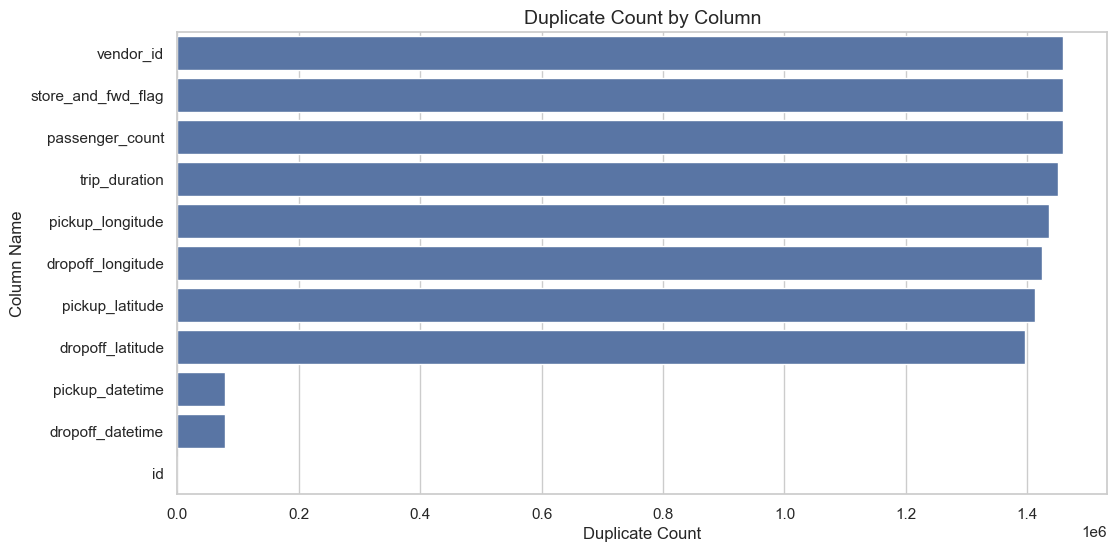

In [6]:

dup_summary = summary_df[["column_name", "duplicate_count", "duplicate_percentage"]].copy()
dup_summary = dup_summary.sort_values(by="duplicate_count", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=dup_summary,
    x="duplicate_count",
    y="column_name"
)

plt.title("Duplicate Count by Column")
plt.xlabel("Duplicate Count")
plt.ylabel("Column Name")
plt.show()

# 2. 🧩 Feature Extraction & Feature Type Classification

In this section, we will identify different types of features from the NYC Taxi Trip dataset before detailed EDA.

---

## 🔢 Numeric Features

### 📏 Continuous Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`
- `trip_duration` 🎯 Target variable

### 👥 Count / Discrete Numeric Features
- `passenger_count`

### 🔢 Ordinal Numeric Features
- No direct ordinal numeric feature found in this dataset

### ⏰ Temporal Numeric Features  
Features that can be extracted from datetime columns:

From `pickup_datetime`:
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `pickup_dayofweek`
- `pickup_weekend`
- `pickup_minute`

From `dropoff_datetime`:
- `dropoff_hour`
- `dropoff_day`
- `dropoff_month`
- `dropoff_dayofweek`

---

## 🏷️ Categorical Features

### 🧾 Nominal Categorical Features
- `vendor_id`

### 🔁 Binary Categorical Features
- `store_and_fwd_flag`

### 📊 Ordinal Categorical Features
- No direct ordinal categorical feature found in this dataset

---

## 🆔 Identifier Feature

### Unique ID
- `id`

This column is mainly used for identifying each trip and is usually not used directly for analysis or modeling.

---

## 🎯 Target Feature

### Prediction Target
- `trip_duration`

This is the main target variable for the NYC Taxi Trip Duration prediction project.

# 3. 🎯 Target Variable Analysis — Trip Duration

In this section, we will analyze the target variable `trip_duration`, which represents the total duration of each taxi trip.  
We will check its basic statistics, distribution pattern, skewness, outliers, and possible transformation needs.  
This step is important because the target variable directly affects model learning and prediction performance.

## 3.1 📌 Basic Summary Statistics of Target Variable

In this step, we will check the basic statistical information of the target variable `trip_duration`.  
This helps us understand the central value, spread, minimum-maximum range, and overall behavior of the target column.

In [7]:
target_col = "trip_duration"

# Safety check
if target_col not in train.columns:
    raise ValueError(f"'{target_col}' column not found in train dataframe.")

target = train[target_col]

# Mode handling
mode_values = target.mode()
mode_value = mode_values.iloc[0] if len(mode_values) > 0 else np.nan

# Basic summary dictionary
target_summary = {
    "Total Count": target.count(),
    "Data Type": target.dtype,
    "Missing Count": target.isnull().sum(),
    "Missing Percentage (%)": round((target.isnull().sum() / len(train)) * 100, 2),
    "Unique Values": target.nunique(),
    "Minimum": target.min(),
    "Maximum": target.max(),
    "Range": target.max() - target.min(),
    "Mean": target.mean(),
    "Median": target.median(),
    "Mode": mode_value,
    "Standard Deviation": target.std(),
    "Variance": target.var(),
    "Skewness": target.skew(),
    "Kurtosis": target.kurtosis(),
    "25th Percentile (Q1)": target.quantile(0.25),
    "50th Percentile (Q2 / Median)": target.quantile(0.50),
    "75th Percentile (Q3)": target.quantile(0.75)
}

# Create dataframe
target_summary_df = pd.DataFrame({
    "Metric": target_summary.keys(),
    "Value": target_summary.values()
})

# Improve display formatting
target_summary_df["Value"] = target_summary_df["Value"].apply(
    lambda x: round(x, 4) if isinstance(x, (int, float, np.integer, np.floating)) else x
)

# Display summary dataframe
target_summary_df

,Metric,Value
0,Total Count,1458644
1,Data Type,int64
2,Missing Count,0
3,Missing Percentage (%),0.0000
4,Unique Values,7417
5,Minimum,1
6,Maximum,3526282
7,Range,3526281
8,Mean,959.4923
9,Median,662.0000


In [8]:
target_summary_df.to_csv("temporal.csv")

### 📝 Summary of Target Variable Basic Statistics

- The dataset contains **1,458,644 trip records** for the target variable `trip_duration`.
- There are **no missing values**, so the target column is complete.
- The minimum trip duration is **1 second**, which may indicate very short or abnormal trips.
- The maximum trip duration is **3,526,282 seconds**, which is extremely large and likely an outlier.
- The mean trip duration is **959.49 seconds**, about **15.99 minutes**.
- The median trip duration is **662 seconds**, about **11.03 minutes**.
- The mode is **368 seconds**, about **6.13 minutes**.
- The mean is higher than the median, which indicates a **right-skewed distribution**.
- The skewness value is **343.16**, showing that the target variable is **highly positively skewed**.
- The kurtosis value is **192,131.52**, which indicates the presence of **extreme outliers**.
- The middle 50% of trips are between **397 seconds** and **1075 seconds**.
- In minutes, most normal trips are roughly between **6.62 minutes** and **17.92 minutes**.
- Outlier analysis and log transformation will be very important before modeling.

## 3.2 🧹 Data Quality Check of Target Variable

In this step, we will check the target variable `trip_duration` for possible data quality issues.  
We will focus on missing values, zero or negative duration, duplicate target values, very small trips, very large trips, and invalid trip duration records.

In [9]:
### 3.2.1 🎯 Select Target Variable

target_col = "trip_duration"

if target_col not in train.columns:
    raise ValueError(f"{target_col} column not found in train dataframe.")

target = train[target_col]
total_rows = len(train)

print("Target Column:", target_col)
print("Total Rows:", total_rows)

Target Column: trip_duration
Total Rows: 1458644


In [10]:
### 3.2.2 🧩 Missing Value Check

missing_count = target.isnull().sum()
missing_percentage = (missing_count / total_rows) * 100

missing_df = pd.DataFrame({
    "Check": ["Missing Values"],
    "Count": [missing_count],
    "Percentage (%)": [round(missing_percentage, 4)]
})

missing_df

,Check,Count,Percentage (%)
0,Missing Values,0,0.0000


In [11]:
### 3.2.3 🚫 Zero Duration Check

zero_count = (target == 0).sum()
zero_percentage = (zero_count / total_rows) * 100

zero_df = pd.DataFrame({
    "Check": ["Zero Duration Values"],
    "Condition": ["trip_duration == 0"],
    "Count": [zero_count],
    "Percentage (%)": [round(zero_percentage, 4)]
})

zero_df

,Check,Condition,Count,Percentage (%)
0,Zero Duration Values,trip_duration == 0,0,0.0000


In [12]:
### 3.2.4 ⛔ Negative Duration Check

negative_count = (target < 0).sum()
negative_percentage = (negative_count / total_rows) * 100

negative_df = pd.DataFrame({
    "Check": ["Negative Duration Values"],
    "Condition": ["trip_duration < 0"],
    "Count": [negative_count],
    "Percentage (%)": [round(negative_percentage, 4)]
})

negative_df

,Check,Condition,Count,Percentage (%)
0,Negative Duration Values,trip_duration < 0,0,0.0000


In [13]:
### 3.2.5 🔁 Duplicate Values Inside Target Column

duplicate_count = target.duplicated().sum()
duplicate_percentage = (duplicate_count / total_rows) * 100

duplicate_target_df = pd.DataFrame({
    "Check": ["Duplicate Values Inside Target Column"],
    "Count": [duplicate_count],
    "Percentage (%)": [round(duplicate_percentage, 4)]
})

duplicate_target_df

,Check,Count,Percentage (%)
0,Duplicate Values Inside Target Column,1451227,99.4915


In [14]:
### 3.2.6 ⏱️ Extremely Small Duration Check

small_duration_threshold = 60   # less than 1 minute

small_duration_count = ((target > 0) & (target < small_duration_threshold)).sum()
small_duration_percentage = (small_duration_count / total_rows) * 100

small_duration_df = pd.DataFrame({
    "Check": ["Extremely Small Duration Values"],
    "Condition": [f"0 < trip_duration < {small_duration_threshold} seconds"],
    "Count": [small_duration_count],
    "Percentage (%)": [round(small_duration_percentage, 4)]
})

small_duration_df

,Check,Condition,Count,Percentage (%)
0,Extremely Small Duration Values,0 < trip_duration < 60 seconds,8595,0.5892


In [15]:
### 3.2.7 🕒 Extremely Large Duration Check

large_duration_threshold = 6 * 3600   # more than 6 hours

large_duration_count = (target > large_duration_threshold).sum()
large_duration_percentage = (large_duration_count / total_rows) * 100

large_duration_df = pd.DataFrame({
    "Check": ["Extremely Large Duration Values"],
    "Condition": [f"trip_duration > {large_duration_threshold} seconds"],
    "Threshold in Hours": [large_duration_threshold / 3600],
    "Count": [large_duration_count],
    "Percentage (%)": [round(large_duration_percentage, 4)]
})

large_duration_df

,Check,Condition,Threshold in Hours,Count,Percentage (%)
0,Extremely Large Duration Values,trip_duration > 21600 seconds,6.0000,2061,0.1413


In [16]:
### 3.2.8 ⚠️ Invalid Trip Duration Check

invalid_duration_threshold = 24 * 3600   # more than 24 hours

invalid_duration_count = (
    target.isnull() |
    (target <= 0) |
    (target > invalid_duration_threshold)
).sum()

invalid_duration_percentage = (invalid_duration_count / total_rows) * 100

invalid_duration_df = pd.DataFrame({
    "Check": ["Invalid Trip Duration Values"],
    "Condition": ["trip_duration is missing OR <= 0 OR > 24 hours"],
    "Count": [invalid_duration_count],
    "Percentage (%)": [round(invalid_duration_percentage, 4)]
})

invalid_duration_df

,Check,Condition,Count,Percentage (%)
0,Invalid Trip Duration Values,trip_duration is missing OR <= 0 OR > 24 hours,4,0.0003


In [17]:
### 3.2.9 📊 Final Target Data Quality Summary

target_quality_summary_df = pd.concat(
    [
        missing_df,
        zero_df[["Check", "Count", "Percentage (%)"]],
        negative_df[["Check", "Count", "Percentage (%)"]],
        duplicate_target_df,
        small_duration_df[["Check", "Count", "Percentage (%)"]],
        large_duration_df[["Check", "Count", "Percentage (%)"]],
        invalid_duration_df[["Check", "Count", "Percentage (%)"]]
    ],
    ignore_index=True
)

target_quality_summary_df

,Check,Count,Percentage (%)
0,Missing Values,0,0.0000
1,Zero Duration Values,0,0.0000
2,Negative Duration Values,0,0.0000
3,Duplicate Values Inside Target Column,1451227,99.4915
4,Extremely Small Duration Values,8595,0.5892
5,Extremely Large Duration Values,2061,0.1413
6,Invalid Trip Duration Values,4,0.0003


In [18]:
### 3.2.10 🔎 View Suspicious Target Records

suspicious_target_rows = train[
    (target.isnull()) |
    (target <= 0) |
    ((target > 0) & (target < 60)) |
    (target > 24 * 3600)
]

print("Suspicious Target Records:", suspicious_target_rows.shape[0])

suspicious_target_rows.head()

Suspicious Target Records: 8599


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
72,id1510700,2,2016-02-20 21:58:13,2016-02-20 21:59:10,1,-73.9584,40.7726,-73.9551,40.7742,N,57
323,id2954399,1,2016-06-27 11:22:37,2016-06-27 11:23:17,1,-74.0010,40.7567,-74.0010,40.7566,N,40
842,id3263580,2,2016-05-21 12:46:46,2016-05-21 12:46:49,2,-73.7824,40.6488,-73.7824,40.6487,N,3
853,id2730154,2,2016-03-29 22:39:46,2016-03-29 22:40:44,5,-73.9822,40.7318,-73.9799,40.7348,N,58
1107,id0729156,2,2016-06-23 13:36:48,2016-06-23 13:36:50,3,-73.8277,40.7162,-73.8221,40.7115,N,2


In [19]:
### 3.2.11 🎨 Styled Target Data Quality Summary

target_quality_summary_df.style.background_gradient(
    subset=["Count", "Percentage (%)"],
    cmap="Reds"
)

,Check,Count,Percentage (%)
0,Missing Values,0,0.000000
1,Zero Duration Values,0,0.000000
2,Negative Duration Values,0,0.000000
3,Duplicate Values Inside Target Column,1451227,99.491500
4,Extremely Small Duration Values,8595,0.589200
5,Extremely Large Duration Values,2061,0.141300
6,Invalid Trip Duration Values,4,0.000300


In [20]:
suspicious_target_rows.to_csv("temporal_1.csv")

In [21]:
target_quality_summary_df.to_csv("temporal_2.csv")

### 📝 Summary of Target Variable Data Quality Check

- The target variable `trip_duration` has **0 missing values**, so there is no missing data problem in the target column.
- There are **0 zero duration values**, which means no trip has exactly `0` seconds duration.
- There are **0 negative duration values**, so the target column does not contain impossible negative trip durations.
- The target column has **1,451,227 duplicate duration values**, around **99.49%**, but this is **normal** because many taxi trips can have the same duration.
- There are **8,595 extremely small duration values**, around **0.59%**, where trip duration is less than **1 minute**.
- There are **2,061 extremely large duration values**, around **0.14%**, where trip duration is greater than **6 hours**.
- There are only **4 invalid trip duration values**, around **0.0003%**, based on the condition `trip_duration <= 0` or `trip_duration > 24 hours`.
- Overall, the target variable has no missing, zero, or negative value issues.
- However, very small trips and very large trips should be checked carefully because they may contain abnormal or unusual trip records.
- For the next step, outlier analysis is important to decide whether these extreme duration values should be removed, capped, or transformed.

## 3.3 📊 Distribution Analysis of Target Variable

In this section, we will analyze the distribution pattern of `trip_duration`.  
We will use histogram, KDE plot, frequency distribution, log-transformed distribution, and distribution shape checking to understand whether the target variable is normal-like or skewed.

In [22]:
### 3.3.1 🎯 Select Target Variable for Distribution Analysis

target_col = "trip_duration"

target = train[target_col]

print("Target Column:", target_col)
print("Total Values:", len(target))
print("Minimum Duration:", target.min())
print("Maximum Duration:", target.max())

Target Column: trip_duration
Total Values: 1458644
Minimum Duration: 1
Maximum Duration: 3526282


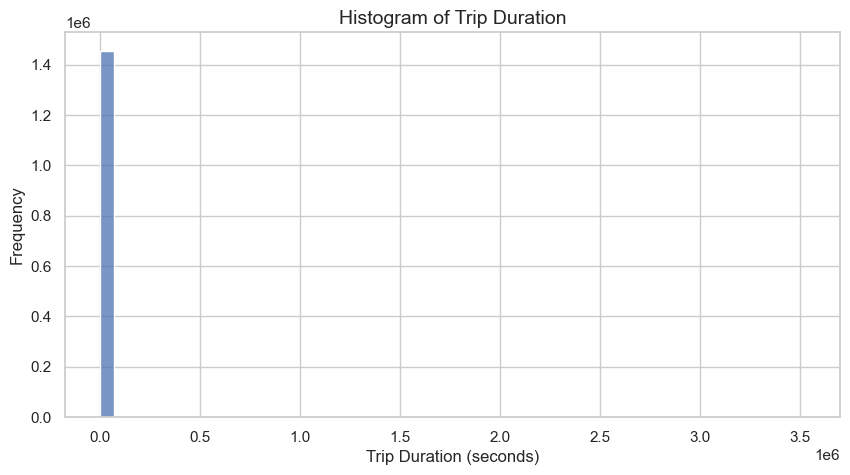

In [23]:
### 3.3.2 📊 Histogram of Trip Duration

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x=target_col,
    bins=50
)

plt.title("Histogram of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

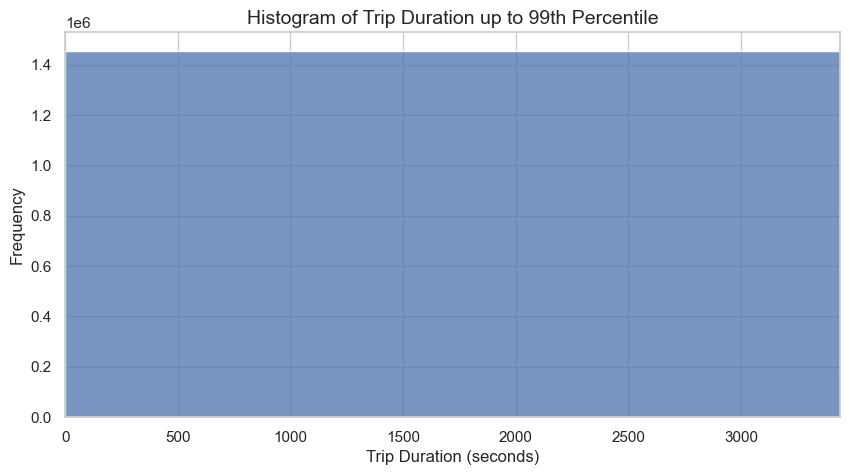

In [24]:
### 3.3.3 📊 Histogram with Limited Range

plt.figure(figsize=(10, 5))

sns.histplot(
    train[target_col],
    bins=50
)

plt.xlim(0, train[target_col].quantile(0.99))

plt.title("Histogram of Trip Duration up to 99th Percentile")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

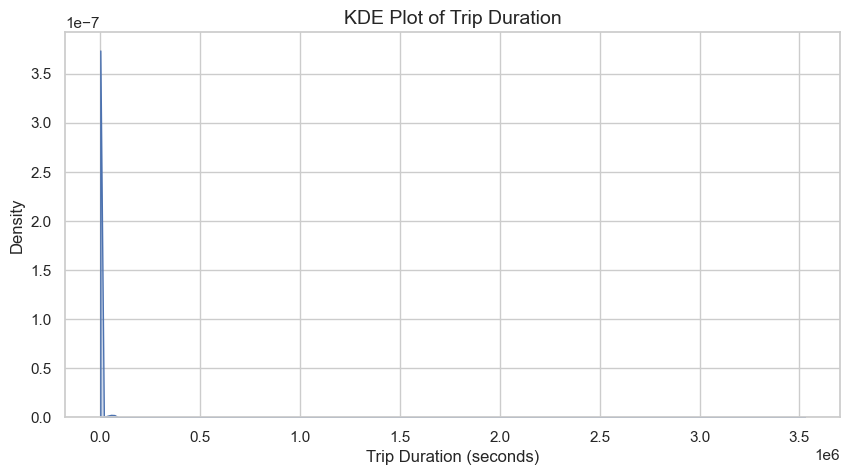

In [25]:
### 3.3.4 🌊 KDE Plot of Trip Duration

plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=train,
    x=target_col,
    fill=True
)

plt.title("KDE Plot of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Density")
plt.show()

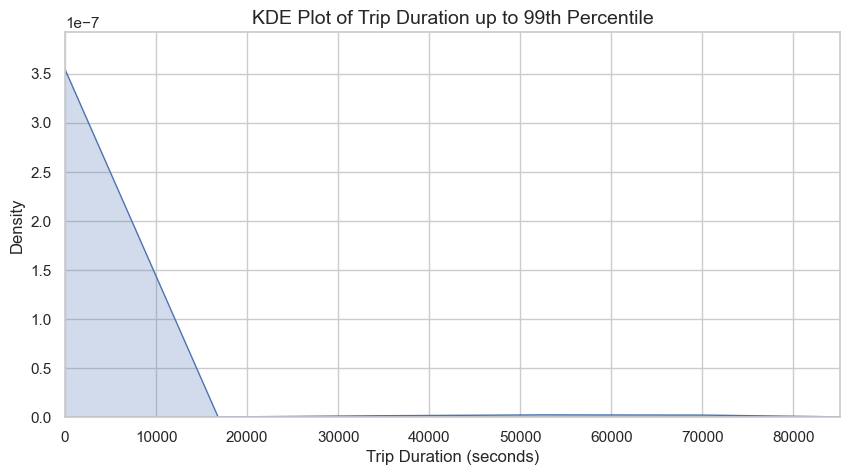

In [26]:
### 3.3.5 🌊 KDE Plot with Limited Range

plt.figure(figsize=(10, 5))

sns.kdeplot(
    train[target_col],
    fill=True
)

plt.xlim(0, train[target_col].quantile(0.999))

plt.title("KDE Plot of Trip Duration up to 99th Percentile")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Density")
plt.show()

In [27]:
### 3.3.6 📋 Frequency Distribution Table

frequency_df = train[target_col].value_counts().reset_index()

frequency_df.columns = ["trip_duration", "frequency"]

frequency_df = frequency_df.sort_values(
    by="frequency",
    ascending=False
).reset_index(drop=True)

frequency_df

,trip_duration,frequency
0,368,1624
1,408,1584
2,348,1582
3,367,1581
4,358,1577
...,...,...
7412,85163,1
7413,85484,1
7414,85537,1
7415,8351,1


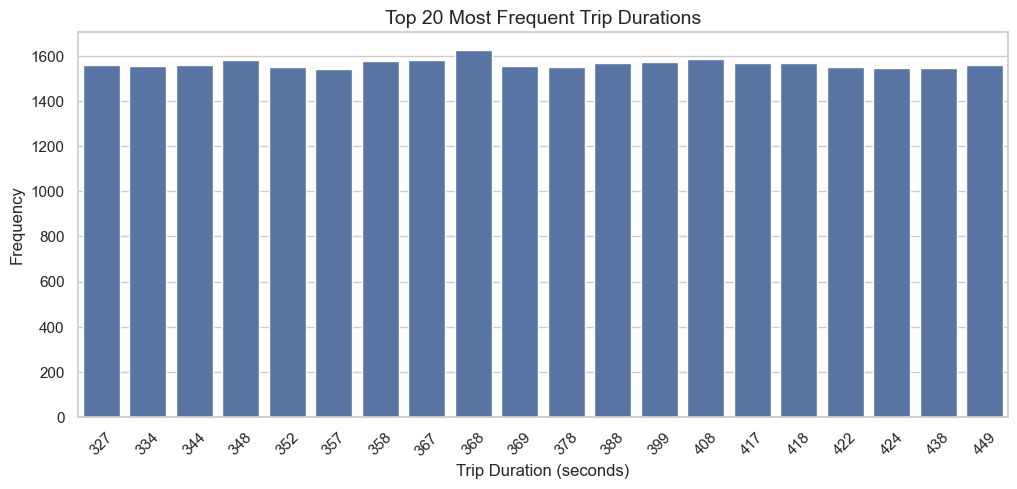

In [28]:
### 3.3.7 🔝 Top 20 Most Frequent Trip Durations

top_20_frequency = frequency_df.head(20)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_20_frequency,
    x="trip_duration",
    y="frequency"
)

plt.title("Top 20 Most Frequent Trip Durations")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [29]:
### 3.3.8 🔄 Create Log-Transformed Target Variable

train["log_trip_duration"] = np.log1p(train[target_col])

print("Original Target:", target_col)
print("Log Transformed Target: log_trip_duration")

train[[target_col, "log_trip_duration"]].head()

Original Target: trip_duration
Log Transformed Target: log_trip_duration


,trip_duration,log_trip_duration
0,455,6.1225
1,663,6.4983
2,2124,7.6615
3,429,6.0638
4,435,6.0776


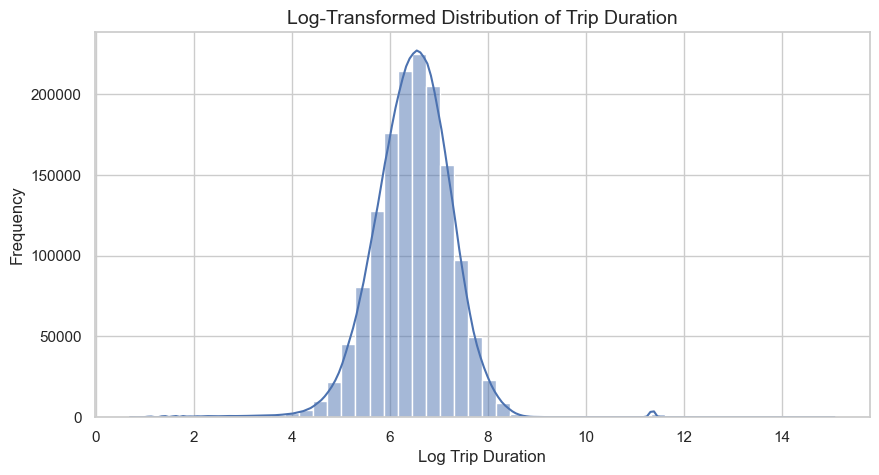

In [30]:
### 3.3.9 📊 Log-Transformed Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x="log_trip_duration",
    bins=50,
    kde=True
)

plt.title("Log-Transformed Distribution of Trip Duration")
plt.xlabel("Log Trip Duration")
plt.ylabel("Frequency")
plt.show()

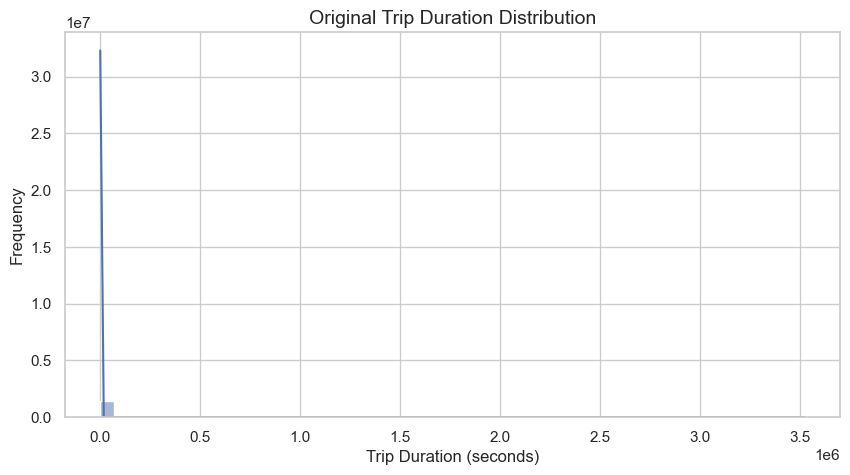

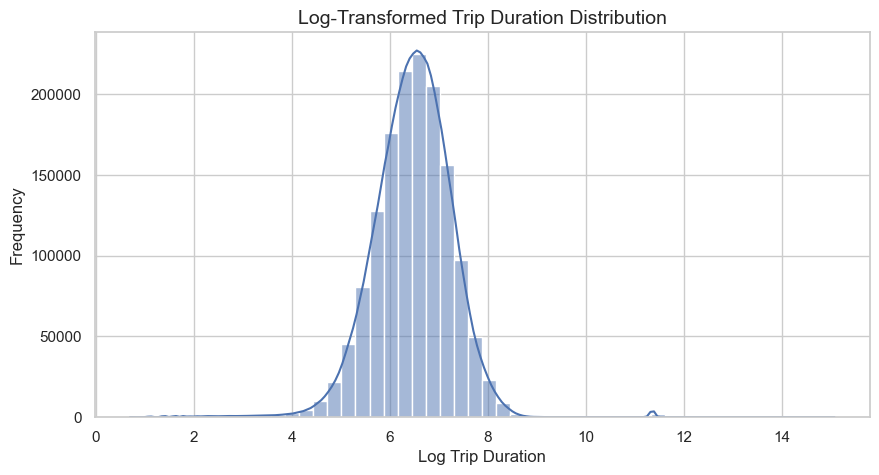

In [31]:
### 3.3.10 📊 Original vs Log-Transformed Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    train[target_col],
    bins=50,
    kde=True
)


plt.title("Original Trip Duration Distribution")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(10, 5))

sns.histplot(
    train["log_trip_duration"],
    bins=50,
    kde=True
)

plt.title("Log-Transformed Trip Duration Distribution")
plt.xlabel("Log Trip Duration")
plt.ylabel("Frequency")
plt.show()

In [32]:
### 3.3.11 📐 Distribution Shape Checking

mean_value = train[target_col].mean()
median_value = train[target_col].median()
mode_value = train[target_col].mode()[0]

skewness_value = train[target_col].skew()
kurtosis_value = train[target_col].kurtosis()

distribution_shape_df = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Mode",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        mean_value,
        median_value,
        mode_value,
        skewness_value,
        kurtosis_value
    ]
})

distribution_shape_df["Value"] = distribution_shape_df["Value"].round(4)

distribution_shape_df

,Metric,Value
0,Mean,959.4923
1,Median,662.0000
2,Mode,368.0000
3,Skewness,343.1639
4,Kurtosis,192131.5173


In [33]:
### 3.3.12 🧠 Automatic Skewness Interpretation

if skewness_value > 1:
    shape = "Highly Right-Skewed"
elif skewness_value > 0.5:
    shape = "Moderately Right-Skewed"
elif skewness_value < -1:
    shape = "Highly Left-Skewed"
elif skewness_value < -0.5:
    shape = "Moderately Left-Skewed"
else:
    shape = "Approximately Symmetric / Normal-like"

shape_df = pd.DataFrame({
    "Target Variable": [target_col],
    "Skewness": [round(skewness_value, 4)],
    "Distribution Shape": [shape]
})

shape_df

,Target Variable,Skewness,Distribution Shape
0,trip_duration,343.1639,Highly Right-Skewed


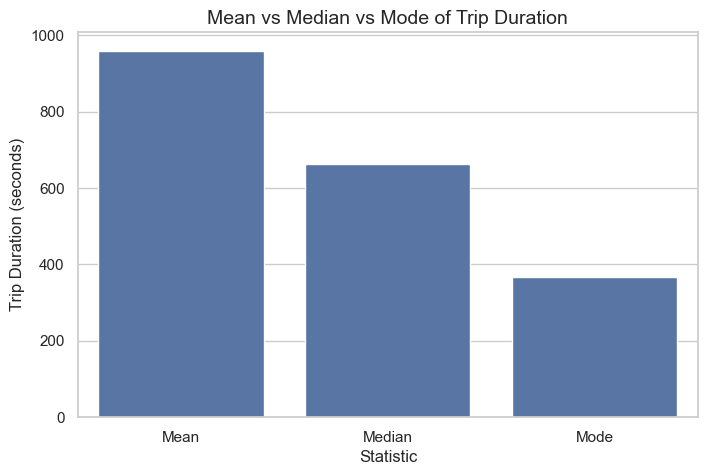

In [34]:
### 3.3.13 📊 Mean vs Median Visualization

mean_median_df = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode"],
    "Value": [mean_value, median_value, mode_value]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=mean_median_df,
    x="Statistic",
    y="Value"
)

plt.title("Mean vs Median vs Mode of Trip Duration")
plt.xlabel("Statistic")
plt.ylabel("Trip Duration (seconds)")
plt.show()

In [35]:
### 3.3.14 📌 Final Distribution Summary DataFrame

distribution_summary_df = pd.DataFrame({
    "Analysis Point": [
        "Original Distribution",
        "Mean vs Median",
        "Skewness",
        "Kurtosis",
        "Log Transformation"
    ],
    "Finding": [
        "Checked using histogram and KDE plot",
        "Mean is compared with median to detect skewness",
        f"Skewness value is {round(skewness_value, 4)}",
        f"Kurtosis value is {round(kurtosis_value, 4)}",
        "Log transformation was applied using np.log1p()"
    ]
})

distribution_summary_df

,Analysis Point,Finding
0,Original Distribution,Checked using histogram and KDE plot
1,Mean vs Median,Mean is compared with median to detect skewness
2,Skewness,Skewness value is 343.1639
3,Kurtosis,Kurtosis value is 192131.5173
4,Log Transformation,Log transformation was applied using np.log1p()


### 📝 Summary of Target Variable Distribution Analysis

- The original `trip_duration` distribution is **highly right-skewed**.
- Most trip duration values are concentrated near the lower range, but a few extremely large values stretch the graph to the right.
- Because of extreme high values, the original histogram looks compressed near zero.
- The log-transformed distribution is much clearer and more balanced than the original distribution.
- After applying `log1p(trip_duration)`, the distribution becomes close to a normal-like bell shape.
- The log-transformed plot shows that most trips are concentrated around the middle duration range.
- A small separate peak in the far right side of the log plot indicates the presence of some extremely long-duration trips.
- The mean trip duration is higher than the median and mode.
- Mean ≈ **959 seconds**, median ≈ **662 seconds**, and mode ≈ **368 seconds**.
- Since `Mean > Median > Mode`, the target variable has a **positive/right-skewed distribution**.
- This confirms that some very long trips are pulling the average duration upward.
- For modeling, using `log_trip_duration` can be more useful than using raw `trip_duration`.
- Outlier analysis is needed next to identify extremely short and extremely long trip records.

## 3.4 📦 Outlier Analysis of Target Variable

In this section, we will detect outliers in `trip_duration` using the IQR method.  
We will calculate Q1, Q3, IQR, lower bound, upper bound, outlier count, and outlier percentage.  
Finally, we will check how the distribution looks after outlier handling.

In [36]:
### 3.4.1 📌 IQR-Based Outlier Summary

target_col = "trip_duration"
target = train[target_col]
total_rows = len(train)

# IQR calculation
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outlier masks
lower_outlier_mask = target < lower_bound
upper_outlier_mask = target > upper_bound
outlier_mask = lower_outlier_mask | upper_outlier_mask

# Counts
lower_outlier_count = lower_outlier_mask.sum()
upper_outlier_count = upper_outlier_mask.sum()
total_outlier_count = outlier_mask.sum()

# Percentages
lower_outlier_percentage = (lower_outlier_count / total_rows) * 100
upper_outlier_percentage = (upper_outlier_count / total_rows) * 100
total_outlier_percentage = (total_outlier_count / total_rows) * 100

# Summary dataframe
outlier_summary_df = pd.DataFrame({
    "Metric": [
        "Q1 - 25th Percentile",
        "Q3 - 75th Percentile",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Lower Outlier Count",
        "Upper Outlier Count",
        "Total Outlier Count",
        "Lower Outlier Percentage (%)",
        "Upper Outlier Percentage (%)",
        "Total Outlier Percentage (%)"
    ],
    "Value": [
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        lower_outlier_count,
        upper_outlier_count,
        total_outlier_count,
        lower_outlier_percentage,
        upper_outlier_percentage,
        total_outlier_percentage
    ]
})

outlier_summary_df["Value"] = outlier_summary_df["Value"].round(4)

outlier_summary_df

,Metric,Value
0,Q1 - 25th Percentile,397.0000
1,Q3 - 75th Percentile,1075.0000
2,IQR,678.0000
3,Lower Bound,-620.0000
4,Upper Bound,2092.0000
5,Lower Outlier Count,0.0000
6,Upper Outlier Count,74220.0000
7,Total Outlier Count,74220.0000
8,Lower Outlier Percentage (%),0.0000
9,Upper Outlier Percentage (%),5.0883


In [37]:
### 3.4.2 🔎 Extreme Lower & Upper Duration Values

display_cols = [col for col in ["id", "pickup_datetime", "dropoff_datetime", target_col] if col in train.columns]

extreme_lower_values = train[display_cols].sort_values(by=target_col, ascending=True).head(10)
extreme_upper_values = train[display_cols].sort_values(by=target_col, ascending=False).head(10)

print("Extreme Lower Duration Values:")
display(extreme_lower_values)

print("Extreme Upper Duration Values:")
display(extreme_upper_values)

Extreme Lower Duration Values:


,id,pickup_datetime,dropoff_datetime,trip_duration
1306890,id2608913,2016-03-12 02:15:31,2016-03-12 02:15:32,1
1063496,id3712815,2016-06-20 20:16:17,2016-06-20 20:16:18,1
810851,id1250016,2016-03-03 17:02:47,2016-03-03 17:02:48,1
1382872,id0839864,2016-02-06 13:40:27,2016-02-06 13:40:28,1
451396,id2836747,2016-01-26 10:47:22,2016-01-26 10:47:23,1
600247,id2517984,2016-01-09 00:28:55,2016-01-09 00:28:56,1
1439166,id2943073,2016-01-03 16:55:44,2016-01-03 16:55:45,1
35196,id2536510,2016-04-17 11:44:49,2016-04-17 11:44:50,1
610159,id0578509,2016-02-03 12:35:22,2016-02-03 12:35:23,1
1029695,id2115750,2016-04-22 16:00:22,2016-04-22 16:00:23,1


Extreme Upper Duration Values:


,id,pickup_datetime,dropoff_datetime,trip_duration
978383,id0053347,2016-02-13 22:46:52,2016-03-25 18:18:14,3526282
924150,id1325766,2016-01-05 06:14:15,2016-01-31 01:01:07,2227612
680594,id0369307,2016-02-13 22:38:00,2016-03-08 15:57:38,2049578
355003,id1864733,2016-01-05 00:19:42,2016-01-27 11:08:38,1939736
1234291,id1942836,2016-02-15 23:18:06,2016-02-16 23:17:58,86392
295382,id0593332,2016-05-31 13:00:39,2016-06-01 13:00:30,86391
73816,id0953667,2016-05-06 00:00:10,2016-05-07 00:00:00,86390
59891,id2837671,2016-06-30 16:37:52,2016-07-01 16:37:39,86387
1360439,id1358458,2016-06-23 16:01:45,2016-06-24 16:01:30,86385
753765,id2589925,2016-05-17 22:22:56,2016-05-18 22:22:35,86379


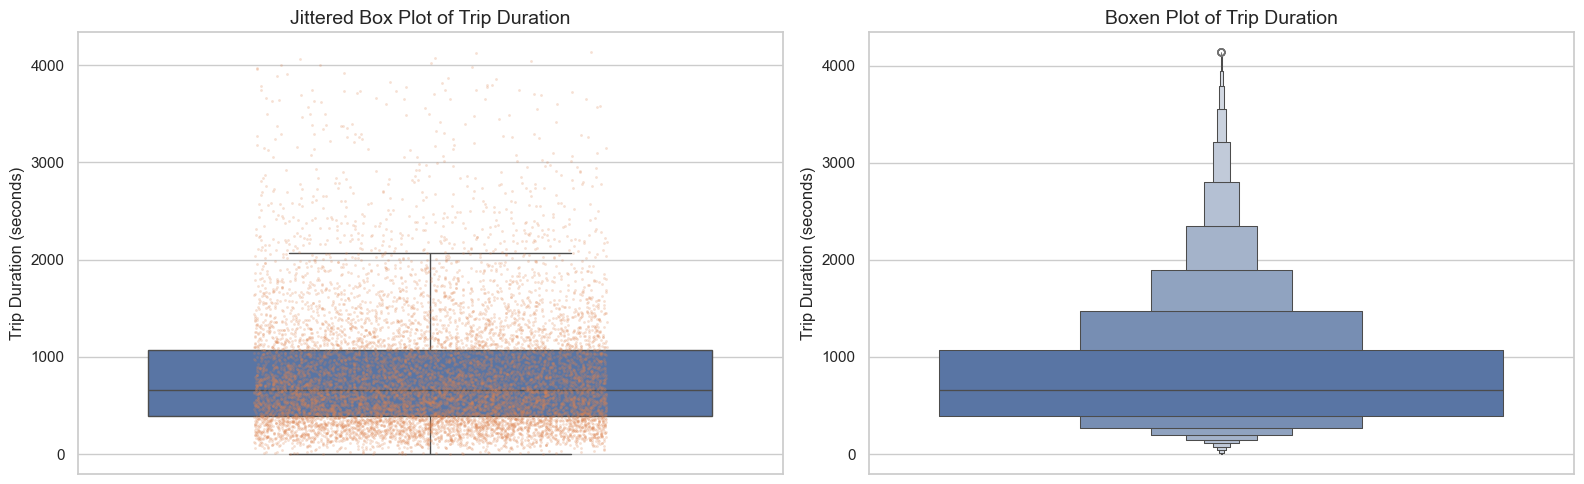

In [38]:
### 3.4.3 📊 Jittered Box Plot & Boxen Plot

# For better visualization only, limit extreme display range
visual_upper_limit = target.quantile(0.995)

visual_data = train[train[target_col] <= visual_upper_limit][[target_col]].copy()

# Sample for jitter plot to avoid heavy plotting
sample_size = min(10000, len(visual_data))
jitter_sample = visual_data.sample(sample_size, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Jittered Box Plot
sns.boxplot(
    data=visual_data,
    y=target_col,
    ax=axes[0],
    showfliers=False
)

sns.stripplot(
    data=jitter_sample,
    y=target_col,
    ax=axes[0],
    jitter=0.25,
    size=2,
    alpha=0.25
)

axes[0].set_title("Jittered Box Plot of Trip Duration")
axes[0].set_ylabel("Trip Duration (seconds)")

# 2. Boxen Plot
sns.boxenplot(
    data=visual_data,
    y=target_col,
    ax=axes[1]
)

axes[1].set_title("Boxen Plot of Trip Duration")
axes[1].set_ylabel("Trip Duration (seconds)")

plt.tight_layout()
plt.show()

In [39]:
### 3.4.4 🧹 Create Outlier-Handled Target Using IQR Filtering

# IQR-based filtering
target_iqr_handled = target[(target >= lower_bound) & (target <= upper_bound)]

outlier_handling_df = pd.DataFrame({
    "Stage": [
        "Original Target",
        "After IQR Outlier Handling",
        "Removed as Outliers"
    ],
    "Row Count": [
        len(target),
        len(target_iqr_handled),
        len(target) - len(target_iqr_handled)
    ],
    "Percentage (%)": [
        100,
        (len(target_iqr_handled) / len(target)) * 100,
        ((len(target) - len(target_iqr_handled)) / len(target)) * 100
    ]
})

outlier_handling_df["Percentage (%)"] = outlier_handling_df["Percentage (%)"].round(4)

outlier_handling_df

,Stage,Row Count,Percentage (%)
0,Original Target,1458644,100.0000
1,After IQR Outlier Handling,1384424,94.9117
2,Removed as Outliers,74220,5.0883


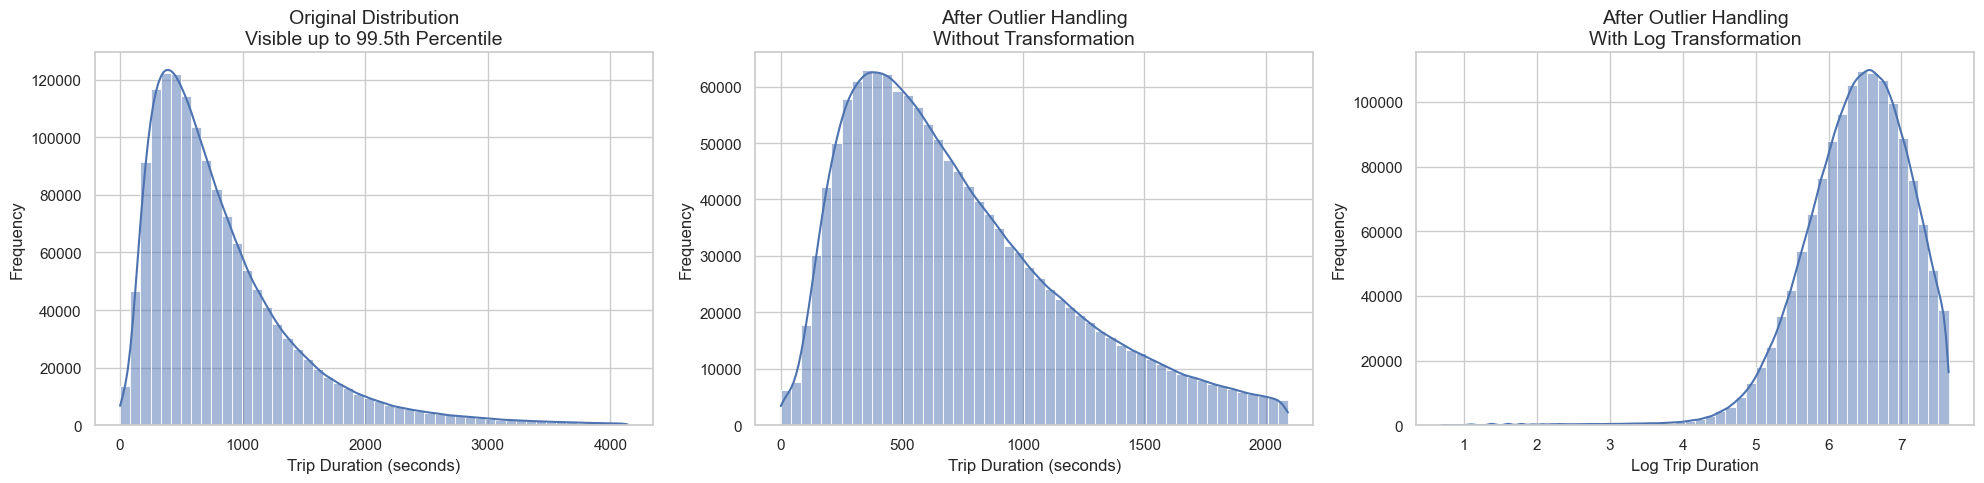

In [40]:
### 3.4.5 📊 Distribution Check Before & After Outlier Handling

log_target_iqr_handled = np.log1p(target_iqr_handled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Original distribution
sns.histplot(
    target[target <= target.quantile(0.995)],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Distribution\nVisible up to 99.5th Percentile")
axes[0].set_xlabel("Trip Duration (seconds)")
axes[0].set_ylabel("Frequency")

# 2. Outlier-handled distribution without transformation
sns.histplot(
    target_iqr_handled,
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("After Outlier Handling\nWithout Transformation")
axes[1].set_xlabel("Trip Duration (seconds)")
axes[1].set_ylabel("Frequency")

# 3. Outlier-handled distribution with log transformation
sns.histplot(
    log_target_iqr_handled,
    bins=50,
    kde=True,
    ax=axes[2]
)

axes[2].set_title("After Outlier Handling\nWith Log Transformation")
axes[2].set_xlabel("Log Trip Duration")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [41]:
### 3.4.6 📌 Distribution Statistics Before & After Outlier Handling

comparison_df = pd.DataFrame({
    "Version": [
        "Original Target",
        "IQR Outlier Handled",
        "IQR Handled + Log Transform"
    ],
    "Mean": [
        target.mean(),
        target_iqr_handled.mean(),
        log_target_iqr_handled.mean()
    ],
    "Median": [
        target.median(),
        target_iqr_handled.median(),
        log_target_iqr_handled.median()
    ],
    "Min": [
        target.min(),
        target_iqr_handled.min(),
        log_target_iqr_handled.min()
    ],
    "Max": [
        target.max(),
        target_iqr_handled.max(),
        log_target_iqr_handled.max()
    ],
    "Skewness": [
        target.skew(),
        target_iqr_handled.skew(),
        log_target_iqr_handled.skew()
    ],
    "Kurtosis": [
        target.kurtosis(),
        target_iqr_handled.kurtosis(),
        log_target_iqr_handled.kurtosis()
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Version,Mean,Median,Min,Max,Skewness,Kurtosis
0,Original Target,959.4923,662.0000,1.0000,3526282.0000,343.1639,192131.5173
1,IQR Outlier Handled,731.7026,632.0000,1.0000,2092.0000,0.8609,0.1315
2,IQR Handled + Log Transform,6.3836,6.4505,0.6931,7.6464,-1.0220,3.2551


### 📝 Summary of Target Variable Outlier Analysis

- Using the IQR method, `Q1 = 397 seconds` and `Q3 = 1075 seconds`.
- The `IQR = 678 seconds`, which represents the spread of the middle 50% trip durations.
- The calculated lower bound is `-620 seconds`, but trip duration cannot be negative.
- Therefore, there are **0 lower outliers** based on the IQR method.
- The upper bound is `2092 seconds`, around **34.87 minutes**.
- Any trip duration greater than `2092 seconds` is considered an upper outlier by the IQR rule.
- Total outliers found: **74,220 records**, around **5.09%** of the dataset.
- All detected outliers are upper outliers, which confirms that `trip_duration` has a strong right-side tail.
- Extreme lower values show some trips with only **1 second duration**, which may represent abnormal, cancelled, or incorrect records.
- Extreme upper values show very large durations, including values like **3,526,282 seconds**, which are clearly unrealistic for normal taxi trips.
- The original distribution is highly right-skewed because of these extreme long-duration trips.
- After IQR-based outlier handling, the distribution becomes much cleaner and more readable.
- After outlier handling, the maximum duration becomes `2092 seconds`, making the target range more realistic.
- The skewness decreases from **343.16** to **0.86**, which shows a major improvement.
- The kurtosis decreases from **192,131.52** to **0.13**, meaning extreme tail effect is greatly reduced.
- After applying log transformation on the outlier-handled target, the distribution becomes more compact and closer to a normal-like shape.
- However, the log-transformed version becomes slightly left-skewed with skewness around **-1.02**.
- For modeling, the outlier-handled target or log-transformed target can be considered depending on the model type.

✅ Use outlier-handled target without log transformation  
❌ Do not apply log transformation after aggressive IQR outlier handling  
⚠️ Use transformation only if it improves distribution or model performance

## 3.5 📍 Percentile / Quantile Analysis of Target Variable

In this section, we will analyze important percentile values of `trip_duration`.  
Because the raw target contains extreme outliers, percentile visualization will be done mainly on the IQR outlier-handled target.  
This helps us understand how trip durations are distributed across different percentage levels.

In [42]:
### 3.5.1 📌 Create Percentile List

target_col = "trip_duration"
target = train[target_col]

percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]

percentile_labels = [
    "1st Percentile",
    "5th Percentile",
    "10th Percentile",
    "25th Percentile",
    "50th Percentile / Median",
    "75th Percentile",
    "90th Percentile",
    "95th Percentile",
    "99th Percentile",
    "99.5th Percentile",
    "99.9th Percentile"
]

In [43]:
### 3.5.2 📦 Create IQR Outlier-Handled Target

Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

target_iqr_handled = target[
    (target >= lower_bound) &
    (target <= upper_bound)
]

print("Original target size:", len(target))
print("After IQR outlier handling:", len(target_iqr_handled))
print("Upper bound:", upper_bound)

Original target size: 1458644
After IQR outlier handling: 1384424
Upper bound: 2092.0


In [44]:
### 3.5.3 📊 Percentile Table: Original vs Outlier-Handled Target

original_percentile_values = target.quantile(percentiles).values
handled_percentile_values = target_iqr_handled.quantile(percentiles).values

percentile_df = pd.DataFrame({
    "Percentile": percentile_labels,
    "Original Duration (sec)": original_percentile_values,
    "Original Duration (min)": original_percentile_values / 60,
    "After Outlier Handling (sec)": handled_percentile_values,
    "After Outlier Handling (min)": handled_percentile_values / 60
})

percentile_df = percentile_df.round(2)

percentile_df

,Percentile,Original Duration (sec),Original Duration (min),After Outlier Handling (sec),After Outlier Handling (min)
0,1st Percentile,87.0000,1.4500,84.0000,1.4000
1,5th Percentile,180.0000,3.0000,176.0000,2.9300
2,10th Percentile,245.0000,4.0800,239.0000,3.9800
3,25th Percentile,397.0000,6.6200,384.0000,6.4000
4,50th Percentile / Median,662.0000,11.0300,632.0000,10.5300
5,75th Percentile,1075.0000,17.9200,991.0000,16.5200
6,90th Percentile,1634.0000,27.2300,1400.0000,23.3300
7,95th Percentile,2104.0000,35.0700,1645.0000,27.4200
8,99th Percentile,3440.0000,57.3300,1971.0000,32.8500
9,99.5th Percentile,4139.0000,68.9800,2029.0000,33.8200


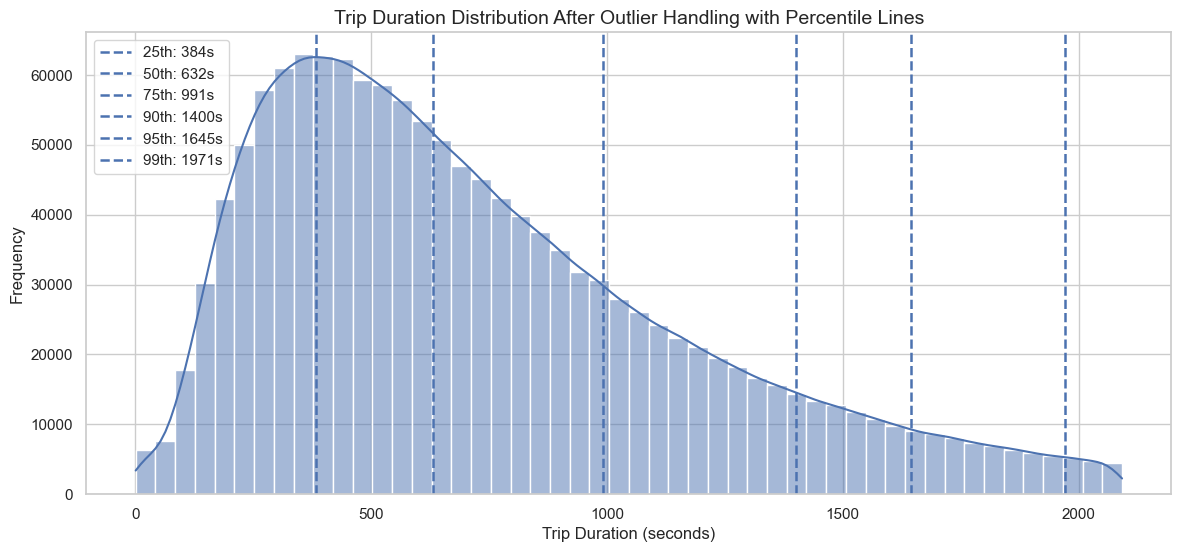

In [45]:
### 3.5.4 📊 Percentile Distribution Plot After Outlier Handling

major_percentiles = {
    "25th": target_iqr_handled.quantile(0.25),
    "50th": target_iqr_handled.quantile(0.50),
    "75th": target_iqr_handled.quantile(0.75),
    "90th": target_iqr_handled.quantile(0.90),
    "95th": target_iqr_handled.quantile(0.95),
    "99th": target_iqr_handled.quantile(0.99)
}

plt.figure(figsize=(14, 6))

sns.histplot(
    target_iqr_handled,
    bins=50,
    kde=True
)

for label, value in major_percentiles.items():
    plt.axvline(
        value,
        linestyle="--",
        linewidth=1.8,
        label=f"{label}: {value:.0f}s"
    )

plt.title("Trip Duration Distribution After Outlier Handling with Percentile Lines")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

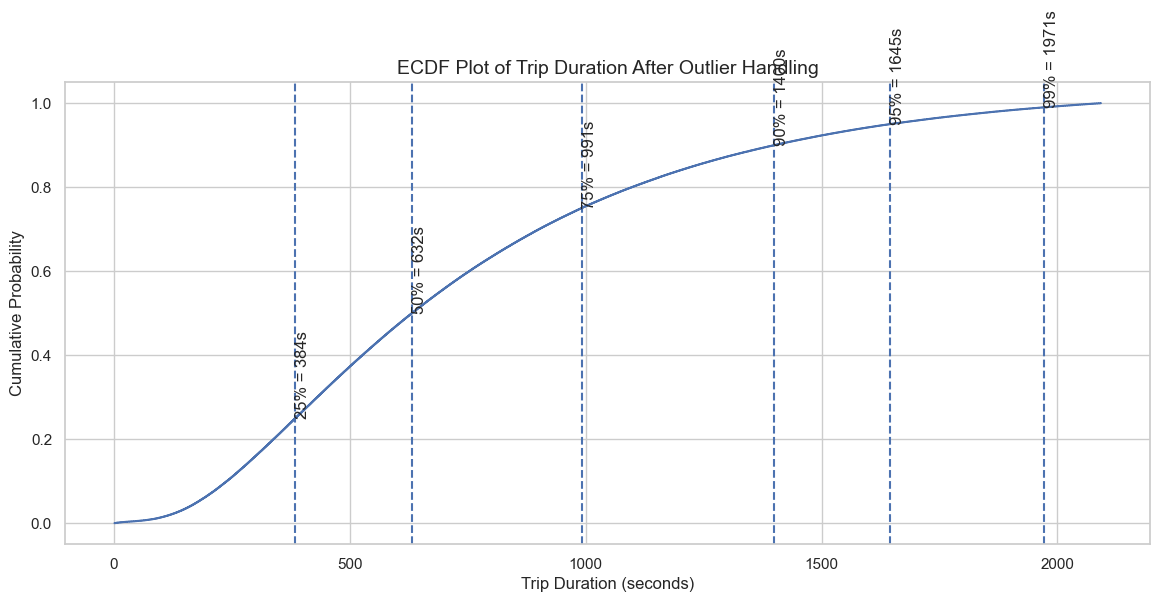

In [46]:
### 3.5.5 📈 ECDF Plot with Percentile Markers

sorted_target = np.sort(target_iqr_handled)
ecdf = np.arange(1, len(sorted_target) + 1) / len(sorted_target)

plt.figure(figsize=(14, 6))

plt.plot(sorted_target, ecdf)

for p in [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    value = target_iqr_handled.quantile(p)
    plt.axvline(value, linestyle="--", linewidth=1.5)
    plt.text(
        value,
        p,
        f"{int(p*100)}% = {value:.0f}s",
        rotation=90,
        verticalalignment="bottom"
    )

plt.title("ECDF Plot of Trip Duration After Outlier Handling")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.show()

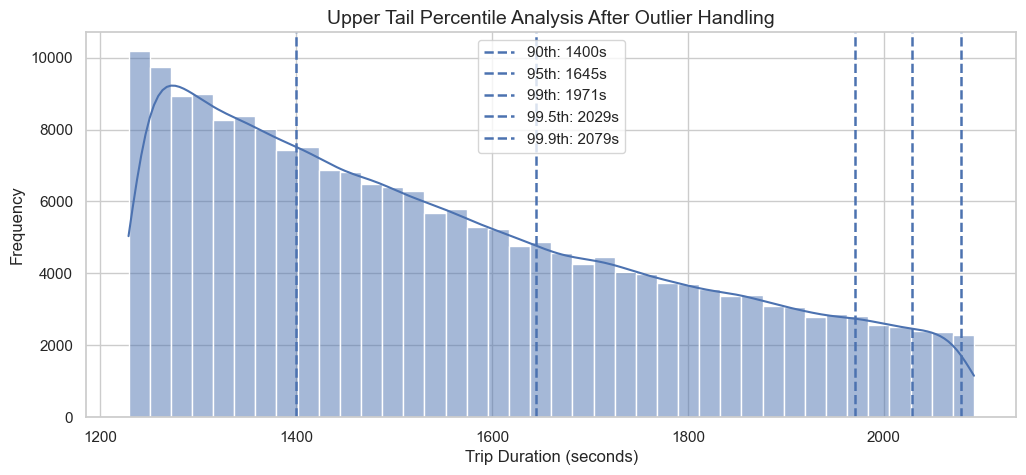

In [47]:
### 3.5.6 🔍 Tail Percentile Zoom Plot

tail_percentiles = {
    "90th": target_iqr_handled.quantile(0.90),
    "95th": target_iqr_handled.quantile(0.95),
    "99th": target_iqr_handled.quantile(0.99),
    "99.5th": target_iqr_handled.quantile(0.995),
    "99.9th": target_iqr_handled.quantile(0.999)
}

plt.figure(figsize=(12, 5))

sns.histplot(
    target_iqr_handled[target_iqr_handled >= target_iqr_handled.quantile(0.85)],
    bins=40,
    kde=True
)

for label, value in tail_percentiles.items():
    plt.axvline(
        value,
        linestyle="--",
        linewidth=1.8,
        label=f"{label}: {value:.0f}s"
    )

plt.title("Upper Tail Percentile Analysis After Outlier Handling")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [48]:
### 3.5.7 📌 Percentile-Based Quick Interpretation Table

interpretation_df = pd.DataFrame({
    "Percentile Range": [
        "Below 25th Percentile",
        "25th to 50th Percentile",
        "50th to 75th Percentile",
        "75th to 90th Percentile",
        "90th to 95th Percentile",
        "95th to 99th Percentile",
        "Above 99th Percentile"
    ],
    "Meaning": [
        "Very short trips",
        "Short trips",
        "Medium trips",
        "Medium to long trips",
        "Long trips",
        "Very long trips",
        "Extreme upper tail trips"
    ]
})

interpretation_df

,Percentile Range,Meaning
0,Below 25th Percentile,Very short trips
1,25th to 50th Percentile,Short trips
2,50th to 75th Percentile,Medium trips
3,75th to 90th Percentile,Medium to long trips
4,90th to 95th Percentile,Long trips
5,95th to 99th Percentile,Very long trips
6,Above 99th Percentile,Extreme upper tail trips


### 📝 Summary of Percentile / Quantile Analysis

- Percentile analysis was done after IQR-based outlier handling because the raw `trip_duration` had extreme values.
- After outlier handling, the distribution becomes easier to understand and percentile lines are clearly visible.
- The 25th percentile is around **384 seconds**, meaning 25% of trips are shorter than about **6.4 minutes**.
- The median / 50th percentile is around **632 seconds**, meaning 50% of trips are shorter than about **10.5 minutes**.
- The 75th percentile is around **991 seconds**, meaning 75% of trips are shorter than about **16.5 minutes**.
- The 90th percentile is around **1400 seconds**, meaning 90% of trips are shorter than about **23.3 minutes**.
- The 95th percentile is around **1645 seconds**, meaning 95% of trips are shorter than about **27.4 minutes**.
- The 99th percentile is around **1971 seconds**, meaning 99% of trips are shorter than about **32.9 minutes**.
- The 99.5th and 99.9th percentiles are close to the upper end of the outlier-handled range.
- The ECDF plot confirms that most trips are concentrated below **1000 seconds**, around **16–17 minutes**.
- The upper-tail plot shows that trips above **1400 seconds** are less frequent and gradually decrease.
- Overall, most NYC taxi trips are short to medium duration trips, while only a small portion are long-duration trips.

## 📝 What We Learned from Target Variable Analysis

So far, from `trip_duration` analysis we understood:

- `trip_duration` has **no missing values**.
- There are **no zero or negative values**, so basic target quality is good.
- Some trips are **extremely small**, like 1 second, which may be abnormal.
- Some trips are **extremely large**, even more than 24 hours, which is not realistic for normal taxi trips.
- Raw `trip_duration` is **highly right-skewed** because of extreme long trips.
- Mean is greater than median and mode, so long-duration trips are pulling the average upward.
- IQR method found many upper outliers.
- After IQR-based outlier handling, the distribution becomes much cleaner.
- After outlier handling, log transformation does not improve the distribution much; it may over-correct the data.
- Percentile analysis shows that most trips are short to medium duration trips.

## 3.7 🔄 Target Transformation Analysis

In this section, we will apply different transformations on the target variable `trip_duration` and compare their effects.  
The main goal is to check whether transformation can reduce skewness, control extreme values, and make the target distribution more stable for modeling.

In [49]:
### 3.7.1 🎯 Prepare Target Variable for Transformation

target_col = "trip_duration"

# Use only valid target values for transformation analysis
# Box-Cox needs strictly positive values
target_clean = train.loc[
    (train[target_col].notnull()) &
    (train[target_col] > 0) &
    (train[target_col] <= 24 * 3600),
    target_col
].copy()

print("Original rows:", len(train))
print("Valid target rows for transformation:", len(target_clean))
print("Removed rows:", len(train) - len(target_clean))
print("Minimum target value:", target_clean.min())
print("Maximum target value:", target_clean.max())

Original rows: 1458644
Valid target rows for transformation: 1458640
Removed rows: 4
Minimum target value: 1
Maximum target value: 86392


In [50]:
### 3.7.2 🔄 Apply Different Target Transformations

from scipy import stats

# Dictionary to store transformations
transformations = {}

# 1. Original
transformations["Original"] = target_clean

# 2. Log Transformation
transformations["Log1p"] = np.log1p(target_clean)

# 3. Natural Log
transformations["Log"] = np.log(target_clean)

# 4. Square Root
transformations["Square Root"] = np.sqrt(target_clean)

# 5. Cube Root
transformations["Cube Root"] = np.cbrt(target_clean)

# 6. Box-Cox Transformation
boxcox_transformed, boxcox_lambda = stats.boxcox(target_clean)
transformations["Box-Cox"] = pd.Series(boxcox_transformed, index=target_clean.index)

# 7. Yeo-Johnson Transformation
yeojohnson_transformed, yeojohnson_lambda = stats.yeojohnson(target_clean)
transformations["Yeo-Johnson"] = pd.Series(yeojohnson_transformed, index=target_clean.index)

print("Box-Cox Lambda:", round(boxcox_lambda, 4))
print("Yeo-Johnson Lambda:", round(yeojohnson_lambda, 4))

Box-Cox Lambda: 0.0555
Yeo-Johnson Lambda: 0.0494


In [51]:
### 3.7.3 📊 Transformation Comparison Summary Table

transformation_summary = []

for name, values in transformations.items():
    transformation_summary.append({
        "Transformation": name,
        "Mean": values.mean(),
        "Median": values.median(),
        "Min": values.min(),
        "Max": values.max(),
        "Std": values.std(),
        "Skewness": values.skew(),
        "Kurtosis": values.kurtosis()
    })

transformation_summary_df = pd.DataFrame(transformation_summary)

# Add simple score: lower is generally better for normal-like shape
transformation_summary_df["Skewness Abs"] = transformation_summary_df["Skewness"].abs()
transformation_summary_df["Kurtosis Abs"] = transformation_summary_df["Kurtosis"].abs()
transformation_summary_df["Shape Score"] = (
    transformation_summary_df["Skewness Abs"] + transformation_summary_df["Kurtosis Abs"]
)

transformation_summary_df = transformation_summary_df.sort_values(
    by="Shape Score",
    ascending=True
).reset_index(drop=True)

transformation_summary_df.round(4)

,Transformation,Mean,Median,Min,Max,Std,Skewness,Kurtosis,Skewness Abs,Kurtosis Abs,Shape Score
0,Log1p,6.4670,6.4968,0.6931,11.3667,0.7956,-0.2932,3.8320,0.2932,3.8320,4.1253
1,Yeo-Johnson,7.6418,7.6615,0.7052,15.2533,1.0922,0.0523,4.1822,0.0523,4.1822,4.2345
2,Log,6.4645,6.4953,0.0000,11.3667,0.7995,-0.3437,4.1477,0.3437,4.1477,4.4914
3,Box-Cox,7.8028,7.8216,0.0000,15.8462,1.1405,0.0624,4.4301,0.0624,4.4301,4.4925
4,Cube Root,8.9365,8.7154,1.0000,44.2070,2.5630,3.7428,46.5253,3.7428,46.5253,50.2680
5,Square Root,27.4738,25.7294,1.0000,293.9252,14.0715,9.2979,166.6568,9.2979,166.6568,175.9547
6,Original,952.8153,662.0000,1.0000,86392.0000,3171.3223,25.2687,666.9675,25.2687,666.9675,692.2362


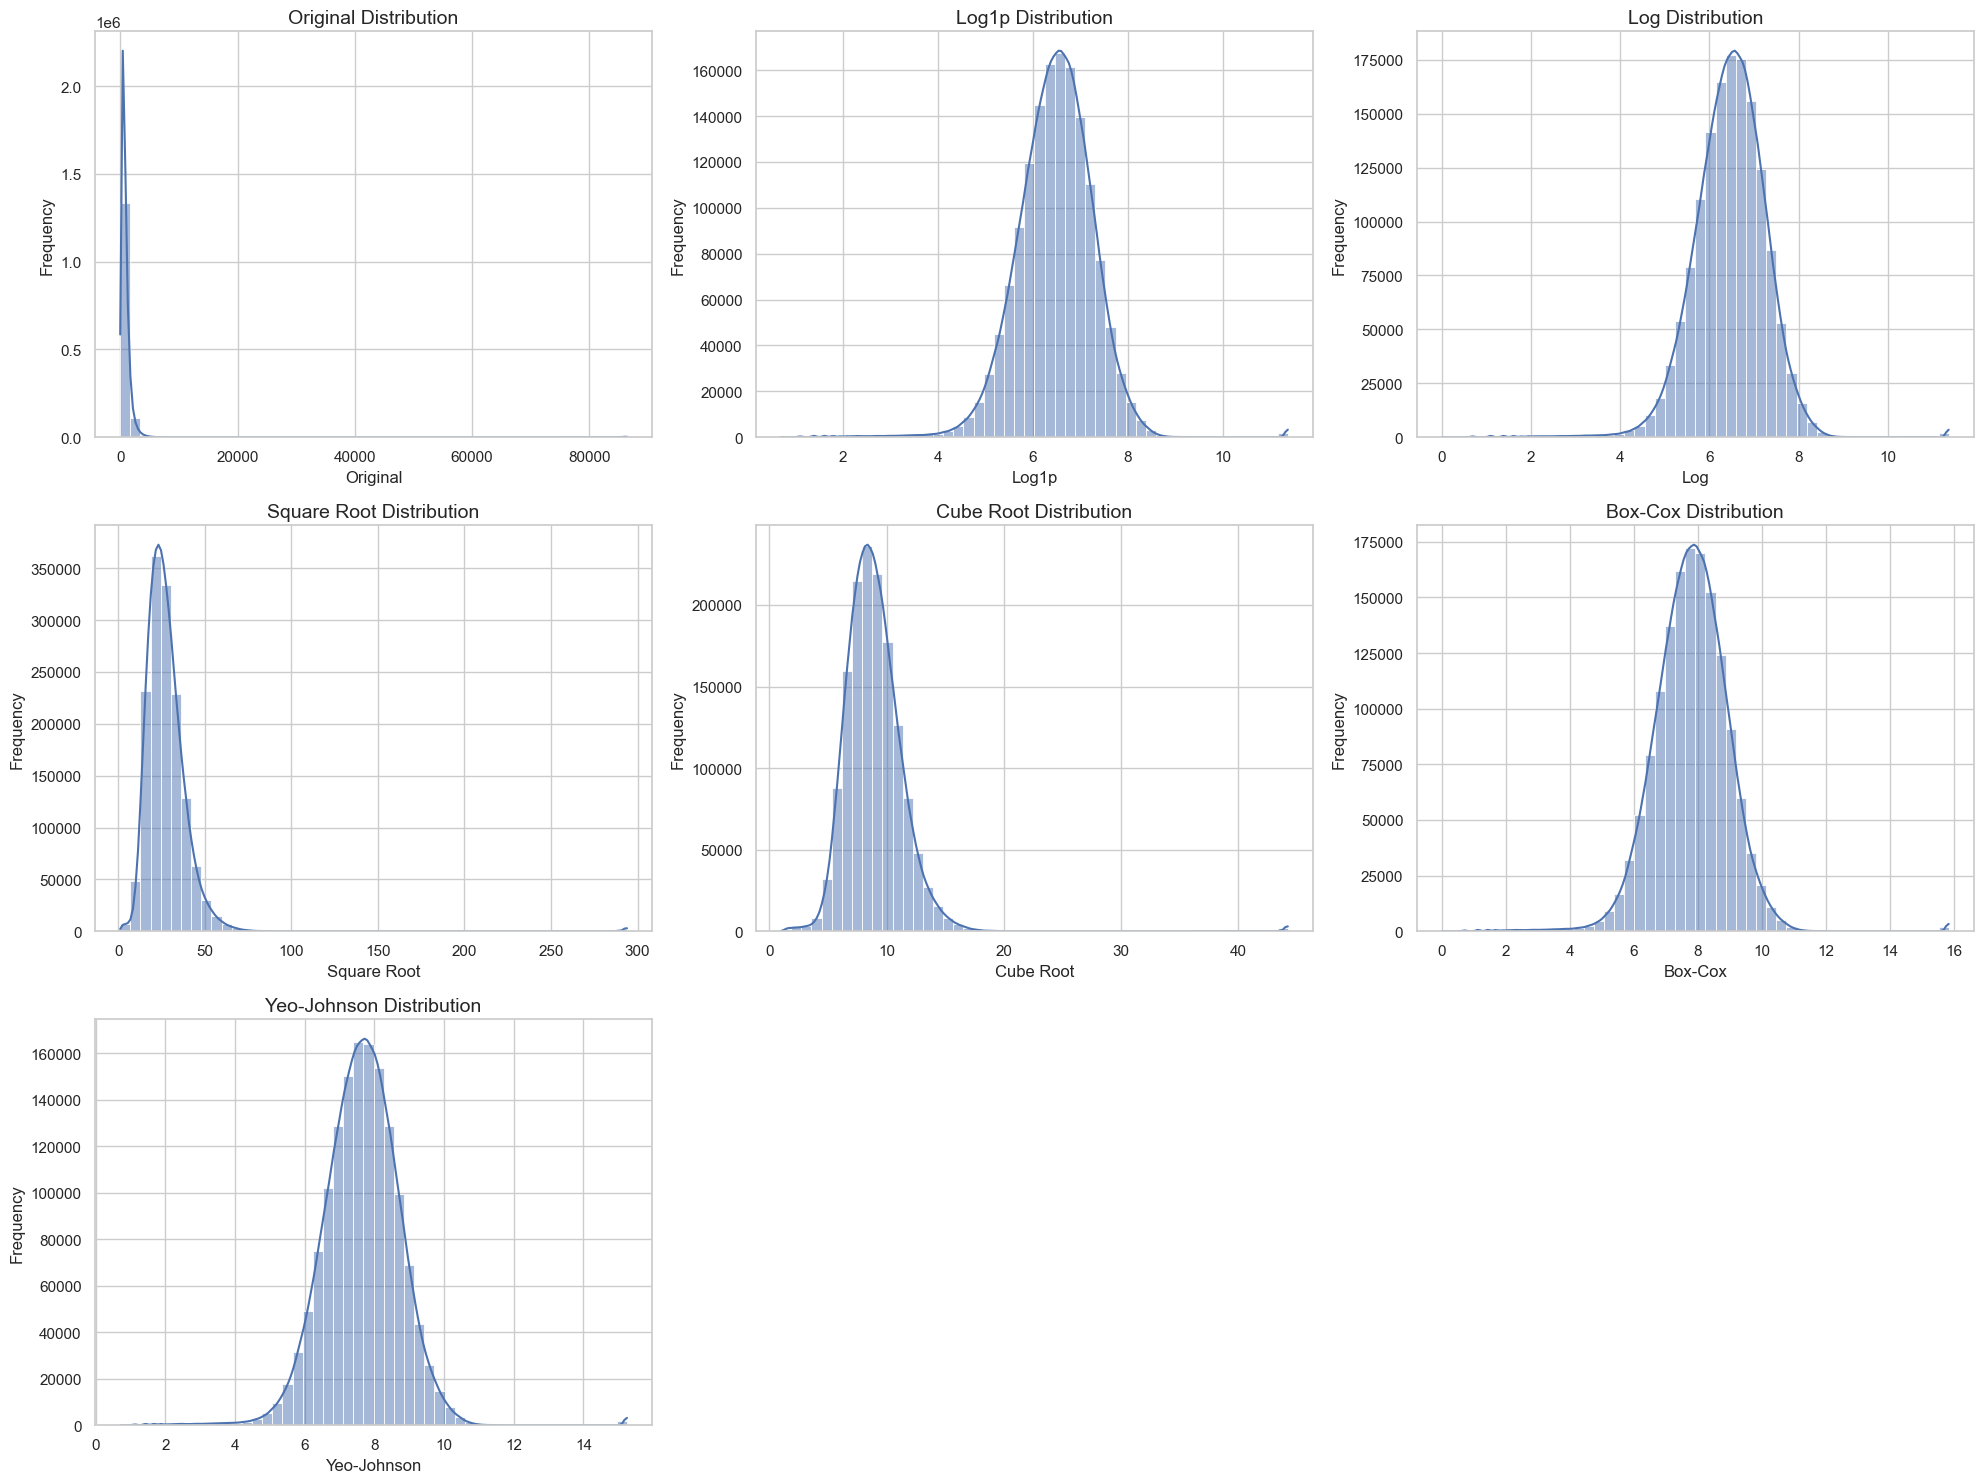

In [52]:
### 3.7.4 📊 Distribution Comparison of All Transformations

n_plots = len(transformations)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, (name, values) in enumerate(transformations.items()):
    sns.histplot(
        values,
        bins=50,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{name} Distribution")
    axes[i].set_xlabel(name)
    axes[i].set_ylabel("Frequency")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

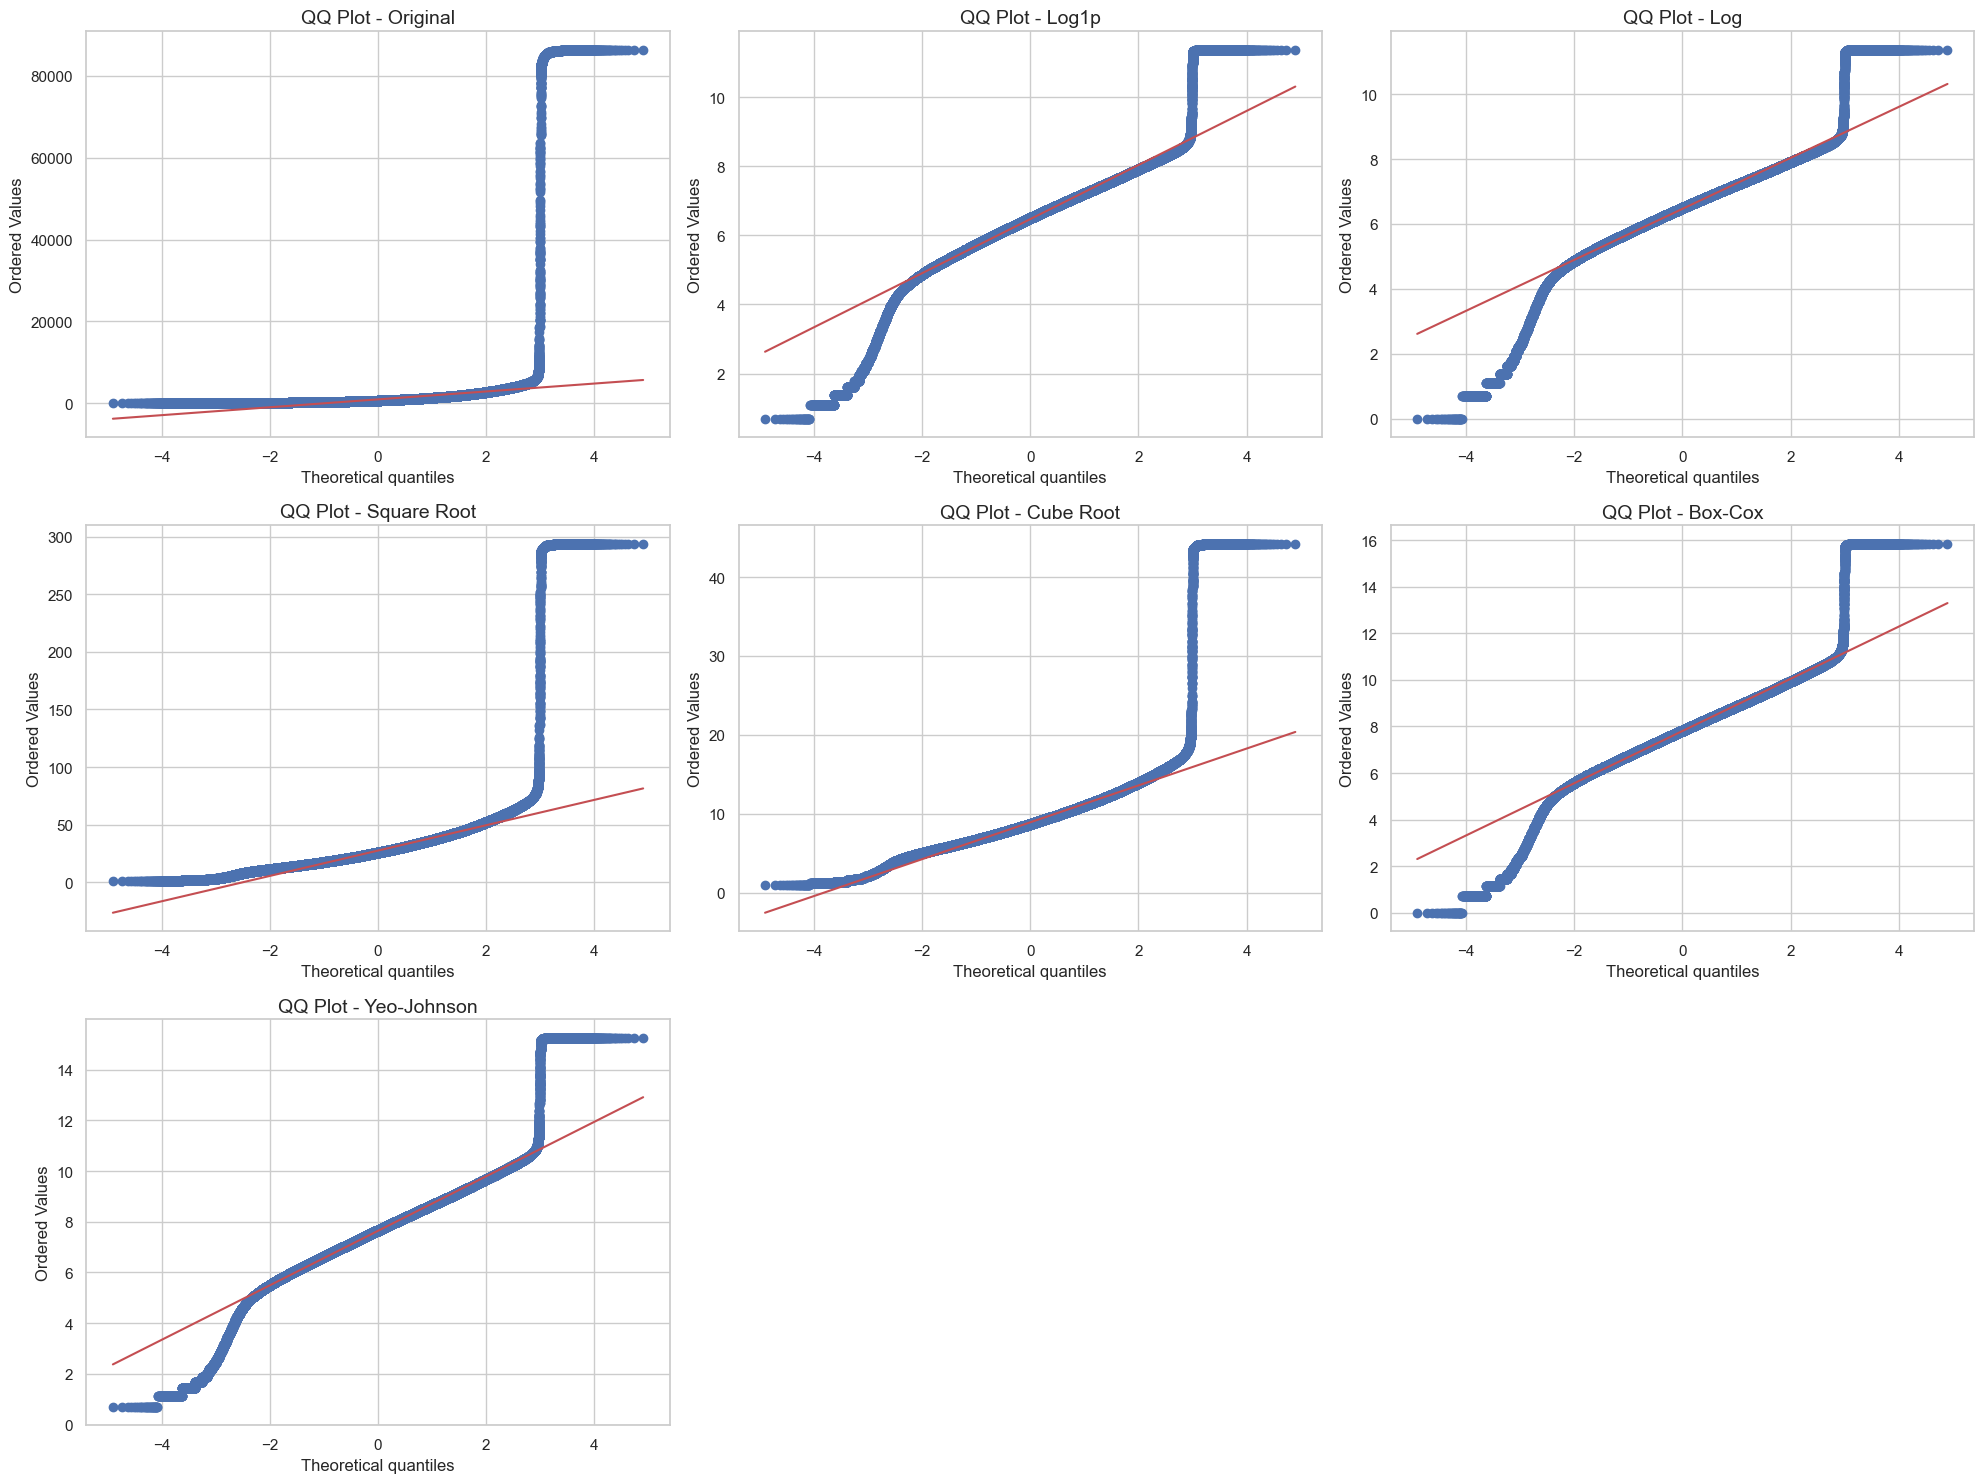

In [53]:
### 3.7.5 📈 QQ Plot Comparison of Transformations

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, (name, values) in enumerate(transformations.items()):
    stats.probplot(values, dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ Plot - {name}")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [54]:
### 3.7.6 🔝 Best Transformation Based on Skewness and Kurtosis

best_transformation = transformation_summary_df.iloc[0]

best_transformation_df = pd.DataFrame({
    "Metric": [
        "Best Transformation",
        "Skewness",
        "Kurtosis",
        "Shape Score"
    ],
    "Value": [
        best_transformation["Transformation"],
        round(best_transformation["Skewness"], 4),
        round(best_transformation["Kurtosis"], 4),
        round(best_transformation["Shape Score"], 4)
    ]
})

best_transformation_df

,Metric,Value
0,Best Transformation,Log1p
1,Skewness,-0.2932
2,Kurtosis,3.8320
3,Shape Score,4.1253


In [55]:
### 3.7.7 📊 Top 5 Transformations by Shape Score

top_transformations_df = transformation_summary_df[
    ["Transformation", "Skewness", "Kurtosis", "Shape Score"]
].head(5)

top_transformations_df.round(4)

,Transformation,Skewness,Kurtosis,Shape Score
0,Log1p,-0.2932,3.8320,4.1253
1,Yeo-Johnson,0.0523,4.1822,4.2345
2,Log,-0.3437,4.1477,4.4914
3,Box-Cox,0.0624,4.4301,4.4925
4,Cube Root,3.7428,46.5253,50.2680


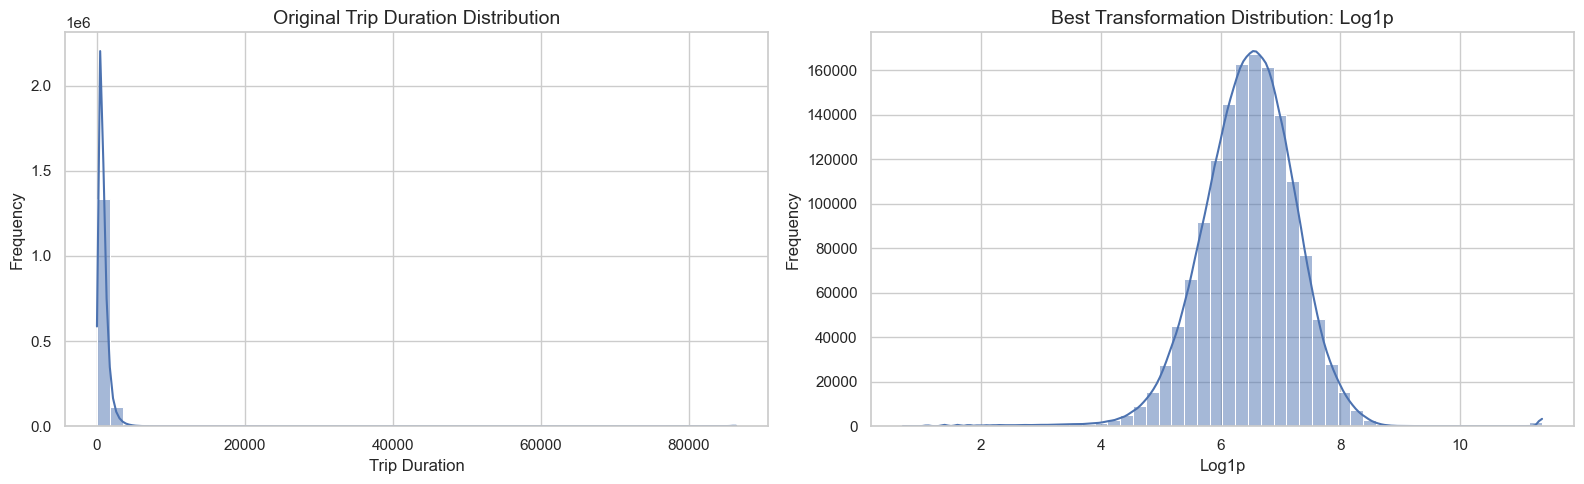

In [56]:
### 3.7.8 📌 Original vs Best Transformation Side-by-Side

best_name = best_transformation["Transformation"]
best_values = transformations[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    target_clean,
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Trip Duration Distribution")
axes[0].set_xlabel("Trip Duration")
axes[0].set_ylabel("Frequency")

sns.histplot(
    best_values,
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title(f"Best Transformation Distribution: {best_name}")
axes[1].set_xlabel(best_name)
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 📝 Summary of Target Transformation Analysis

- Different transformations were tested on `trip_duration`:  
  `Log1p`, `Log`, `Square Root`, `Cube Root`, `Box-Cox`, and `Yeo-Johnson`.

- The original `trip_duration` distribution is highly right-skewed and not normal-like.

- `Square Root` and `Cube Root` transformations improved the distribution slightly, but they still kept noticeable skewness and long-tail behavior.

- `Log1p`, `Log`, `Box-Cox`, and `Yeo-Johnson` made the distribution much more balanced compared to the original target.

- Based on the transformation comparison table, `Log1p` achieved the best overall shape score.

- `Log1p` transformation has:
  - Skewness: **-0.2932**
  - Kurtosis: **3.8320**
  - Shape Score: **4.1253**

- `Yeo-Johnson` and `Box-Cox` also performed well because their skewness values are close to zero.

- However, their kurtosis values are slightly higher than `Log1p`, so their overall shape scores are not better than `Log1p`.

- The QQ plots show that transformed versions fit the normal line much better than the original target.

- Still, the tails are not perfectly normal, which means some extreme duration patterns still exist.

- Overall, `Log1p` is the most practical and stable transformation for this target variable.

- For modeling, we can compare:
  - Raw target: `trip_duration`
  - Transformed target: `log1p(trip_duration)`

- The final target choice should be based on validation performance, not only EDA statistics.

# 4. 🧩 Feature Type Classification

In this section, we will manually classify each column based on its feature type.  
This step helps us decide how each feature should be handled during EDA, preprocessing, and feature engineering.

---

## 📌 Original Dataset Features

| Column Name | Feature Category | Sub-category | Notes |
|---|---|---|---|
| `id` | Identifier | Unique ID | Used only to identify each trip |
| `vendor_id` | Categorical | Nominal | Vendor label, not a true numeric value |
| `pickup_datetime` | Temporal | Datetime | Can be used for time-based feature extraction |
| `dropoff_datetime` | Temporal | Datetime / Leakage Risk | Useful for EDA, but should not be used in final model |
| `passenger_count` | Numeric | Count / Discrete | Number of passengers in the trip |
| `pickup_longitude` | Numeric | Continuous / Geospatial | Pickup location longitude |
| `pickup_latitude` | Numeric | Continuous / Geospatial | Pickup location latitude |
| `dropoff_longitude` | Numeric | Continuous / Geospatial | Dropoff location longitude |
| `dropoff_latitude` | Numeric | Continuous / Geospatial | Dropoff location latitude |
| `store_and_fwd_flag` | Categorical | Binary | Yes/No type flag |
| `trip_duration` | Target | Continuous Numeric | Prediction target |

---

## 🔢 Numeric Features

### 📏 Continuous Numeric Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`

### 👥 Count / Discrete Numeric Features
- `passenger_count`

### 🔢 Ordinal Numeric Features
- No direct ordinal numeric feature found

---

## 🏷️ Categorical Features

### 🧾 Nominal Categorical Features
- `vendor_id`

### 🔘 Binary Categorical Features
- `store_and_fwd_flag`

### 📊 Ordinal Categorical Features
- No direct ordinal categorical feature found

---

## ⏰ Temporal Features

### Original Datetime Features
- `pickup_datetime`
- `dropoff_datetime`

### Time Features Can Be Extracted From `pickup_datetime`
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `pickup_dayofweek`
- `pickup_weekday_name`
- `pickup_is_weekend`
- `pickup_minute`
- `pickup_time_of_day`

### Important Note
- `pickup_datetime` can be used for feature engineering.
- `dropoff_datetime` should be avoided in final modeling because it can create data leakage.

---

## 📍 Geospatial Features

### Original Location Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`

### Possible Extracted Location Features
- `haversine_distance`
- `manhattan_distance`
- `pickup_cluster`
- `dropoff_cluster`
- `pickup_borough`
- `dropoff_borough`

---

## 🆔 Identifier Feature

- `id`

This feature is not useful for model learning because it only identifies each trip.

---

## 🎯 Target Feature

- `trip_duration`

This is the output variable we want to predict.  
It will not be used as an input feature.

---

## ✅ Feature Handling Decision

| Feature Type | Handling Plan |
|---|---|
| Identifier | Drop before modeling |
| Target | Separate as `y` |
| Continuous numeric | Check distribution, outliers, scaling need |
| Count numeric | Check invalid values and distribution |
| Nominal categorical | Encode properly |
| Binary categorical | Convert to 0/1 |
| Temporal | Extract useful time-based features |
| Geospatial | Create distance and location-based features |
| Leakage-risk feature | Avoid in final model |

# 5. 🔢 Numeric Feature Analysis

In this section, we will analyze numeric features from the dataset.  
The analysis will start with continuous numeric features and then move to count/discrete numeric features.

## 5.1 📏 Continuous Numeric Feature Analysis

In this section, we will analyze the continuous numeric features individually.  
Here, we will focus only on univariate analysis, meaning each feature will be analyzed separately without comparing it with the target or other features.

### Continuous Numeric Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`

### 5.1.1 📌 Basic Summary Statistics

In this step, we will check the basic statistical information of continuous numeric features.  
This will help us understand their value range, central tendency, spread, and overall numerical behavior.

#### Checks Included
- Data type
- Total count
- Missing count
- Unique values
- Minimum value
- Maximum value
- Range
- Mean
- Median
- Mode
- Standard deviation
- Variance
- Skewness
- Kurtosis

In [57]:
### 5.1.1 📌 Basic Summary Statistics for Continuous Numeric Features

# Continuous numeric features
continuous_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

# Safety check: keep only available columns
continuous_features = [col for col in continuous_features if col in train.columns]

# Create summary list
continuous_summary = []

for col in continuous_features:
    series = train[col]
    
    mode_value = series.mode()
    mode_value = mode_value.iloc[0] if len(mode_value) > 0 else np.nan
    
    continuous_summary.append({
        "Feature": col,
        "Data Type": series.dtype,
        "Total Count": len(series),
        "Non-Missing Count": series.count(),
        "Missing Count": series.isnull().sum(),
        "Missing (%)": (series.isnull().sum() / len(series)) * 100,
        "Unique Values": series.nunique(),
        "Minimum": series.min(),
        "Maximum": series.max(),
        "Range": series.max() - series.min(),
        "Mean": series.mean(),
        "Median": series.median(),
        "Mode": mode_value,
        "Standard Deviation": series.std(),
        "Variance": series.var(),
        "Skewness": series.skew(),
        "Kurtosis": series.kurtosis()
    })

# Convert to dataframe
continuous_summary_df = pd.DataFrame(continuous_summary)

# Round numeric values
numeric_cols = continuous_summary_df.select_dtypes(include=["int64", "float64"]).columns
continuous_summary_df[numeric_cols] = continuous_summary_df[numeric_cols].round(4)

continuous_summary_df

,Feature,Data Type,Total Count,Non-Missing Count,Missing Count,Missing (%),Unique Values,Minimum,Maximum,Range,Mean,Median,Mode,Standard Deviation,Variance,Skewness,Kurtosis
0,pickup_longitude,float64,1458644,1458644,0,0.0000,23047,-121.9333,-61.3355,60.5978,-73.9735,-73.9817,-73.9822,0.0709,0.0050,-418.1204,288156.5204
1,pickup_latitude,float64,1458644,1458644,0,0.0000,45245,34.3597,51.8811,17.5214,40.7509,40.7541,40.7741,0.0329,0.0011,5.4891,12950.2415
2,dropoff_longitude,float64,1458644,1458644,0,0.0000,33821,-121.9333,-61.3355,60.5978,-73.9734,-73.9798,-73.9823,0.0706,0.0050,-425.3317,292526.0218
3,dropoff_latitude,float64,1458644,1458644,0,0.0000,62519,32.1811,43.9210,11.7399,40.7518,40.7545,40.7743,0.0359,0.0013,-20.6712,4259.5426


In [58]:
### 5.1.1 🎨 Styled Basic Summary Table

continuous_summary_df.style.background_gradient(
    subset=[
        "Missing Count",
        "Missing (%)",
        "Unique Values",
        "Skewness",
        "Kurtosis"
    ],
    cmap="Blues"
)

,Feature,Data Type,Total Count,Non-Missing Count,Missing Count,Missing (%),Unique Values,Minimum,Maximum,Range,Mean,Median,Mode,Standard Deviation,Variance,Skewness,Kurtosis
0,pickup_longitude,float64,1458644,1458644,0,0.000000,23047,-121.933300,-61.335500,60.597800,-73.973500,-73.981700,-73.982200,0.070900,0.005000,-418.120400,288156.520400
1,pickup_latitude,float64,1458644,1458644,0,0.000000,45245,34.359700,51.881100,17.521400,40.750900,40.754100,40.774100,0.032900,0.001100,5.489100,12950.241500
2,dropoff_longitude,float64,1458644,1458644,0,0.000000,33821,-121.933300,-61.335500,60.597800,-73.973400,-73.979800,-73.982300,0.070600,0.005000,-425.331700,292526.021800
3,dropoff_latitude,float64,1458644,1458644,0,0.000000,62519,32.181100,43.921000,11.739900,40.751800,40.754500,40.774300,0.035900,0.001300,-20.671200,4259.542600


In [59]:
continuous_summary_df.to_csv("temporal1.csv")

### 📝 Summary of Continuous Numeric Features — Basic Statistics

- All continuous numeric features have **1,458,644 non-missing values**, so there are **no missing values** in pickup/dropoff latitude and longitude columns.

- All four continuous features are stored as `float64`, which is appropriate for latitude and longitude values.

- `pickup_longitude` and `dropoff_longitude` have very similar average values, around **-73.97**, which is expected for NYC location data.

- `pickup_latitude` and `dropoff_latitude` have average values around **40.75**, which also matches the general NYC latitude range.

- The median values are very close to the mean values for all four coordinate features, meaning most records are concentrated around the NYC area.

- However, the minimum and maximum values show some suspicious coordinate ranges:
  - Longitude ranges from about **-121.93 to -61.34**
  - Latitude ranges from about **32.18 to 51.88**

- These extreme coordinate values are far outside normal NYC boundaries and may indicate GPS errors or invalid location records.

- Skewness and kurtosis values are very high for some coordinate columns, especially longitude features, which suggests the presence of strong extreme values or outliers.

- `dropoff_latitude` has negative skewness, meaning some unusually low latitude values are pulling the distribution downward.

- Overall, the coordinate columns have no missing value problem, but they need **boundary checking and outlier analysis** before using them for distance-based feature engineering.

### 5.1.2 🧹 Data Quality Check for Continuous Numeric Features

In this step, we will check the data quality of continuous numeric features.  
Since these features are latitude and longitude values, we will check missing values, zero values, negative values, duplicate values, infinite values, invalid coordinate values, and extreme lower/upper values.

#### Checks Included
- Missing values  
- Zero values  
- Negative values  
- Duplicate values inside each column  
- Infinite values  
- Invalid coordinate values  
- Extremely small values  
- Extremely large values  

In [60]:
### 5.1.2.1 🧹 Continuous Feature Data Quality Summary

continuous_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

continuous_features = [col for col in continuous_features if col in train.columns]

quality_summary = []

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce")
    total_rows = len(series)
    
    missing_count = series.isnull().sum()
    zero_count = (series == 0).sum()
    negative_count = (series < 0).sum()
    duplicate_count = series.duplicated().sum()
    infinite_count = np.isinf(series).sum()
    
    # Basic global coordinate validity
    if "longitude" in col:
        invalid_coordinate_count = ((series < -180) | (series > 180) | (series == 0) | np.isinf(series)).sum()
        negative_note = "Expected for NYC longitude"
    elif "latitude" in col:
        invalid_coordinate_count = ((series < -90) | (series > 90) | (series == 0) | np.isinf(series)).sum()
        negative_note = "Suspicious for latitude"
    else:
        invalid_coordinate_count = 0
        negative_note = "Check needed"
    
    quality_summary.append({
        "Feature": col,
        "Missing Count": missing_count,
        "Missing (%)": (missing_count / total_rows) * 100,
        "Zero Count": zero_count,
        "Zero (%)": (zero_count / total_rows) * 100,
        "Negative Count": negative_count,
        "Negative (%)": (negative_count / total_rows) * 100,
        "Negative Value Note": negative_note,
        "Duplicate Count": duplicate_count,
        "Duplicate (%)": (duplicate_count / total_rows) * 100,
        "Infinite Count": infinite_count,
        "Infinite (%)": (infinite_count / total_rows) * 100,
        "Basic Invalid Coordinate Count": invalid_coordinate_count,
        "Basic Invalid Coordinate (%)": (invalid_coordinate_count / total_rows) * 100
    })

continuous_quality_df = pd.DataFrame(quality_summary)

numeric_cols = continuous_quality_df.select_dtypes(include=["int64", "float64"]).columns
continuous_quality_df[numeric_cols] = continuous_quality_df[numeric_cols].round(4)

continuous_quality_df

,Feature,Missing Count,Missing (%),Zero Count,Zero (%),Negative Count,Negative (%),Negative Value Note,Duplicate Count,Duplicate (%),Infinite Count,Infinite (%),Basic Invalid Coordinate Count,Basic Invalid Coordinate (%)
0,pickup_longitude,0,0.0000,0,0.0000,1458644,100.0000,Expected for NYC longitude,1435597,98.4200,0,0.0000,0,0.0000
1,pickup_latitude,0,0.0000,0,0.0000,0,0.0000,Suspicious for latitude,1413399,96.8981,0,0.0000,0,0.0000
2,dropoff_longitude,0,0.0000,0,0.0000,1458644,100.0000,Expected for NYC longitude,1424823,97.6813,0,0.0000,0,0.0000
3,dropoff_latitude,0,0.0000,0,0.0000,0,0.0000,Suspicious for latitude,1396125,95.7139,0,0.0000,0,0.0000


In [61]:
### 5.1.2.2 📉 Extremely Small & Extremely Large Value Check

extreme_summary = []

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce")
    
    p01 = series.quantile(0.01)
    p99 = series.quantile(0.99)
    
    extremely_small_count = (series < p01).sum()
    extremely_large_count = (series > p99).sum()
    
    extreme_summary.append({
        "Feature": col,
        "Minimum": series.min(),
        "1st Percentile": p01,
        "99th Percentile": p99,
        "Maximum": series.max(),
        "Extremely Small Count (< 1st Percentile)": extremely_small_count,
        "Extremely Large Count (> 99th Percentile)": extremely_large_count,
        "Extremely Small (%)": (extremely_small_count / len(series)) * 100,
        "Extremely Large (%)": (extremely_large_count / len(series)) * 100
    })

continuous_extreme_df = pd.DataFrame(extreme_summary)

numeric_cols = continuous_extreme_df.select_dtypes(include=["int64", "float64"]).columns
continuous_extreme_df[numeric_cols] = continuous_extreme_df[numeric_cols].round(4)

continuous_extreme_df

,Feature,Minimum,1st Percentile,99th Percentile,Maximum,Extremely Small Count (< 1st Percentile),Extremely Large Count (> 99th Percentile),Extremely Small (%),Extremely Large (%)
0,pickup_longitude,-121.9333,-74.0143,-73.7822,-61.3355,14587,14569,1.0000,0.9988
1,pickup_latitude,34.3597,40.6448,40.8066,51.8811,14560,14586,0.9982,1.0000
2,dropoff_longitude,-121.9333,-74.0153,-73.7905,-61.3355,14565,14571,0.9985,0.9989
3,dropoff_latitude,32.1811,40.6453,40.8368,43.9210,14577,14584,0.9994,0.9998


In [62]:
### 5.1.2.3 🔁 Most Repeated Coordinate Values

top_repeated_values = []

for col in continuous_features:
    value_counts = train[col].value_counts().head(5)
    
    for value, count in value_counts.items():
        top_repeated_values.append({
            "Feature": col,
            "Repeated Value": value,
            "Count": count,
            "Percentage (%)": (count / len(train)) * 100
        })

top_repeated_values_df = pd.DataFrame(top_repeated_values)
top_repeated_values_df["Percentage (%)"] = top_repeated_values_df["Percentage (%)"].round(4)

top_repeated_values_df

,Feature,Repeated Value,Count,Percentage (%)
0,pickup_longitude,-73.9822,633,0.0434
1,pickup_longitude,-73.9821,607,0.0416
2,pickup_longitude,-73.9821,587,0.0402
3,pickup_longitude,-73.9821,585,0.0401
4,pickup_longitude,-73.9822,584,0.0400
5,pickup_latitude,40.7741,414,0.0284
6,pickup_latitude,40.7741,411,0.0282
7,pickup_latitude,40.7741,410,0.0281
8,pickup_latitude,40.7741,392,0.0269
9,pickup_latitude,40.7741,390,0.0267


In [63]:
### 5.1.2.4 ⚠️ View Rows with Basic Invalid Coordinates

invalid_coordinate_mask = pd.Series(False, index=train.index)

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce")
    
    if "longitude" in col:
        invalid_mask = series.isnull() | np.isinf(series) | (series == 0) | (series < -180) | (series > 180)
    elif "latitude" in col:
        invalid_mask = series.isnull() | np.isinf(series) | (series == 0) | (series < -90) | (series > 90)
    else:
        invalid_mask = series.isnull() | np.isinf(series)
    
    invalid_coordinate_mask = invalid_coordinate_mask | invalid_mask

invalid_coordinate_rows = train[invalid_coordinate_mask]

print("Invalid coordinate rows:", invalid_coordinate_rows.shape[0])

invalid_coordinate_rows.head()

Invalid coordinate rows: 0


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration


### 📝 Summary of Continuous Numeric Feature Data Quality Check

- All continuous coordinate features have **0 missing values**, so there is no missing data issue.

- There are **0 zero values** in all pickup and dropoff latitude/longitude columns.

- There are **0 infinite values**, so there is no infinity-related data problem.

- Basic invalid coordinate count is **0** for all coordinate columns.
  - This means all latitude values are within `-90 to 90`.
  - All longitude values are within `-180 to 180`.
  - So, globally invalid coordinates are not present.

- `pickup_longitude` and `dropoff_longitude` have **100% negative values**, which is expected because NYC longitude is negative.

- `pickup_latitude` and `dropoff_latitude` have **0 negative values**, which is also expected because NYC latitude is positive.

- Duplicate coordinate values are very high:
  - `pickup_longitude`: around **98.42%**
  - `pickup_latitude`: around **96.90%**
  - `dropoff_longitude`: around **97.68%**
  - `dropoff_latitude`: around **95.71%**

- High duplicate coordinate values are normal because many taxi trips start or end at common locations such as taxi stands, airports, stations, hotels, offices, and busy pickup/dropoff zones.

- The most repeated coordinate values have very small percentages individually, around **0.03%–0.04%**, so no single coordinate dominates the dataset heavily.

- The 1st and 99th percentile analysis shows that around **1% lower-tail** and **1% upper-tail** values exist for each coordinate feature.

- These extreme values are not automatically invalid, but they may represent trips outside the main NYC area or GPS noise.

- Although basic coordinate validity is clean, the minimum and maximum coordinate ranges still look wide, so NYC-specific boundary checking should be done next.

- Overall, the coordinate data has no missing, zero, infinite, or globally invalid value issue, but further geospatial boundary analysis is needed before final feature engineering.

### 5.1.3 📍 Geospatial Boundary Check

In this step, we will check whether pickup and dropoff latitude/longitude values are within realistic NYC location boundaries.  
This helps us identify GPS errors, far-away coordinates, or suspicious location records.

#### Checks Included
- Longitude = 0
- Positive longitude
- Latitude = 0
- Negative latitude
- Coordinates outside strict NYC boundary
- Coordinates outside wider NYC metro boundary

In [64]:
### 5.1.3.1 📌 Define Reusable NYC Boundary Ranges

# Strict NYC boundary: core NYC area
strict_nyc_bounds = {
    "min_longitude": -74.30,
    "max_longitude": -73.65,
    "min_latitude": 40.45,
    "max_latitude": 40.95
}

# Wider NYC metro boundary: safer range for airports and nearby valid trips
wide_nyc_bounds = {
    "min_longitude": -75.50,
    "max_longitude": -72.80,
    "min_latitude": 40.00,
    "max_latitude": 41.30
}

strict_nyc_bounds, wide_nyc_bounds

({'min_longitude': -74.3,
  'max_longitude': -73.65,
  'min_latitude': 40.45,
  'max_latitude': 40.95},
 {'min_longitude': -75.5,
  'max_longitude': -72.8,
  'min_latitude': 40.0,
  'max_latitude': 41.3})

In [65]:
### 5.1.3.2 🧩 Prepare Reusable Coordinate Metadata

coordinate_metadata = pd.DataFrame({
    "Feature": continuous_features,
    "Coordinate Type": [
        "longitude" if "longitude" in col else "latitude"
        for col in continuous_features
    ],
    "Location Type": [
        "pickup" if "pickup" in col else "dropoff"
        for col in continuous_features
    ]
})

coordinate_metadata

,Feature,Coordinate Type,Location Type
0,pickup_longitude,longitude,pickup
1,pickup_latitude,latitude,pickup
2,dropoff_longitude,longitude,dropoff
3,dropoff_latitude,latitude,dropoff


In [66]:
### 5.1.3.3 📌 Reuse Previous Basic Summary Information

# Reuse previous basic summary dataframe
basic_coordinate_info = continuous_summary_df[
    [
        "Feature",
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Missing Count"
    ]
].copy()

# Reuse previous quality summary dataframe if available
quality_coordinate_info = continuous_quality_df[
    [
        "Feature",
        "Zero Count",
        "Negative Count",
        "Infinite Count",
        "Basic Invalid Coordinate Count"
    ]
].copy()

# Merge previous reports
coordinate_reused_info_df = (
    coordinate_metadata
    .merge(basic_coordinate_info, on="Feature", how="left")
    .merge(quality_coordinate_info, on="Feature", how="left")
)

coordinate_reused_info_df

,Feature,Coordinate Type,Location Type,Minimum,Maximum,Mean,Median,Missing Count,Zero Count,Negative Count,Infinite Count,Basic Invalid Coordinate Count
0,pickup_longitude,longitude,pickup,-121.9333,-61.3355,-73.9735,-73.9817,0,0,1458644,0,0
1,pickup_latitude,latitude,pickup,34.3597,51.8811,40.7509,40.7541,0,0,0,0,0
2,dropoff_longitude,longitude,dropoff,-121.9333,-61.3355,-73.9734,-73.9798,0,0,1458644,0,0
3,dropoff_latitude,latitude,dropoff,32.1811,43.9210,40.7518,40.7545,0,0,0,0,0


In [67]:
### 5.1.3.4 🧭 Feature-Level NYC Boundary Check

boundary_results = []

for _, row in coordinate_metadata.iterrows():
    col = row["Feature"]
    coord_type = row["Coordinate Type"]
    series = train[col]
    total_rows = len(series)

    if coord_type == "longitude":
        strict_outside = (
            (series < strict_nyc_bounds["min_longitude"]) |
            (series > strict_nyc_bounds["max_longitude"])
        )

        wide_outside = (
            (series < wide_nyc_bounds["min_longitude"]) |
            (series > wide_nyc_bounds["max_longitude"])
        )

        wrong_sign = series > 0

    else:
        strict_outside = (
            (series < strict_nyc_bounds["min_latitude"]) |
            (series > strict_nyc_bounds["max_latitude"])
        )

        wide_outside = (
            (series < wide_nyc_bounds["min_latitude"]) |
            (series > wide_nyc_bounds["max_latitude"])
        )

        wrong_sign = series < 0

    boundary_results.append({
        "Feature": col,
        "Wrong Sign Count": wrong_sign.sum(),
        "Wrong Sign (%)": wrong_sign.mean() * 100,
        "Outside Strict NYC Count": strict_outside.sum(),
        "Outside Strict NYC (%)": strict_outside.mean() * 100,
        "Outside Wide NYC Count": wide_outside.sum(),
        "Outside Wide NYC (%)": wide_outside.mean() * 100
    })

coordinate_boundary_check_df = pd.DataFrame(boundary_results)

numeric_cols = coordinate_boundary_check_df.select_dtypes(include=["int64", "float64"]).columns
coordinate_boundary_check_df[numeric_cols] = coordinate_boundary_check_df[numeric_cols].round(4)

coordinate_boundary_check_df

,Feature,Wrong Sign Count,Wrong Sign (%),Outside Strict NYC Count,Outside Strict NYC (%),Outside Wide NYC Count,Outside Wide NYC (%)
0,pickup_longitude,0,0.0000,160,0.0110,25,0.0017
1,pickup_latitude,0,0.0000,143,0.0098,33,0.0023
2,dropoff_longitude,0,0.0000,564,0.0387,36,0.0025
3,dropoff_latitude,0,0.0000,424,0.0291,43,0.0029


In [68]:
### 5.1.3.5 📊 Final Coordinate Boundary Report

coordinate_boundary_report_df = (
    coordinate_reused_info_df
    .merge(coordinate_boundary_check_df, on="Feature", how="left")
)

coordinate_boundary_report_df

,Feature,Coordinate Type,Location Type,Minimum,Maximum,Mean,Median,Missing Count,Zero Count,Negative Count,Infinite Count,Basic Invalid Coordinate Count,Wrong Sign Count,Wrong Sign (%),Outside Strict NYC Count,Outside Strict NYC (%),Outside Wide NYC Count,Outside Wide NYC (%)
0,pickup_longitude,longitude,pickup,-121.9333,-61.3355,-73.9735,-73.9817,0,0,1458644,0,0,0,0.0000,160,0.0110,25,0.0017
1,pickup_latitude,latitude,pickup,34.3597,51.8811,40.7509,40.7541,0,0,0,0,0,0,0.0000,143,0.0098,33,0.0023
2,dropoff_longitude,longitude,dropoff,-121.9333,-61.3355,-73.9734,-73.9798,0,0,1458644,0,0,0,0.0000,564,0.0387,36,0.0025
3,dropoff_latitude,latitude,dropoff,32.1811,43.9210,40.7518,40.7545,0,0,0,0,0,0,0.0000,424,0.0291,43,0.0029


In [69]:
### 5.1.3.6 📍 Row-Level Pickup and Dropoff Boundary Check

pickup_outside_strict = (
    (train["pickup_longitude"] < strict_nyc_bounds["min_longitude"]) |
    (train["pickup_longitude"] > strict_nyc_bounds["max_longitude"]) |
    (train["pickup_latitude"] < strict_nyc_bounds["min_latitude"]) |
    (train["pickup_latitude"] > strict_nyc_bounds["max_latitude"])
)

dropoff_outside_strict = (
    (train["dropoff_longitude"] < strict_nyc_bounds["min_longitude"]) |
    (train["dropoff_longitude"] > strict_nyc_bounds["max_longitude"]) |
    (train["dropoff_latitude"] < strict_nyc_bounds["min_latitude"]) |
    (train["dropoff_latitude"] > strict_nyc_bounds["max_latitude"])
)

pickup_outside_wide = (
    (train["pickup_longitude"] < wide_nyc_bounds["min_longitude"]) |
    (train["pickup_longitude"] > wide_nyc_bounds["max_longitude"]) |
    (train["pickup_latitude"] < wide_nyc_bounds["min_latitude"]) |
    (train["pickup_latitude"] > wide_nyc_bounds["max_latitude"])
)

dropoff_outside_wide = (
    (train["dropoff_longitude"] < wide_nyc_bounds["min_longitude"]) |
    (train["dropoff_longitude"] > wide_nyc_bounds["max_longitude"]) |
    (train["dropoff_latitude"] < wide_nyc_bounds["min_latitude"]) |
    (train["dropoff_latitude"] > wide_nyc_bounds["max_latitude"])
)

row_boundary_df = pd.DataFrame({
    "Check": [
        "Pickup Outside Strict NYC Boundary",
        "Dropoff Outside Strict NYC Boundary",
        "Either Pickup or Dropoff Outside Strict NYC Boundary",
        "Pickup Outside Wide NYC Boundary",
        "Dropoff Outside Wide NYC Boundary",
        "Either Pickup or Dropoff Outside Wide NYC Boundary"
    ],
    "Count": [
        pickup_outside_strict.sum(),
        dropoff_outside_strict.sum(),
        (pickup_outside_strict | dropoff_outside_strict).sum(),
        pickup_outside_wide.sum(),
        dropoff_outside_wide.sum(),
        (pickup_outside_wide | dropoff_outside_wide).sum()
    ],
    "Percentage (%)": [
        pickup_outside_strict.mean() * 100,
        dropoff_outside_strict.mean() * 100,
        (pickup_outside_strict | dropoff_outside_strict).mean() * 100,
        pickup_outside_wide.mean() * 100,
        dropoff_outside_wide.mean() * 100,
        (pickup_outside_wide | dropoff_outside_wide).mean() * 100
    ]
})

row_boundary_df["Percentage (%)"] = row_boundary_df["Percentage (%)"].round(4)

row_boundary_df

,Check,Count,Percentage (%)
0,Pickup Outside Strict NYC Boundary,247,0.0169
1,Dropoff Outside Strict NYC Boundary,879,0.0603
2,Either Pickup or Dropoff Outside Strict NYC Bo...,892,0.0612
3,Pickup Outside Wide NYC Boundary,36,0.0025
4,Dropoff Outside Wide NYC Boundary,51,0.0035
5,Either Pickup or Dropoff Outside Wide NYC Boun...,55,0.0038


In [70]:
### 5.1.3.7 🔎 View Rows Outside Wide NYC Boundary

display_cols = [
    "id",
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"
]

display_cols = [col for col in display_cols if col in train.columns]

outside_wide_rows = train[
    pickup_outside_wide | dropoff_outside_wide
][display_cols]

print("Rows outside wide NYC boundary:", outside_wide_rows.shape[0])

outside_wide_rows.head(10)

Rows outside wide NYC boundary: 55


,id,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
14502,id1092161,2016-04-15 22:35:08,-73.7818,40.6447,-72.7114,41.3115,7153
73414,id0098463,2016-03-30 19:32:16,-74.1267,41.3192,-73.9351,40.8297,3190
112247,id0479538,2016-01-02 20:50:36,-73.7899,40.6434,-73.6842,41.3347,5278
114376,id1311087,2016-02-29 12:16:29,-75.4559,39.8039,-73.7960,40.7077,23440
165903,id1889528,2016-03-18 15:53:58,-74.1951,43.4869,-74.1951,43.4869,674
184925,id2306955,2016-05-07 18:58:53,-72.8097,51.8811,-73.9872,40.7506,792
193116,id2769862,2016-02-06 15:43:15,-77.8960,37.7778,-77.8960,37.7778,417
233451,id1703300,2016-04-26 16:46:00,-77.0394,38.8988,-77.0394,38.8988,60
235449,id2298947,2016-04-14 15:53:00,-77.0394,38.8988,-77.0394,38.8988,60
275644,id0978162,2016-02-24 16:20:59,-75.3543,34.7122,-73.8349,32.1811,875


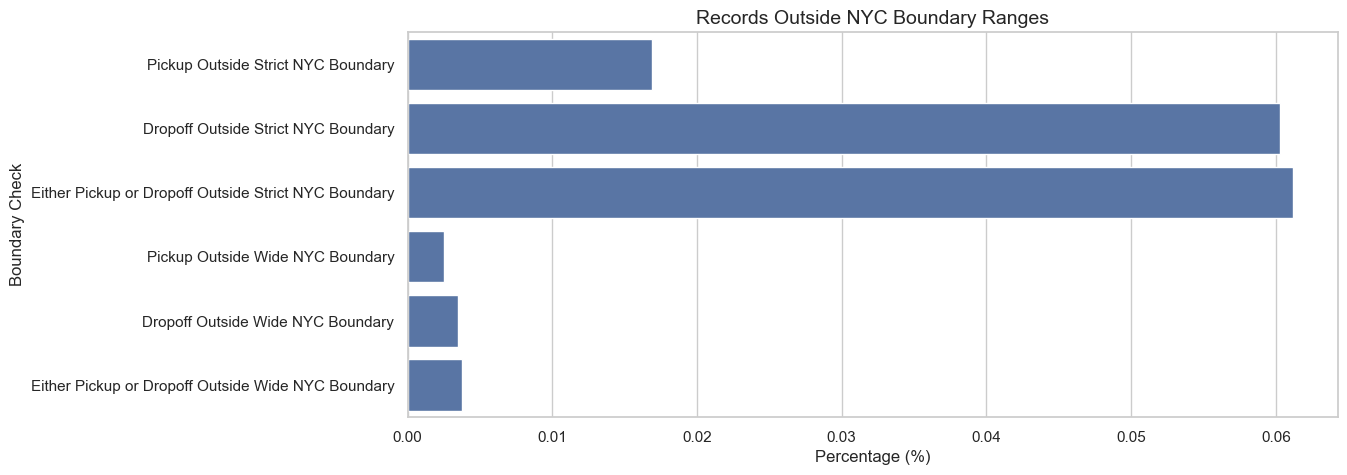

In [71]:
### 5.1.3.8 📊 Boundary Check Bar Chart

plt.figure(figsize=(12, 5))

sns.barplot(
    data=row_boundary_df,
    x="Percentage (%)",
    y="Check"
)

plt.title("Records Outside NYC Boundary Ranges")
plt.xlabel("Percentage (%)")
plt.ylabel("Boundary Check")
plt.show()

### 📝 Summary of Geospatial Boundary Check

- There are **no wrong-sign coordinate values** in any latitude or longitude feature.
- This means longitude values are correctly negative and latitude values are correctly positive for NYC.

- Some records are outside the **strict NYC boundary**, but the percentage is very small:
  - Pickup outside strict NYC boundary: **247 records**, around **0.0169%**
  - Dropoff outside strict NYC boundary: **879 records**, around **0.0603%**
  - Either pickup or dropoff outside strict boundary: **892 records**, around **0.0612%**

- Dropoff locations have more strict-boundary cases than pickup locations.
- This is reasonable because taxis may start inside NYC but drop passengers outside the strict NYC area.

- Very few records are outside the **wide NYC boundary**:
  - Pickup outside wide NYC boundary: **36 records**, around **0.0025%**
  - Dropoff outside wide NYC boundary: **51 records**, around **0.0035%**
  - Either pickup or dropoff outside wide boundary: **55 records**, around **0.0038%**

- Since the wide-boundary outside percentage is extremely low, these records are more suspicious and should be investigated carefully.

- Strict-boundary outside records should not be removed directly because some valid trips may go to airports, nearby cities, or outer NYC areas.

- For final cleaning, the safer decision is to focus on records outside the **wide NYC boundary**, not all strict-boundary records.

### 5.1.4 📊 Continuous Feature Distribution Analysis

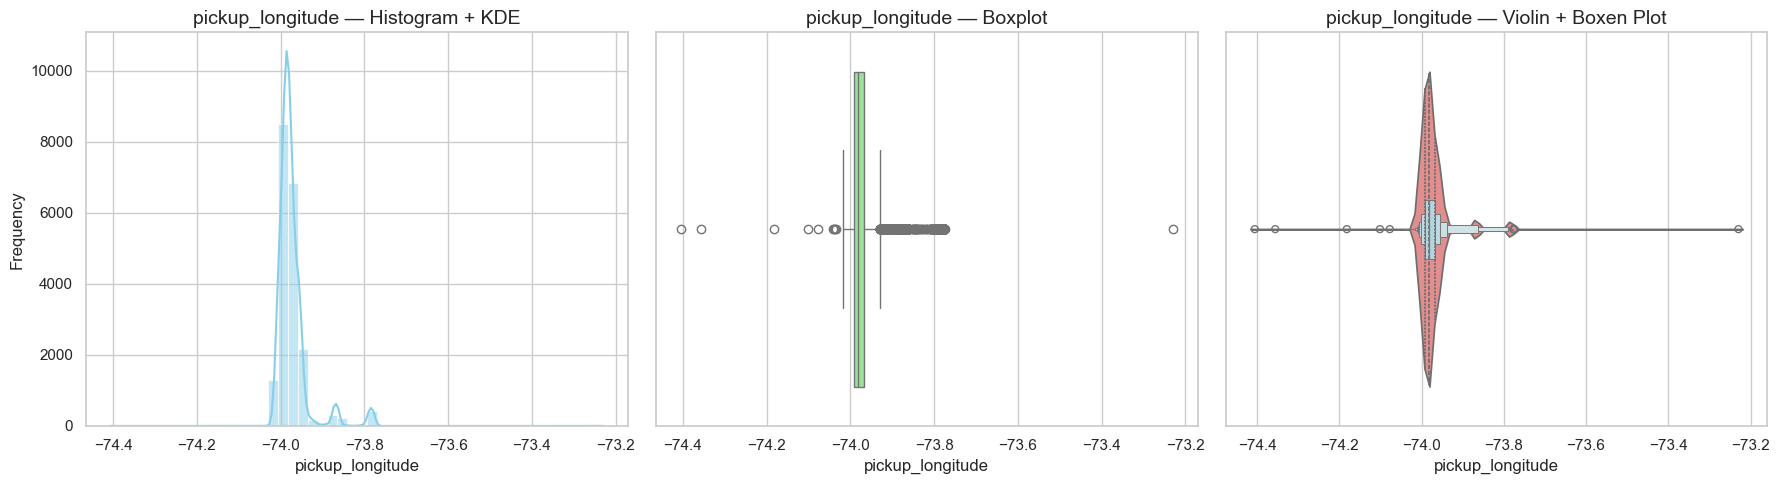

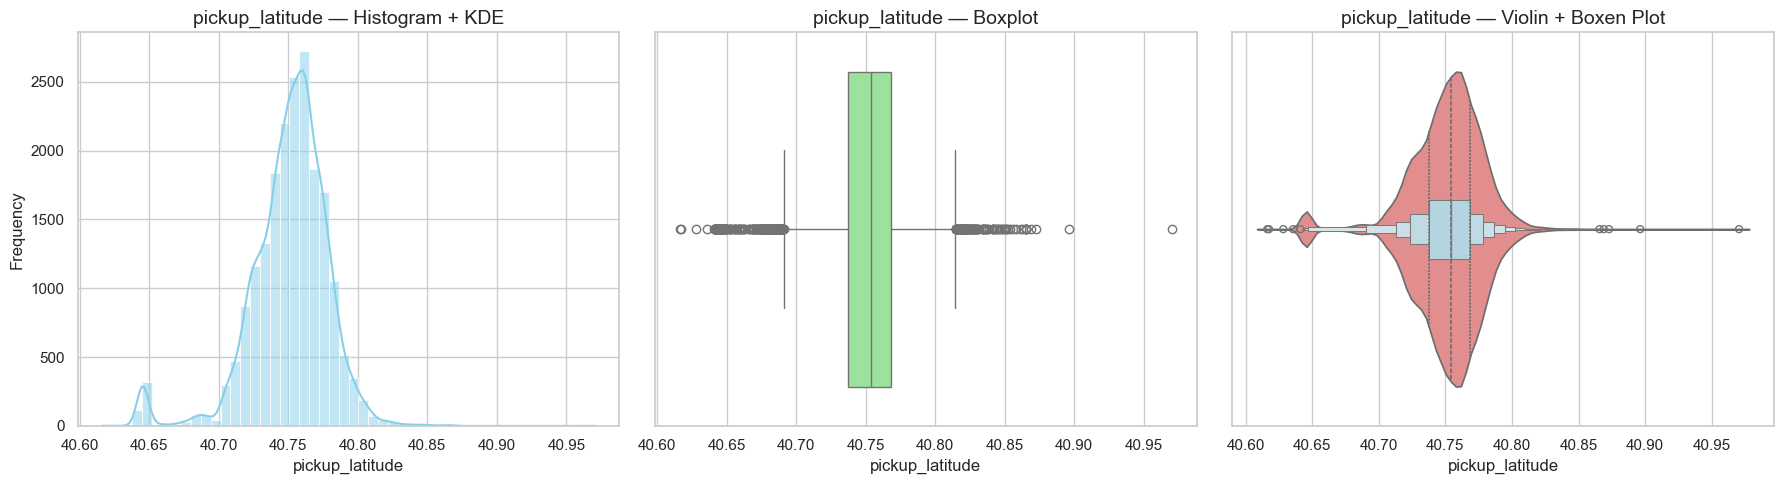

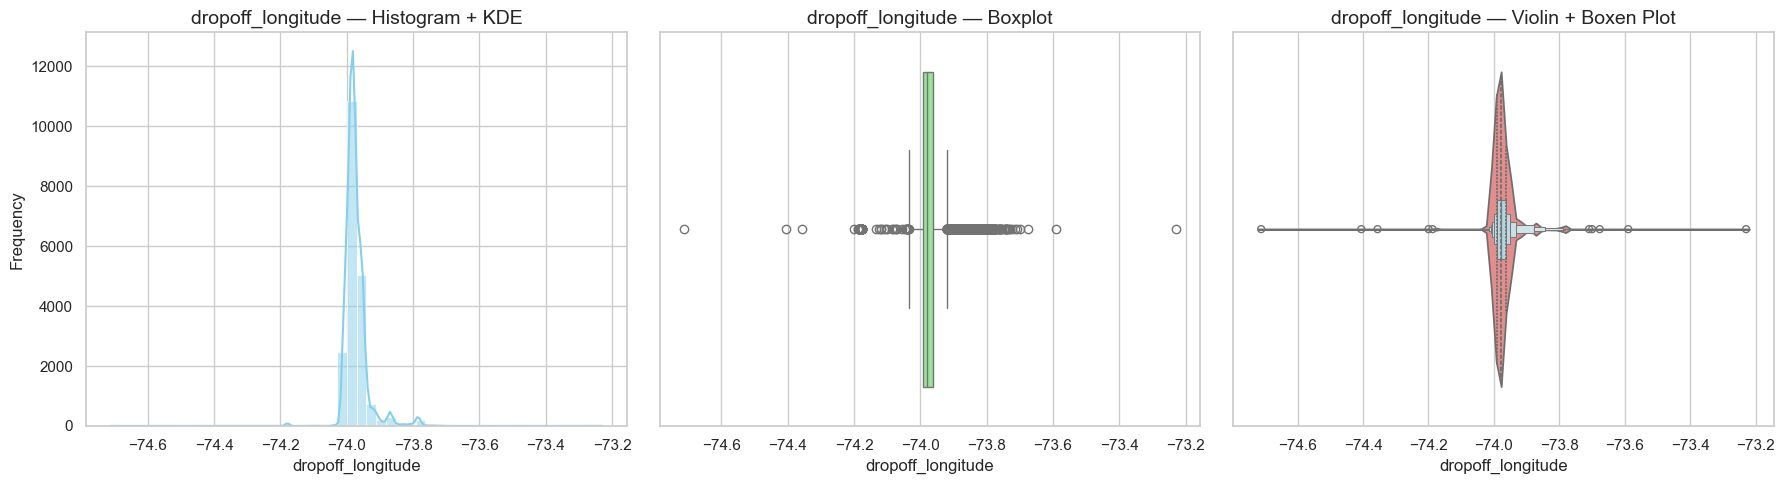

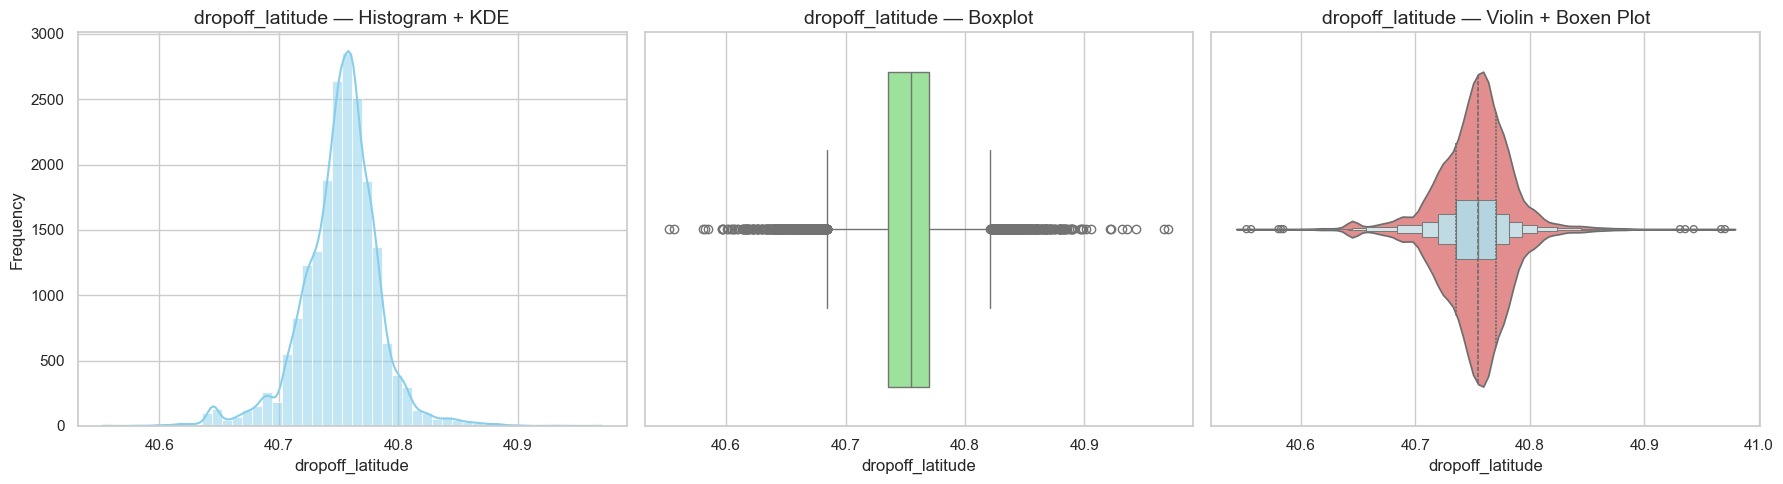

In [72]:


continuous_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

# Sample data for plotting if dataset is large
sample_size = min(20000, len(train))
train_sample = train.sample(sample_size, random_state=42)

for col in continuous_features:
    series = train_sample[col]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogram + KDE
    sns.histplot(series, bins=50, kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"{col} — Histogram + KDE")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    
    # Boxplot + jitter
    sns.boxplot(x=series, ax=axes[1], color="lightgreen")
    axes[1].set_title(f"{col} — Boxplot")
    
    # Violin + Boxen plot combined
    sns.violinplot(x=series, ax=axes[2], color="lightcoral", inner="quartile")
    sns.boxenplot(x=series, ax=axes[2], color="lightblue", width=0.15)
    axes[2].set_title(f"{col} — Violin + Boxen Plot")
    
    plt.tight_layout()
    plt.show()

### 📝 Continuous Feature Distribution Summary

- **pickup_longitude**
  - Distribution is strongly **peaked around -74** with most trips concentrated in central NYC.
  - Long tails on both sides, but majority of values are clustered.
  - Boxplot shows some mild outliers beyond the main cluster.
  - Violin + boxen plot confirms high concentration near median, with outliers visible at extremes.

- **pickup_latitude**
  - Distribution is strongly **peaked around 40.75** (midtown NYC area).
  - Some lower and upper tail values exist, indicating trips at northern/southern edges.
  - Boxplot and violin plot confirm central clustering and small number of extreme points.

- **dropoff_longitude**
  - Similar to pickup_longitude, peak at ~-74, slightly wider tail.
  - More extreme outliers than pickup_longitude, likely trips ending outside strict NYC boundary.
  - Violin + boxen shows dense middle distribution with long thin tails.

- **dropoff_latitude**
  - Similar to pickup_latitude, peak at ~40.75.
  - Some extreme high/low values in tail, more than pickup_latitude.
  - Boxplot and violin plot highlight small proportion of outlier trips.

**General Observations:**
- All coordinate features have **single peak** (unimodal) distributions.
- Values are **highly concentrated** in central NYC area.
- Long tails indicate a small number of trips with coordinates outside dense NYC core.
- No bimodal or multi-peak patterns detected.
- Distribution shapes are roughly symmetric for latitude, slightly skewed for longitude tails.

### 5.1.5 📐 Skewness & Kurtosis Check

In [73]:
import pandas as pd
from scipy.stats import skew, kurtosis

# Continuous numeric features
continuous_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

skew_kurt_summary = []

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce")
    
    skew_val = skew(series)
    kurt_val = kurtosis(series)
    
    # Determine approximate shape
    if abs(skew_val) < 0.5:
        skew_shape = "Approximately symmetric"
    elif skew_val > 0:
        skew_shape = "Positive skew"
    else:
        skew_shape = "Negative skew"
    
    # Determine tail behavior
    if kurt_val > 3:
        tail_behavior = "Heavy tail / leptokurtic"
    elif kurt_val < 3:
        tail_behavior = "Light tail / platykurtic"
    else:
        tail_behavior = "Normal-like"
    
    skew_kurt_summary.append({
        "Feature": col,
        "Skewness": round(skew_val, 4),
        "Skew Type": skew_shape,
        "Kurtosis": round(kurt_val, 4),
        "Tail Behavior": tail_behavior,
        "Extreme Value Indication": "Yes" if abs(skew_val) > 1 or abs(kurt_val) > 5 else "No"
    })

# Convert to dataframe
skew_kurt_df = pd.DataFrame(skew_kurt_summary)
skew_kurt_df

,Feature,Skewness,Skew Type,Kurtosis,Tail Behavior,Extreme Value Indication
0,pickup_longitude,-418.1200,Negative skew,288155.5326,Heavy tail / leptokurtic,Yes
1,pickup_latitude,5.4891,Positive skew,12950.1971,Heavy tail / leptokurtic,Yes
2,dropoff_longitude,-425.3313,Negative skew,292525.0190,Heavy tail / leptokurtic,Yes
3,dropoff_latitude,-20.6712,Negative skew,4259.5279,Heavy tail / leptokurtic,Yes


### 📝 Skewness & Kurtosis Summary — Continuous Numeric Features

- **pickup_longitude**
  - Skewness: **-418.12** → extreme **negative skew**
  - Kurtosis: **288,155.53** → extremely heavy tails / leptokurtic
  - Extreme value indication: **Yes**
  - Interpretation: Most pickup longitudes are tightly clustered in central NYC, but some extreme longitude outliers create huge skew and heavy tail.

- **pickup_latitude**
  - Skewness: **5.4891** → **positive skew**
  - Kurtosis: **12,950.20** → very heavy tail
  - Extreme value indication: **Yes**
  - Interpretation: Majority of pickup latitudes around midtown, but northern/southern extremes stretch the tail.

- **dropoff_longitude**
  - Skewness: **-425.33** → extreme **negative skew**
  - Kurtosis: **292,525.02** → extremely heavy tail
  - Extreme value indication: **Yes**
  - Interpretation: Most dropoff longitudes in central NYC, with extreme outliers pulling distribution far left.

- **dropoff_latitude**
  - Skewness: **-20.67** → strong **negative skew**
  - Kurtosis: **4,259.53** → heavy tail
  - Extreme value indication: **Yes**
  - Interpretation: Dropoff latitudes mostly around NYC center, some trips with extremely low latitude cause skew and heavy tail.

**General Observations**
- All coordinate features show **extreme skewness and very high kurtosis**, caused by:
  - A dense cluster of trips in central NYC.
  - A small number of extreme GPS coordinates far from the cluster.
- Violin and boxplots previously confirmed **long thin tails**, matching these statistics.
- Extreme values are mostly outliers, but the majority of data is tightly clustered around NYC coordinates.
- These features should be **cleaned for extreme outliers or bounded to realistic NYC ranges** before using for distance/cluster-based feature engineering.

### 5.1.6 📍 Percentile / Quantile Analysis

In this section, we will analyze the percentile distribution of continuous numeric coordinate features.

Percentile analysis helps us understand:
- Normal value range
- Lower-tail and upper-tail behavior
- Extreme coordinate values
- How tightly values are concentrated around the median
- Whether extreme values are isolated or part of a gradual tail

Since these features are geospatial coordinates, percentile analysis is more reliable than only using minimum and maximum values.  
Minimum and maximum values can be affected by a very small number of extreme GPS points.

#### Percentiles Included
- 0.1%
- 0.5%
- 1%
- 5%
- 10%
- 25%
- 50%
- 75%
- 90%
- 95%
- 99%
- 99.5%
- 99.9%

In [74]:
### 5.1.6.1 📌 Define Percentile Grid

continuous_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

percentile_grid = {
    "P0.1": 0.001,
    "P0.5": 0.005,
    "P1": 0.01,
    "P5": 0.05,
    "P10": 0.10,
    "P25": 0.25,
    "P50": 0.50,
    "P75": 0.75,
    "P90": 0.90,
    "P95": 0.95,
    "P99": 0.99,
    "P99.5": 0.995,
    "P99.9": 0.999
}

percentile_grid

{'P0.1': 0.001,
 'P0.5': 0.005,
 'P1': 0.01,
 'P5': 0.05,
 'P10': 0.1,
 'P25': 0.25,
 'P50': 0.5,
 'P75': 0.75,
 'P90': 0.9,
 'P95': 0.95,
 'P99': 0.99,
 'P99.5': 0.995,
 'P99.9': 0.999}

In [75]:
### 5.1.6.2 📊 Percentile Summary Table

percentile_summary = []

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce").dropna()
    
    feature_percentiles = {
        "Feature": col,
        "Minimum": series.min(),
        "Maximum": series.max()
    }
    
    for label, q in percentile_grid.items():
        feature_percentiles[label] = series.quantile(q)
    
    percentile_summary.append(feature_percentiles)

continuous_percentile_df = pd.DataFrame(percentile_summary)

numeric_cols = continuous_percentile_df.select_dtypes(include=["int64", "float64"]).columns
continuous_percentile_df[numeric_cols] = continuous_percentile_df[numeric_cols].round(6)

continuous_percentile_df

,Feature,Minimum,Maximum,P0.1,P0.5,P1,P5,P10,P25,P50,P75,P90,P95,P99,P99.5,P99.9
0,pickup_longitude,-121.9333,-61.3355,-74.0172,-74.0158,-74.0143,-74.0069,-74.0027,-73.9919,-73.9817,-73.9673,-73.9519,-73.8916,-73.7822,-73.7809,-73.7767
1,pickup_latitude,34.3597,51.8811,40.6415,40.6444,40.6448,40.7081,40.7202,40.7373,40.7541,40.7684,40.7805,40.7884,40.8066,40.8154,40.8425
2,dropoff_longitude,-121.9333,-61.3355,-74.1776,-74.0172,-74.0153,-74.0075,-74.0029,-73.9913,-73.9798,-73.9630,-73.9472,-73.9202,-73.7905,-73.7829,-73.7398
3,dropoff_latitude,32.1811,43.9210,40.6042,40.6419,40.6453,40.6999,40.7154,40.7359,40.7545,40.7698,40.7849,40.7975,40.8368,40.8542,40.8896


In [76]:
### 5.1.6.3 📏 Quantile Gap and Tail Spread Analysis

quantile_gap_summary = []

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce").dropna()
    
    p001 = series.quantile(0.001)
    p01 = series.quantile(0.01)
    p05 = series.quantile(0.05)
    p25 = series.quantile(0.25)
    p50 = series.quantile(0.50)
    p75 = series.quantile(0.75)
    p95 = series.quantile(0.95)
    p99 = series.quantile(0.99)
    p999 = series.quantile(0.999)
    
    iqr = p75 - p25
    central_90_range = p95 - p05
    central_98_range = p99 - p01
    extreme_998_range = p999 - p001
    
    lower_tail_gap = p01 - p001
    upper_tail_gap = p999 - p99
    
    quantile_gap_summary.append({
        "Feature": col,
        "P0.1": p001,
        "P1": p01,
        "P5": p05,
        "P25": p25,
        "Median": p50,
        "P75": p75,
        "P95": p95,
        "P99": p99,
        "P99.9": p999,
        "IQR (P75 - P25)": iqr,
        "Central 90% Range (P95 - P5)": central_90_range,
        "Central 98% Range (P99 - P1)": central_98_range,
        "Extreme 99.8% Range (P99.9 - P0.1)": extreme_998_range,
        "Lower Tail Gap (P1 - P0.1)": lower_tail_gap,
        "Upper Tail Gap (P99.9 - P99)": upper_tail_gap,
        "Extreme-to-IQR Ratio": extreme_998_range / iqr if iqr != 0 else np.nan
    })

quantile_gap_df = pd.DataFrame(quantile_gap_summary)

numeric_cols = quantile_gap_df.select_dtypes(include=["int64", "float64"]).columns
quantile_gap_df[numeric_cols] = quantile_gap_df[numeric_cols].round(6)

quantile_gap_df

,Feature,P0.1,P1,P5,P25,Median,P75,P95,P99,P99.9,IQR (P75 - P25),Central 90% Range (P95 - P5),Central 98% Range (P99 - P1),Extreme 99.8% Range (P99.9 - P0.1),Lower Tail Gap (P1 - P0.1),Upper Tail Gap (P99.9 - P99),Extreme-to-IQR Ratio
0,pickup_longitude,-74.0172,-74.0143,-74.0069,-73.9919,-73.9817,-73.9673,-73.8916,-73.7822,-73.7767,0.0245,0.1153,0.2321,0.2405,0.0029,0.0055,9.8032
1,pickup_latitude,40.6415,40.6448,40.7081,40.7373,40.7541,40.7684,40.7884,40.8066,40.8425,0.0310,0.0802,0.1618,0.2010,0.0033,0.0359,6.4803
2,dropoff_longitude,-74.1776,-74.0153,-74.0075,-73.9913,-73.9798,-73.9630,-73.9202,-73.7905,-73.7398,0.0283,0.0873,0.2248,0.4379,0.1623,0.0507,15.4650
3,dropoff_latitude,40.6042,40.6453,40.6999,40.7359,40.7545,40.7698,40.7975,40.8368,40.8896,0.0339,0.0976,0.1915,0.2853,0.0410,0.0528,8.4104


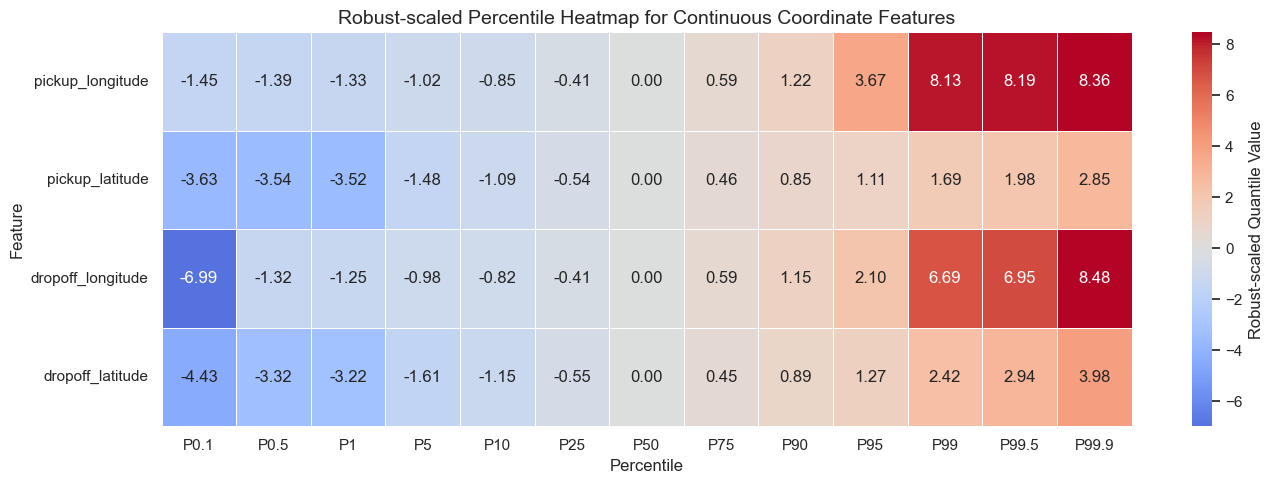

In [77]:
### 5.1.6.4 🔥 Robust-scaled Quantile Heatmap

quantile_matrix = continuous_percentile_df.set_index("Feature")[list(percentile_grid.keys())].copy()

robust_scaled_quantiles = quantile_matrix.copy()

for feature in robust_scaled_quantiles.index:
    median = quantile_matrix.loc[feature, "P50"]
    iqr = quantile_matrix.loc[feature, "P75"] - quantile_matrix.loc[feature, "P25"]
    
    if iqr != 0:
        robust_scaled_quantiles.loc[feature] = (quantile_matrix.loc[feature] - median) / iqr
    else:
        robust_scaled_quantiles.loc[feature] = np.nan

plt.figure(figsize=(14, 5))

sns.heatmap(
    robust_scaled_quantiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Robust-scaled Quantile Value"}
)

plt.title("Robust-scaled Percentile Heatmap for Continuous Coordinate Features")
plt.xlabel("Percentile")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

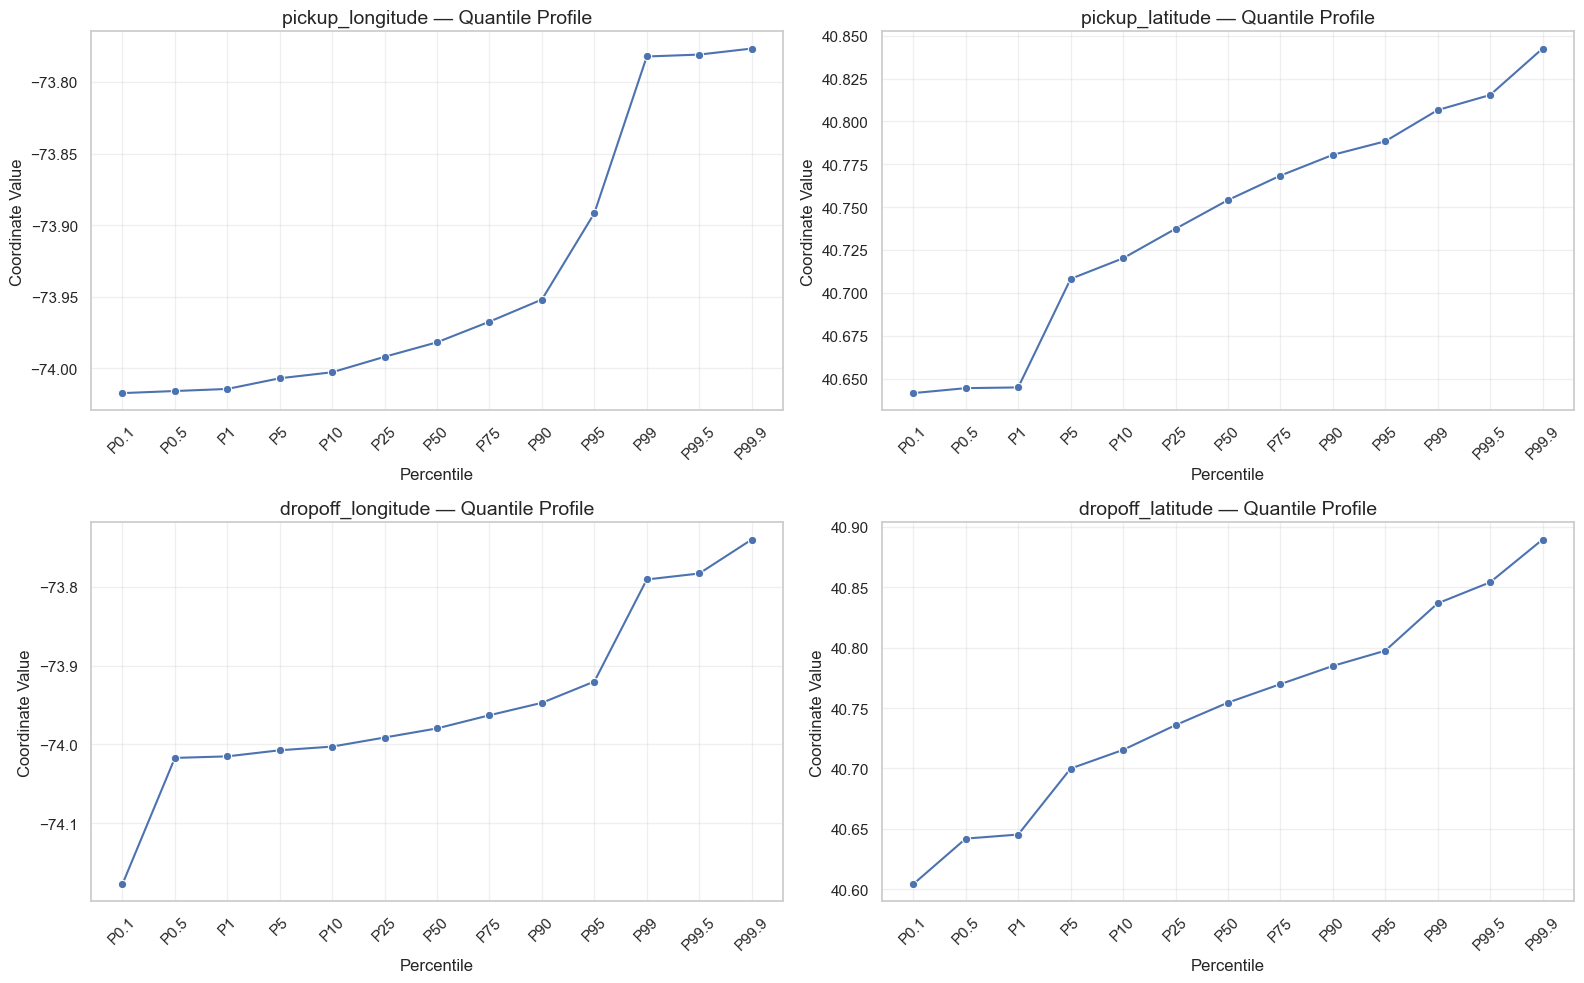

In [78]:
### 5.1.6.5 📈 Quantile Profile Plot

quantile_long_df = continuous_percentile_df.melt(
    id_vars=["Feature", "Minimum", "Maximum"],
    value_vars=list(percentile_grid.keys()),
    var_name="Percentile",
    value_name="Coordinate Value"
)

percentile_order = list(percentile_grid.keys())
quantile_long_df["Percentile"] = pd.Categorical(
    quantile_long_df["Percentile"],
    categories=percentile_order,
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    plot_data = quantile_long_df[quantile_long_df["Feature"] == col]
    
    sns.lineplot(
        data=plot_data,
        x="Percentile",
        y="Coordinate Value",
        marker="o",
        ax=ax
    )
    
    ax.set_title(f"{col} — Quantile Profile")
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Coordinate Value")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

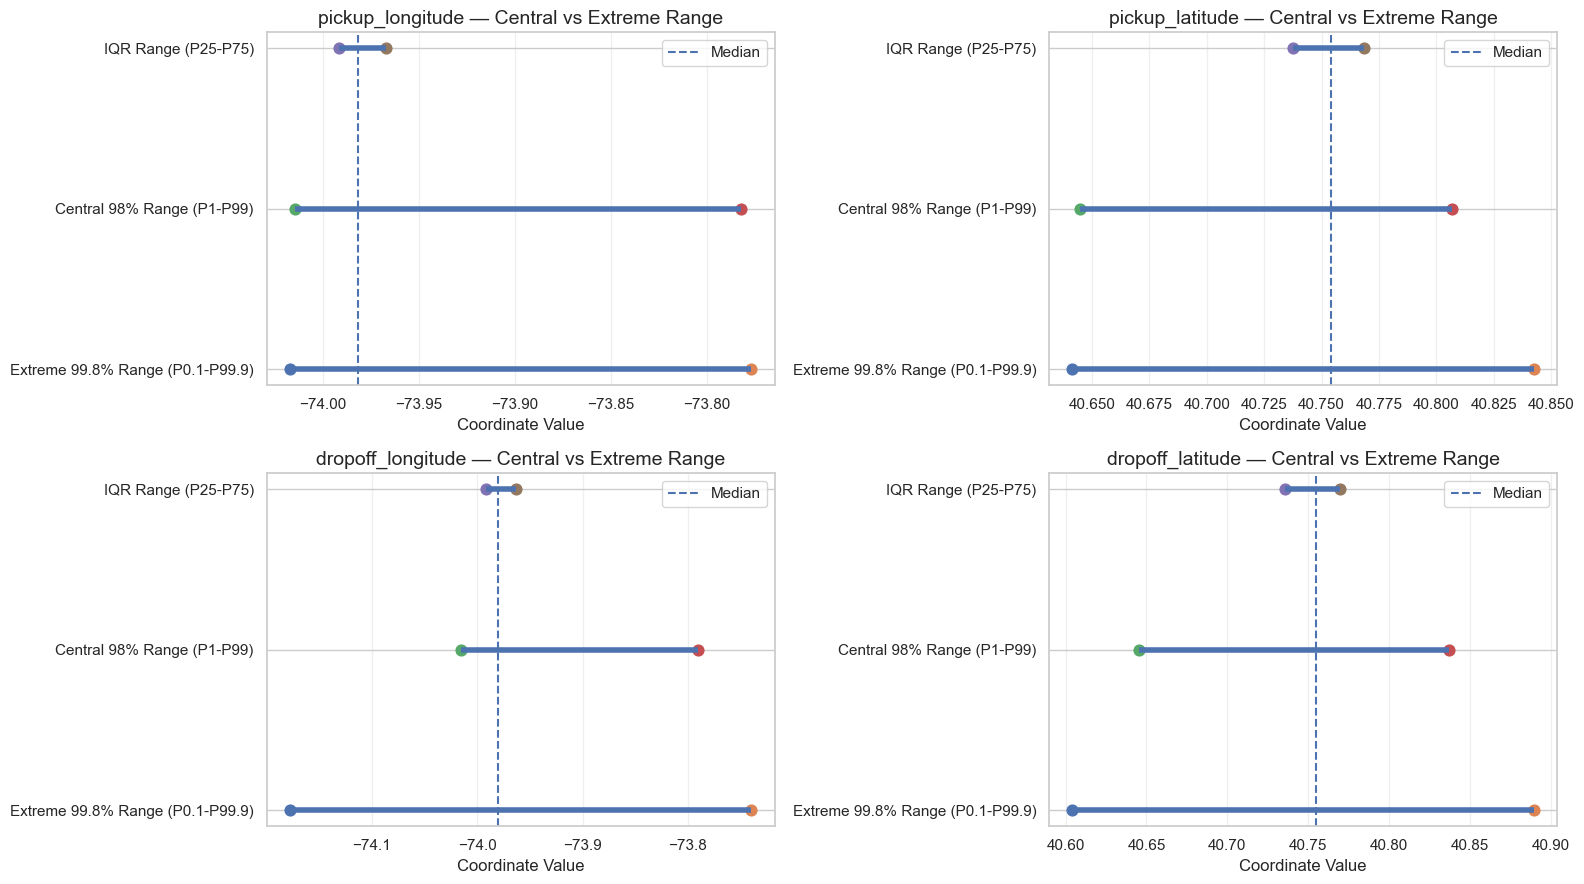

In [79]:
### 5.1.6.6 📊 Central vs Extreme Percentile Range Plot

range_plot_data = []

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce").dropna()
    
    ranges = {
        "IQR Range (P25-P75)": (series.quantile(0.25), series.quantile(0.75)),
        "Central 98% Range (P1-P99)": (series.quantile(0.01), series.quantile(0.99)),
        "Extreme 99.8% Range (P0.1-P99.9)": (series.quantile(0.001), series.quantile(0.999))
    }
    
    for range_name, (lower, upper) in ranges.items():
        range_plot_data.append({
            "Feature": col,
            "Range Type": range_name,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Range Width": upper - lower
        })

range_plot_df = pd.DataFrame(range_plot_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    feature_data = range_plot_df[range_plot_df["Feature"] == col].copy()
    feature_data = feature_data.sort_values("Range Width", ascending=False)
    
    for idx, row in feature_data.iterrows():
        ax.hlines(
            y=row["Range Type"],
            xmin=row["Lower Bound"],
            xmax=row["Upper Bound"],
            linewidth=4
        )
        ax.scatter(row["Lower Bound"], row["Range Type"], s=60)
        ax.scatter(row["Upper Bound"], row["Range Type"], s=60)
    
    median_value = train[col].median()
    ax.axvline(median_value, linestyle="--", linewidth=1.5, label="Median")
    
    ax.set_title(f"{col} — Central vs Extreme Range")
    ax.set_xlabel("Coordinate Value")
    ax.set_ylabel("")
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [80]:
### 5.1.6.7 🧭 Tail Concentration Report

tail_report = quantile_gap_df[
    [
        "Feature",
        "IQR (P75 - P25)",
        "Central 98% Range (P99 - P1)",
        "Extreme 99.8% Range (P99.9 - P0.1)",
        "Lower Tail Gap (P1 - P0.1)",
        "Upper Tail Gap (P99.9 - P99)",
        "Extreme-to-IQR Ratio"
    ]
].copy()

tail_report["Dominant Tail"] = np.where(
    tail_report["Lower Tail Gap (P1 - P0.1)"].abs() > tail_report["Upper Tail Gap (P99.9 - P99)"].abs(),
    "Lower tail",
    "Upper tail"
)

tail_report = tail_report.sort_values("Extreme-to-IQR Ratio", ascending=False)

tail_report

,Feature,IQR (P75 - P25),Central 98% Range (P99 - P1),Extreme 99.8% Range (P99.9 - P0.1),Lower Tail Gap (P1 - P0.1),Upper Tail Gap (P99.9 - P99),Extreme-to-IQR Ratio,Dominant Tail
2,dropoff_longitude,0.0283,0.2248,0.4379,0.1623,0.0507,15.4650,Lower tail
0,pickup_longitude,0.0245,0.2321,0.2405,0.0029,0.0055,9.8032,Upper tail
3,dropoff_latitude,0.0339,0.1915,0.2853,0.0410,0.0528,8.4104,Upper tail
1,pickup_latitude,0.0310,0.1618,0.2010,0.0033,0.0359,6.4803,Upper tail


### 5.1.6.8 🧠 High-level Decision from Percentile Analysis

The percentile analysis shows that all continuous coordinate features are highly concentrated around the expected NYC coordinate range, but each feature has a small number of extreme tail values.

#### Key Decisions

| Area | Decision |
|---|---|
| Central coordinate distribution | Looks stable and realistic for NYC taxi trips |
| IQR / middle 50% range | Very narrow; most trips are geographically concentrated |
| Central 98% range | Wider but still mostly reasonable for NYC and nearby locations |
| Extreme 99.8% range | Contains long tails and should be investigated carefully |
| Percentile-based removal | Not recommended as the primary cleaning rule |
| Coordinate clipping | Not recommended for raw latitude/longitude values |
| Final cleaning basis | Use wide NYC boundary + later distance/time sanity checks |
| Modeling use | Raw coordinates should later be converted into engineered distance/location features |

#### Feature-level Decision

| Feature | Observation | Decision |
|---|---|---|
| `pickup_longitude` | Strong upper-tail stretch after P95/P99 | Investigate, but do not remove directly |
| `pickup_latitude` | Lower tail is more stretched than upper tail | Likely includes southern/outer-area trips; validate with boundary checks |
| `dropoff_longitude` | Strongest two-sided tail behavior | Highest priority for further outlier review |
| `dropoff_latitude` | Both lower and upper tails are wider than pickup latitude | Investigate with dropoff boundary and distance features |

The percentile plots confirm that the extreme values are not representative of the majority of trips.  
However, because coordinate values can represent valid airport, outer-borough, or nearby-city trips, percentile outliers should be treated as **suspicious records**, not automatically invalid records.

### 5.1.6.9 📌 Percentile / Quantile Analysis Summary

The percentile analysis gives a clearer view of the coordinate distributions than minimum and maximum values alone.

#### Main Findings

- All four coordinate features have a compact central distribution.
- The IQR range is very narrow for every feature, meaning the middle 50% of trips are concentrated around core NYC areas.
- The central 98% range is much wider than the IQR range, showing that valid trips may extend beyond the densest Manhattan-centered region.
- The extreme 99.8% range is substantially wider, confirming the presence of rare but influential tail values.
- The robust-scaled heatmap shows that tail distortion is not equal across features:
  - `pickup_longitude` has a strong upper-tail deviation.
  - `dropoff_longitude` has the strongest overall tail distortion.
  - `pickup_latitude` has a stronger lower-tail deviation.
  - `dropoff_latitude` shows wider spread on both sides.

#### Interpretation

Most records are geographically consistent with NYC taxi trips.  
The extreme percentile values are caused by a very small portion of records and are responsible for the high skewness and kurtosis observed earlier.

These values should not be removed only because they fall into extreme percentiles.  
Some of them may represent valid trips involving airports, nearby boroughs, or surrounding areas.

#### Final Decision

For continuous coordinate features, percentile analysis will be used as a diagnostic tool, not as a direct cleaning rule.

The final coordinate-cleaning strategy should be:

1. Remove globally invalid coordinates if found.
2. Flag records outside the wide NYC boundary.
3. Investigate extreme percentile records.
4. Validate suspicious records using engineered distance features.
5. Avoid clipping latitude/longitude values because clipping can create artificial locations.
6. Use raw coordinates mainly for feature engineering rather than direct interpretation.

Overall, the coordinate features are usable, but they require careful boundary validation and distance-based feature engineering before modeling.

### 5.1.7 📦 IQR-based Outlier Analysis

In this section, we will detect statistical outliers in continuous coordinate features using the Interquartile Range (IQR) method.

The IQR method defines outlier boundaries as:

- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Where:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1

For geospatial coordinate features, IQR-based outliers should be interpreted carefully.  
A coordinate can be statistically unusual but still represent a valid airport, outer-borough, or nearby-area trip.

Therefore, IQR outliers will be used as diagnostic flags, not as direct removal rules.

In [81]:
### 5.1.7.1 📊 IQR Outlier Summary Table

iqr_outlier_summary = []

for col in continuous_features:
    series = pd.to_numeric(train[col], errors="coerce").dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    lower_outliers = train[train[col] < lower_bound].shape[0]
    upper_outliers = train[train[col] > upper_bound].shape[0]
    total_outliers = lower_outliers + upper_outliers
    
    iqr_outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Lower Outlier Count": lower_outliers,
        "Upper Outlier Count": upper_outliers,
        "Total Outlier Count": total_outliers,
        "Outlier Percentage": (total_outliers / len(train)) * 100
    })

iqr_outlier_df = pd.DataFrame(iqr_outlier_summary)

numeric_cols = iqr_outlier_df.select_dtypes(include=["int64", "float64"]).columns
iqr_outlier_df[numeric_cols] = iqr_outlier_df[numeric_cols].round(6)

iqr_outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Lower Outlier Count,Upper Outlier Count,Total Outlier Count,Outlier Percentage
0,pickup_longitude,-73.9919,-73.9673,0.0245,-74.0287,-73.9305,669,83653,84322,5.7808
1,pickup_latitude,40.7373,40.7684,0.0310,40.6908,40.8149,45092,7651,52743,3.6159
2,dropoff_longitude,-73.9913,-73.9630,0.0283,-74.0338,-73.9205,4504,73465,77969,5.3453
3,dropoff_latitude,40.7359,40.7698,0.0339,40.6850,40.8207,47409,24581,71990,4.9354


In [82]:
### 5.1.7.2 ⚖️ Lower vs Upper Outlier Composition

outlier_composition_df = iqr_outlier_df[
    [
        "Feature",
        "Lower Outlier Count",
        "Upper Outlier Count",
        "Total Outlier Count",
        "Outlier Percentage"
    ]
].copy()

outlier_composition_df["Lower Outlier Share (%)"] = (
    outlier_composition_df["Lower Outlier Count"] 
    / outlier_composition_df["Total Outlier Count"].replace(0, np.nan)
) * 100

outlier_composition_df["Upper Outlier Share (%)"] = (
    outlier_composition_df["Upper Outlier Count"] 
    / outlier_composition_df["Total Outlier Count"].replace(0, np.nan)
) * 100

outlier_composition_df[
    [
        "Outlier Percentage",
        "Lower Outlier Share (%)",
        "Upper Outlier Share (%)"
    ]
] = outlier_composition_df[
    [
        "Outlier Percentage",
        "Lower Outlier Share (%)",
        "Upper Outlier Share (%)"
    ]
].round(4)

outlier_composition_df

,Feature,Lower Outlier Count,Upper Outlier Count,Total Outlier Count,Outlier Percentage,Lower Outlier Share (%),Upper Outlier Share (%)
0,pickup_longitude,669,83653,84322,5.7808,0.7934,99.2066
1,pickup_latitude,45092,7651,52743,3.6159,85.4938,14.5062
2,dropoff_longitude,4504,73465,77969,5.3453,5.7767,94.2233
3,dropoff_latitude,47409,24581,71990,4.9354,65.8550,34.1450


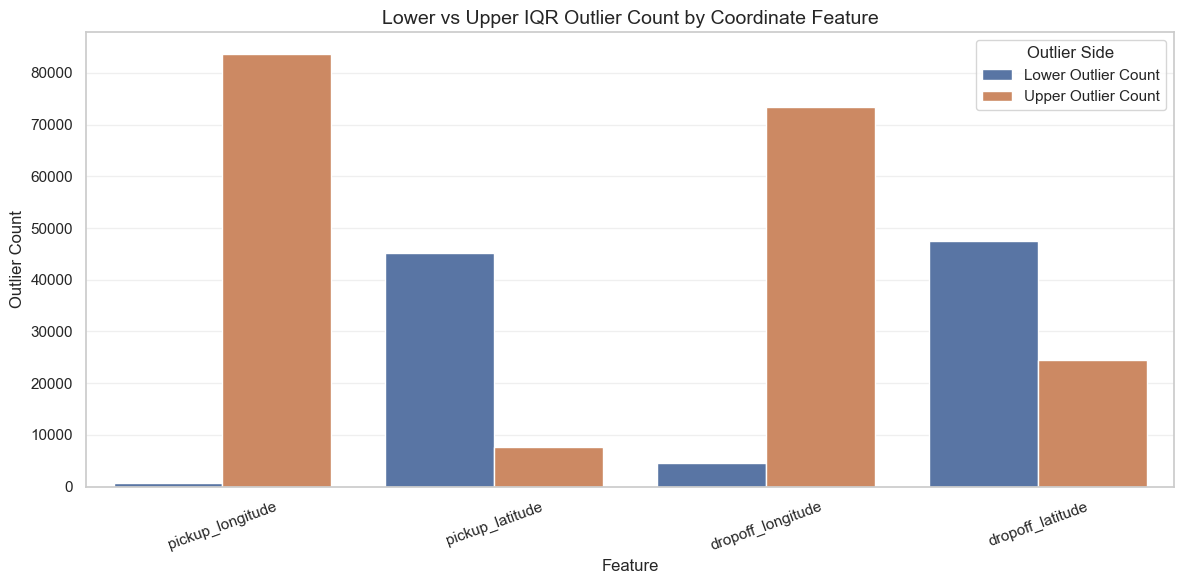

In [83]:
### 5.1.7.3 📊 Lower vs Upper IQR Outlier Composition Plot

plot_df = outlier_composition_df.melt(
    id_vars=["Feature"],
    value_vars=["Lower Outlier Count", "Upper Outlier Count"],
    var_name="Outlier Side",
    value_name="Count"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="Feature",
    y="Count",
    hue="Outlier Side"
)

plt.title("Lower vs Upper IQR Outlier Count by Coordinate Feature")
plt.xlabel("Feature")
plt.ylabel("Outlier Count")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

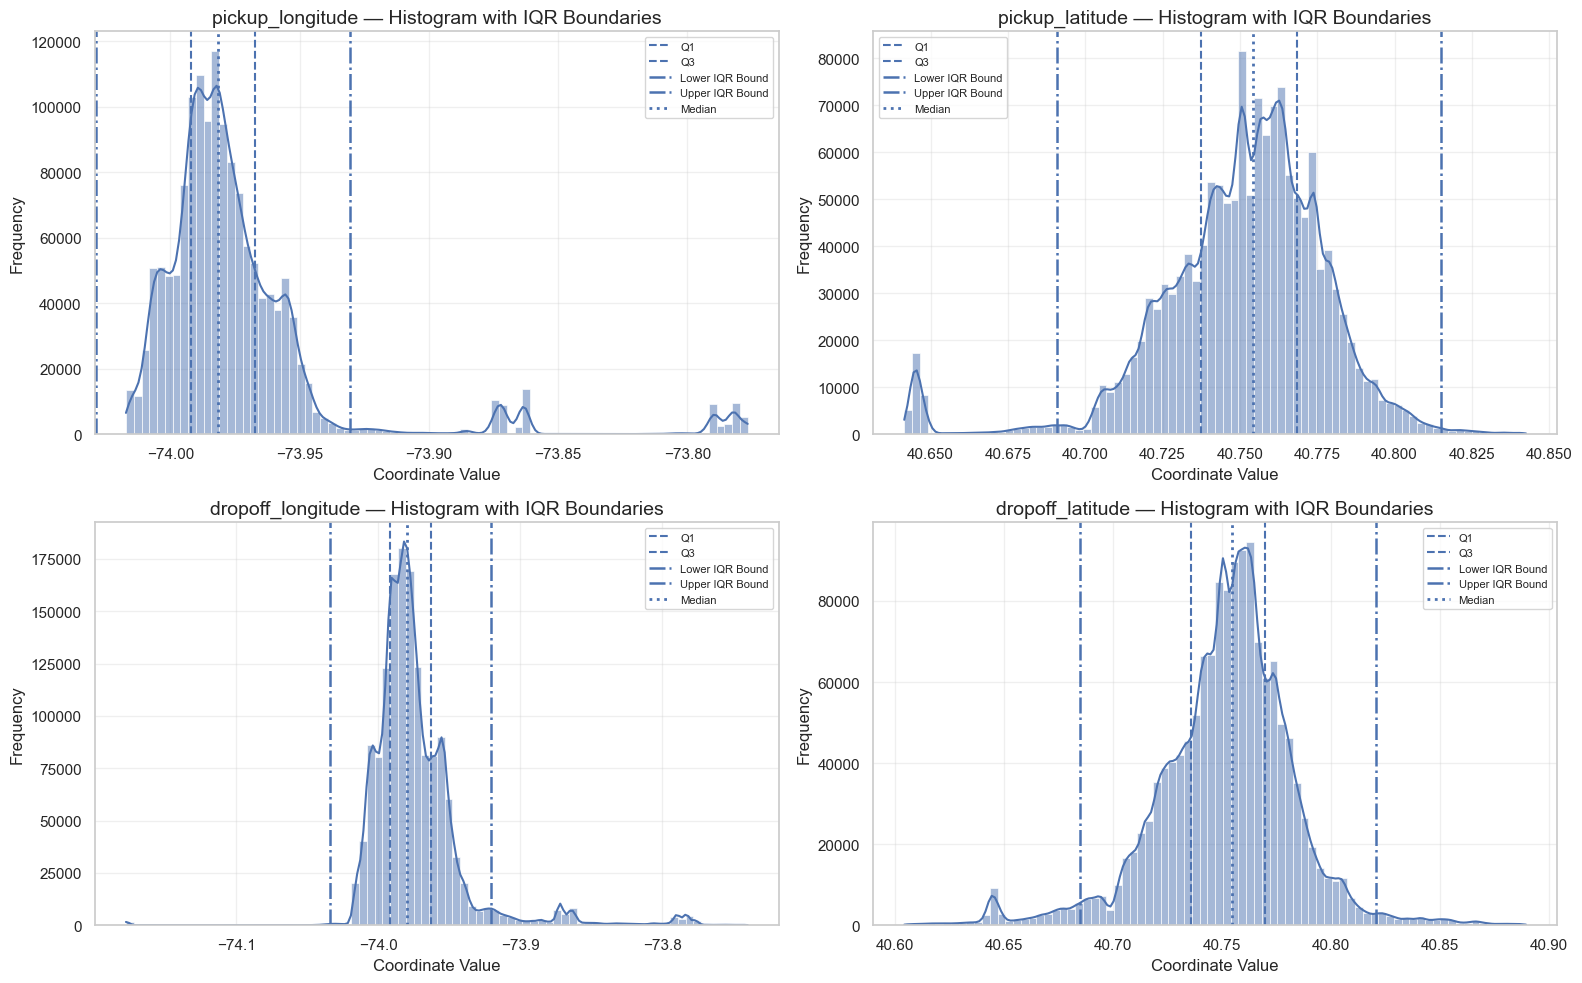

In [84]:
### 5.1.7.4 📈 Distribution with IQR Outlier Boundaries

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    series = pd.to_numeric(train[col], errors="coerce").dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Zoomed range for readability
    lower_zoom = series.quantile(0.001)
    upper_zoom = series.quantile(0.999)
    zoomed_series = series[(series >= lower_zoom) & (series <= upper_zoom)]
    
    sns.histplot(
        zoomed_series,
        bins=80,
        kde=True,
        ax=ax
    )
    
    ax.axvline(q1, linestyle="--", linewidth=1.5, label="Q1")
    ax.axvline(q3, linestyle="--", linewidth=1.5, label="Q3")
    ax.axvline(lower_bound, linestyle="-.", linewidth=1.8, label="Lower IQR Bound")
    ax.axvline(upper_bound, linestyle="-.", linewidth=1.8, label="Upper IQR Bound")
    ax.axvline(series.median(), linestyle=":", linewidth=2, label="Median")
    
    ax.set_title(f"{col} — Histogram with IQR Boundaries")
    ax.set_xlabel("Coordinate Value")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

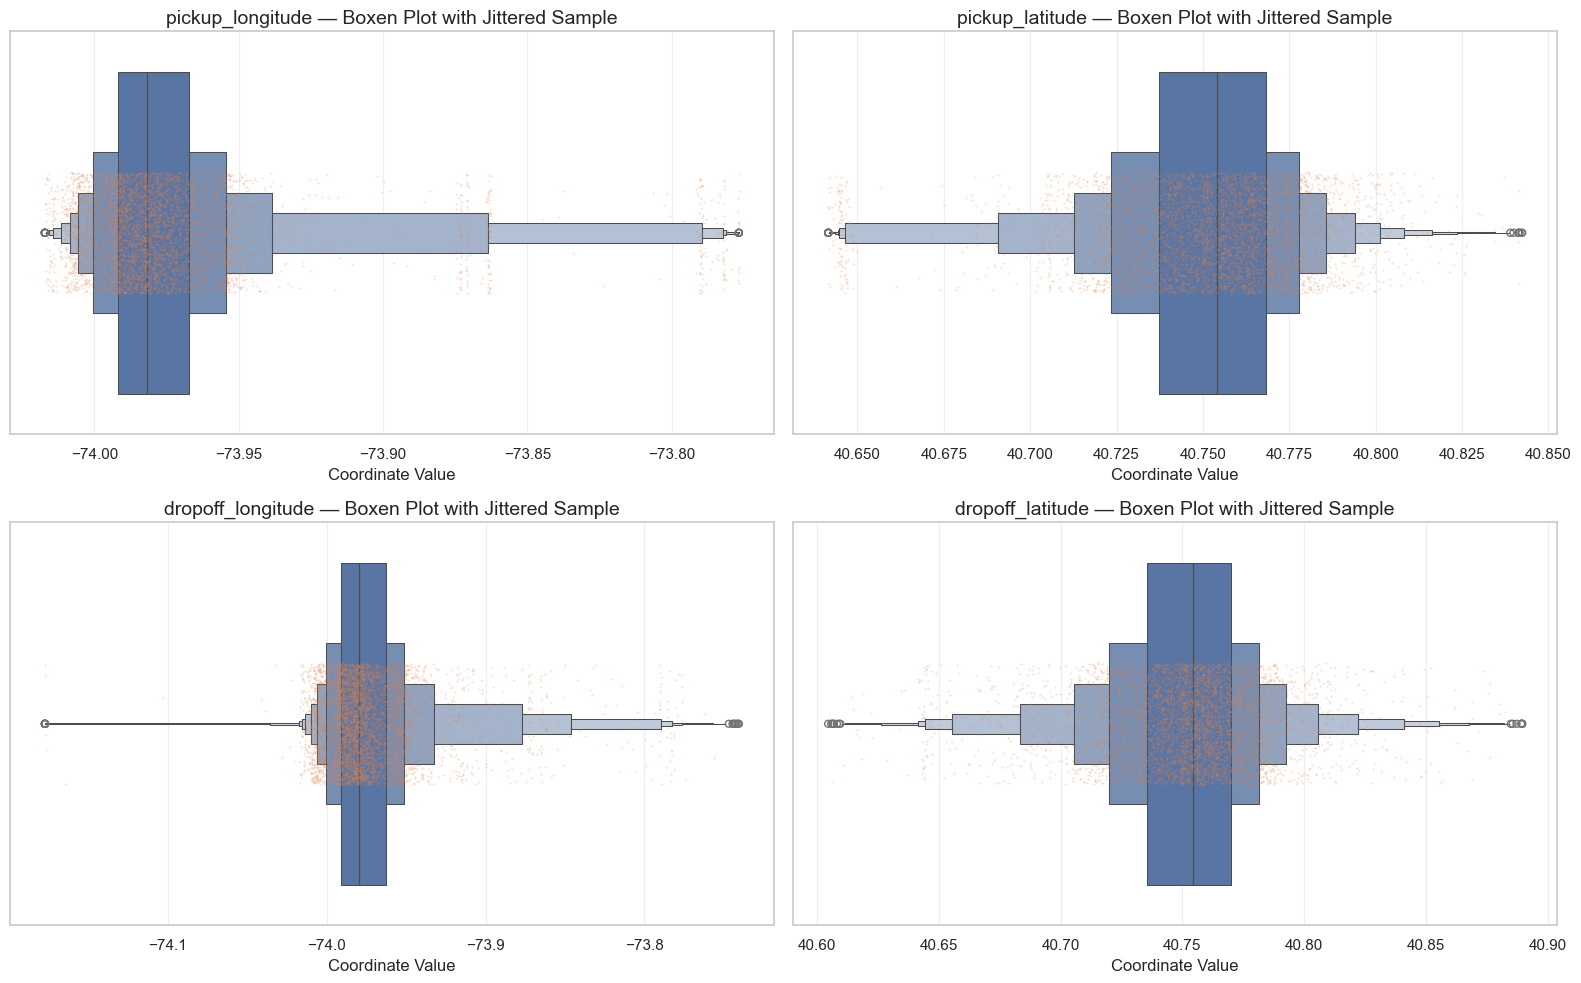

In [85]:
### 5.1.7.5 📦 Boxen Plot with Jittered Sample Points

sample_size = min(30000, len(train))
train_sample = train.sample(sample_size, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    series = pd.to_numeric(train[col], errors="coerce").dropna()
    
    lower_zoom = series.quantile(0.001)
    upper_zoom = series.quantile(0.999)
    
    sample_data = train_sample[
        (train_sample[col] >= lower_zoom) &
        (train_sample[col] <= upper_zoom)
    ]
    
    sns.boxenplot(
        data=sample_data,
        x=col,
        ax=ax
    )
    
    sns.stripplot(
        data=sample_data.sample(min(5000, len(sample_data)), random_state=42),
        x=col,
        ax=ax,
        size=1.5,
        alpha=0.25,
        jitter=0.15
    )
    
    ax.set_title(f"{col} — Boxen Plot with Jittered Sample")
    ax.set_xlabel("Coordinate Value")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:
### 5.1.7.6 🚩 Create IQR Outlier Flags

train_iqr_flags = train.copy()

for col in continuous_features:
    series = pd.to_numeric(train_iqr_flags[col], errors="coerce")
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    train_iqr_flags[f"{col}_iqr_outlier"] = (
        (train_iqr_flags[col] < lower_bound) |
        (train_iqr_flags[col] > upper_bound)
    )

iqr_flag_cols = [f"{col}_iqr_outlier" for col in continuous_features]

train_iqr_flags["any_coordinate_iqr_outlier"] = train_iqr_flags[iqr_flag_cols].any(axis=1)

iqr_flag_summary = pd.DataFrame({
    "Flag": iqr_flag_cols + ["any_coordinate_iqr_outlier"],
    "Outlier Count": [train_iqr_flags[col].sum() for col in iqr_flag_cols] + [train_iqr_flags["any_coordinate_iqr_outlier"].sum()],
    "Outlier Percentage": [
        (train_iqr_flags[col].mean() * 100) for col in iqr_flag_cols
    ] + [(train_iqr_flags["any_coordinate_iqr_outlier"].mean() * 100)]
})

iqr_flag_summary["Outlier Percentage"] = iqr_flag_summary["Outlier Percentage"].round(4)

iqr_flag_summary

,Flag,Outlier Count,Outlier Percentage
0,pickup_longitude_iqr_outlier,84322,5.7808
1,pickup_latitude_iqr_outlier,52743,3.6159
2,dropoff_longitude_iqr_outlier,77969,5.3453
3,dropoff_latitude_iqr_outlier,71990,4.9354
4,any_coordinate_iqr_outlier,190862,13.0849


In [87]:
### 5.1.7.7 🗺️ Compare IQR Outliers with Wide NYC Boundary Violations

wide_lon_min, wide_lon_max = -75.50, -72.80
wide_lat_min, wide_lat_max = 40.00, 41.30

train_iqr_flags["pickup_outside_wide_nyc"] = (
    (train_iqr_flags["pickup_longitude"] < wide_lon_min) |
    (train_iqr_flags["pickup_longitude"] > wide_lon_max) |
    (train_iqr_flags["pickup_latitude"] < wide_lat_min) |
    (train_iqr_flags["pickup_latitude"] > wide_lat_max)
)

train_iqr_flags["dropoff_outside_wide_nyc"] = (
    (train_iqr_flags["dropoff_longitude"] < wide_lon_min) |
    (train_iqr_flags["dropoff_longitude"] > wide_lon_max) |
    (train_iqr_flags["dropoff_latitude"] < wide_lat_min) |
    (train_iqr_flags["dropoff_latitude"] > wide_lat_max)
)

train_iqr_flags["any_outside_wide_nyc"] = (
    train_iqr_flags["pickup_outside_wide_nyc"] |
    train_iqr_flags["dropoff_outside_wide_nyc"]
)

iqr_vs_boundary_summary = pd.DataFrame({
    "Condition": [
        "Any Coordinate IQR Outlier",
        "Any Coordinate Outside Wide NYC Boundary",
        "Both IQR Outlier and Outside Wide NYC",
        "IQR Outlier but Inside Wide NYC",
        "Outside Wide NYC but Not IQR Outlier"
    ],
    "Count": [
        train_iqr_flags["any_coordinate_iqr_outlier"].sum(),
        train_iqr_flags["any_outside_wide_nyc"].sum(),
        (
            train_iqr_flags["any_coordinate_iqr_outlier"] &
            train_iqr_flags["any_outside_wide_nyc"]
        ).sum(),
        (
            train_iqr_flags["any_coordinate_iqr_outlier"] &
            ~train_iqr_flags["any_outside_wide_nyc"]
        ).sum(),
        (
            ~train_iqr_flags["any_coordinate_iqr_outlier"] &
            train_iqr_flags["any_outside_wide_nyc"]
        ).sum()
    ]
})

iqr_vs_boundary_summary["Percentage"] = (
    iqr_vs_boundary_summary["Count"] / len(train_iqr_flags) * 100
).round(4)

iqr_vs_boundary_summary

,Condition,Count,Percentage
0,Any Coordinate IQR Outlier,190862,13.0849
1,Any Coordinate Outside Wide NYC Boundary,55,0.0038
2,Both IQR Outlier and Outside Wide NYC,55,0.0038
3,IQR Outlier but Inside Wide NYC,190807,13.0811
4,Outside Wide NYC but Not IQR Outlier,0,0.0000


### 5.1.7.8 🧠 Summary and Decision from IQR-based Outlier Analysis

The IQR-based outlier analysis confirms that the continuous coordinate features contain statistically unusual values.  
However, these outliers should not be treated as automatically invalid because taxi trips can naturally extend beyond the densest NYC pickup/dropoff areas.

#### Plot-based Observations

- The boxen plots show that most coordinate values are tightly concentrated around the main NYC region.
- The jittered sample points confirm that the majority of records form dense clusters, while only a small portion spreads into the tails.
- The histogram plots show that IQR boundaries are relatively narrow compared to the full coordinate spread.
- The distributions are not perfectly normal; they are geographically clustered and slightly multi-modal.
- Pickup and dropoff coordinates behave differently:
  - Pickup locations are more concentrated.
  - Dropoff locations show wider spread, which is expected because passengers can travel to more diverse destinations.

#### Feature-level Findings

| Feature | Main Outlier Pattern | Interpretation |
|---|---|---|
| `pickup_longitude` | Strong upper-side outliers | Many pickup points are east of the dense central range |
| `pickup_latitude` | Strong lower-side outliers | Some pickup points are south of the central pickup area |
| `dropoff_longitude` | Strong upper-side outliers | Dropoff locations spread more toward the east |
| `dropoff_latitude` | Both lower and upper outliers | Dropoff latitude has wider geographic coverage |

#### Outlier Direction Insight

The lower-vs-upper outlier plot shows that outliers are not balanced across both sides.

- `pickup_longitude` has mostly upper outliers.
- `pickup_latitude` has mostly lower outliers.
- `dropoff_longitude` has mostly upper outliers.
- `dropoff_latitude` has both lower and upper outliers, with stronger lower-side behavior.

This indicates that the outlier pattern is geography-driven, not random noise.

#### Important Interpretation

IQR is useful for identifying statistical outliers, but it is not the best standalone cleaning method for latitude and longitude features.

For coordinate data:

- A value outside the IQR boundary can still be a valid trip.
- Airport trips, outer-borough trips, and nearby-area trips may appear as IQR outliers.
- Removing all IQR outliers would likely remove many valid taxi trips.
- Coordinate features should be validated using spatial logic, not only statistical thresholds.

#### Final Decision

IQR-based outliers will be treated as suspicious records, not direct removal candidates.

No rows will be removed only because they are IQR outliers.

The final coordinate cleaning decision should be based on:

1. Wide NYC boundary checks
2. Pickup/dropoff distance sanity checks
3. Trip duration consistency
4. Haversine and Manhattan distance features
5. Possible airport / outer-area trip handling

#### Modeling Decision

Raw coordinate columns should not be clipped using IQR boundaries.

Instead, they should be used to create stronger geospatial features such as:

- Haversine distance
- Manhattan distance
- Direction / bearing
- Pickup-dropoff distance ratio
- Airport indicators
- Location clusters

Overall, the coordinate features are usable, but IQR outlier flags should be kept only for investigation and later validation.

### 5.1.8 🗺️ Spatial Outlier Visualization and Coordinate Review

In this section, we will review pickup and dropoff coordinates as spatial pairs.

Previous sections analyzed longitude and latitude separately using distribution, percentile, and IQR methods.  
However, coordinate features are naturally paired:

- `pickup_longitude` + `pickup_latitude`
- `dropoff_longitude` + `dropoff_latitude`

A longitude or latitude value can look statistically unusual but still represent a valid location when viewed spatially.

This section focuses on:

- Pickup and dropoff spatial density
- Strict NYC boundary vs wide NYC boundary
- Spatial concentration of normal records
- Location of suspicious coordinate points
- Whether coordinate outliers are isolated or geographically meaningful

In [88]:
### 5.1.8.1 📌 Boundary Setup and Spatial Flags

# Strict NYC boundary: dense NYC operational region
strict_lon_min, strict_lon_max = -74.30, -73.65
strict_lat_min, strict_lat_max = 40.45, 40.95

# Wide NYC boundary: safer boundary allowing airports and nearby areas
wide_lon_min, wide_lon_max = -75.50, -72.80
wide_lat_min, wide_lat_max = 40.00, 41.30

spatial_df = train.copy()

spatial_df["pickup_inside_strict_nyc"] = (
    spatial_df["pickup_longitude"].between(strict_lon_min, strict_lon_max) &
    spatial_df["pickup_latitude"].between(strict_lat_min, strict_lat_max)
)

spatial_df["dropoff_inside_strict_nyc"] = (
    spatial_df["dropoff_longitude"].between(strict_lon_min, strict_lon_max) &
    spatial_df["dropoff_latitude"].between(strict_lat_min, strict_lat_max)
)

spatial_df["pickup_inside_wide_nyc"] = (
    spatial_df["pickup_longitude"].between(wide_lon_min, wide_lon_max) &
    spatial_df["pickup_latitude"].between(wide_lat_min, wide_lat_max)
)

spatial_df["dropoff_inside_wide_nyc"] = (
    spatial_df["dropoff_longitude"].between(wide_lon_min, wide_lon_max) &
    spatial_df["dropoff_latitude"].between(wide_lat_min, wide_lat_max)
)

spatial_df["either_outside_strict_nyc"] = (
    ~spatial_df["pickup_inside_strict_nyc"] |
    ~spatial_df["dropoff_inside_strict_nyc"]
)

spatial_df["either_outside_wide_nyc"] = (
    ~spatial_df["pickup_inside_wide_nyc"] |
    ~spatial_df["dropoff_inside_wide_nyc"]
)

spatial_flag_summary = pd.DataFrame({
    "Condition": [
        "Pickup outside strict NYC",
        "Dropoff outside strict NYC",
        "Either pickup/dropoff outside strict NYC",
        "Pickup outside wide NYC",
        "Dropoff outside wide NYC",
        "Either pickup/dropoff outside wide NYC"
    ],
    "Count": [
        (~spatial_df["pickup_inside_strict_nyc"]).sum(),
        (~spatial_df["dropoff_inside_strict_nyc"]).sum(),
        spatial_df["either_outside_strict_nyc"].sum(),
        (~spatial_df["pickup_inside_wide_nyc"]).sum(),
        (~spatial_df["dropoff_inside_wide_nyc"]).sum(),
        spatial_df["either_outside_wide_nyc"].sum()
    ]
})

spatial_flag_summary["Percentage"] = (
    spatial_flag_summary["Count"] / len(spatial_df) * 100
).round(4)

spatial_flag_summary

,Condition,Count,Percentage
0,Pickup outside strict NYC,247,0.0169
1,Dropoff outside strict NYC,879,0.0603
2,Either pickup/dropoff outside strict NYC,892,0.0612
3,Pickup outside wide NYC,36,0.0025
4,Dropoff outside wide NYC,51,0.0035
5,Either pickup/dropoff outside wide NYC,55,0.0038


In [89]:
### 5.1.8.2 🧰 Helper Function for Boundary Boxes

from matplotlib.patches import Rectangle

def add_boundary_boxes(ax):
    """
    Add strict and wide NYC boundary boxes to a longitude-latitude plot.
    """
    strict_box = Rectangle(
        (strict_lon_min, strict_lat_min),
        strict_lon_max - strict_lon_min,
        strict_lat_max - strict_lat_min,
        fill=False,
        linestyle="--",
        linewidth=2,
        label="Strict NYC Boundary"
    )
    
    wide_box = Rectangle(
        (wide_lon_min, wide_lat_min),
        wide_lon_max - wide_lon_min,
        wide_lat_max - wide_lat_min,
        fill=False,
        linestyle="-.",
        linewidth=2,
        label="Wide NYC Boundary"
    )
    
    ax.add_patch(strict_box)
    ax.add_patch(wide_box)

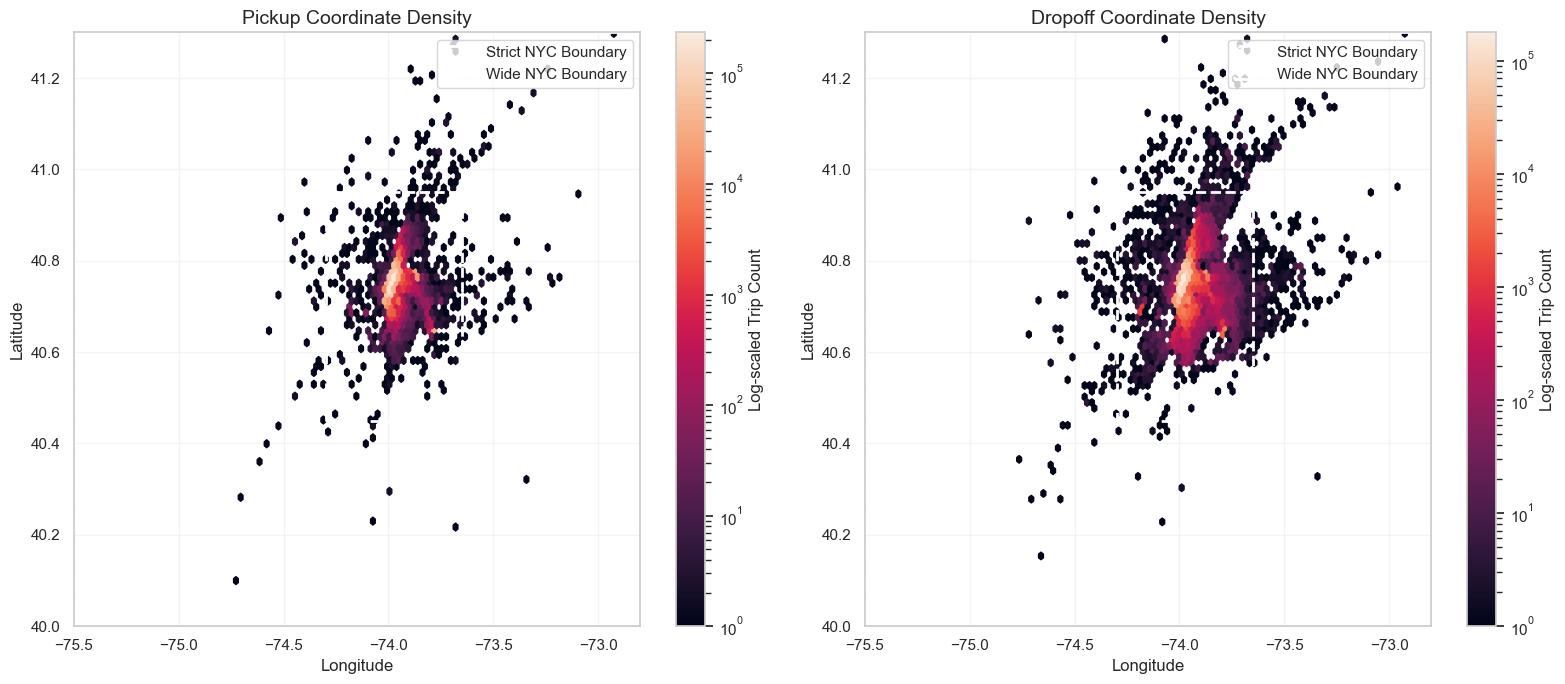

In [90]:
### 5.1.8.3 🔷 Pickup vs Dropoff Hexbin Density Map

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_specs = [
    {
        "title": "Pickup Coordinate Density",
        "lon": "pickup_longitude",
        "lat": "pickup_latitude"
    },
    {
        "title": "Dropoff Coordinate Density",
        "lon": "dropoff_longitude",
        "lat": "dropoff_latitude"
    }
]

for ax, spec in zip(axes, plot_specs):
    inside_wide = spatial_df[
        spatial_df[spec["lon"]].between(wide_lon_min, wide_lon_max) &
        spatial_df[spec["lat"]].between(wide_lat_min, wide_lat_max)
    ]
    
    hb = ax.hexbin(
        inside_wide[spec["lon"]],
        inside_wide[spec["lat"]],
        gridsize=80,
        mincnt=1,
        bins="log"
    )
    
    add_boundary_boxes(ax)
    
    ax.set_title(spec["title"])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(wide_lon_min, wide_lon_max)
    ax.set_ylim(wide_lat_min, wide_lat_max)
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")
    
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Log-scaled Trip Count")

plt.tight_layout()
plt.show()

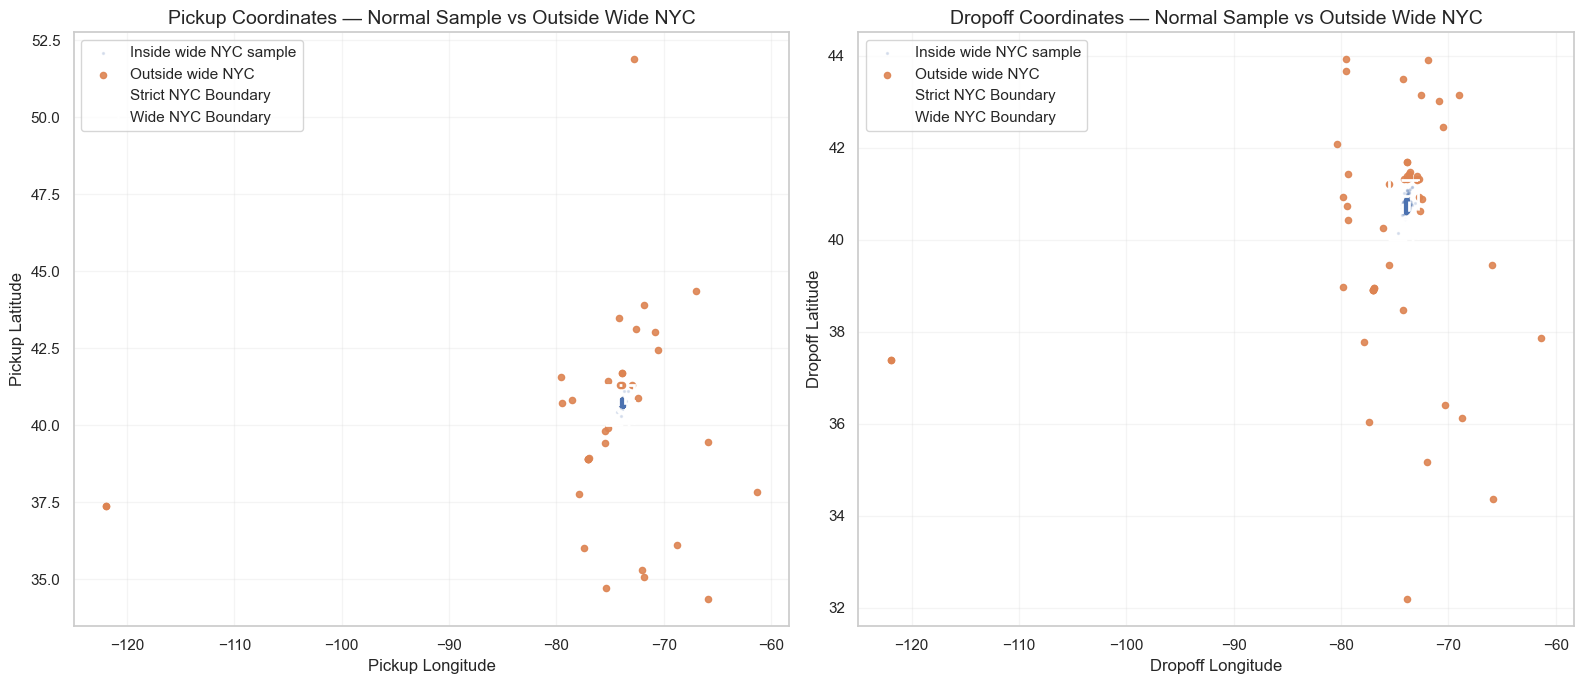

In [91]:
### 5.1.8.4 🚩 Spatial Scatter Review with Suspicious Points

normal_sample_size = 50000

normal_pickup = spatial_df[spatial_df["pickup_inside_wide_nyc"]].sample(
    min(normal_sample_size, spatial_df["pickup_inside_wide_nyc"].sum()),
    random_state=42
)

normal_dropoff = spatial_df[spatial_df["dropoff_inside_wide_nyc"]].sample(
    min(normal_sample_size, spatial_df["dropoff_inside_wide_nyc"].sum()),
    random_state=42
)

pickup_outside_wide = spatial_df[~spatial_df["pickup_inside_wide_nyc"]]
dropoff_outside_wide = spatial_df[~spatial_df["dropoff_inside_wide_nyc"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pickup plot
axes[0].scatter(
    normal_pickup["pickup_longitude"],
    normal_pickup["pickup_latitude"],
    s=2,
    alpha=0.15,
    label="Inside wide NYC sample"
)

axes[0].scatter(
    pickup_outside_wide["pickup_longitude"],
    pickup_outside_wide["pickup_latitude"],
    s=20,
    alpha=0.9,
    label="Outside wide NYC"
)

add_boundary_boxes(axes[0])

axes[0].set_title("Pickup Coordinates — Normal Sample vs Outside Wide NYC")
axes[0].set_xlabel("Pickup Longitude")
axes[0].set_ylabel("Pickup Latitude")
axes[0].grid(alpha=0.2)
axes[0].legend()

# Dropoff plot
axes[1].scatter(
    normal_dropoff["dropoff_longitude"],
    normal_dropoff["dropoff_latitude"],
    s=2,
    alpha=0.15,
    label="Inside wide NYC sample"
)

axes[1].scatter(
    dropoff_outside_wide["dropoff_longitude"],
    dropoff_outside_wide["dropoff_latitude"],
    s=20,
    alpha=0.9,
    label="Outside wide NYC"
)

add_boundary_boxes(axes[1])

axes[1].set_title("Dropoff Coordinates — Normal Sample vs Outside Wide NYC")
axes[1].set_xlabel("Dropoff Longitude")
axes[1].set_ylabel("Dropoff Latitude")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

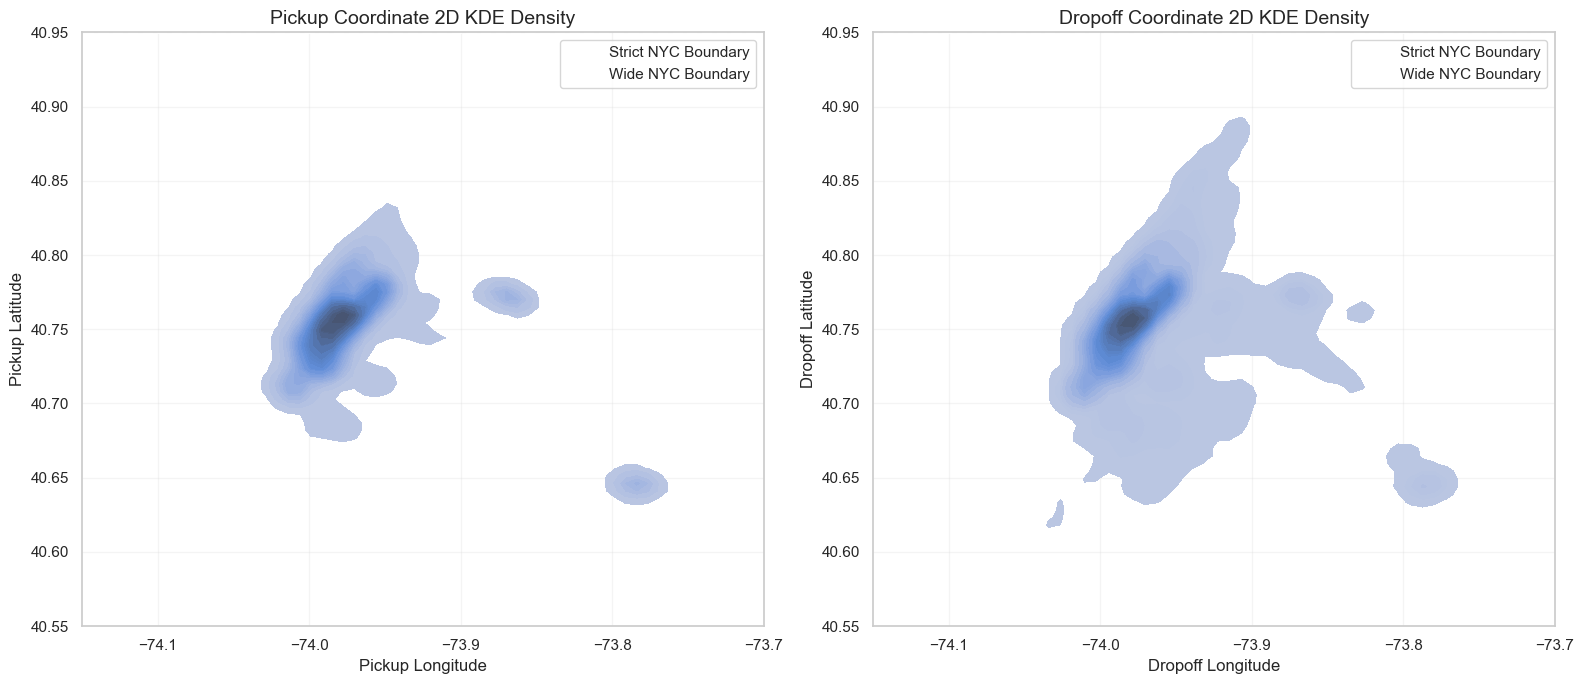

In [92]:
### 5.1.8.5 🌀 2D KDE Contour Plot for Coordinate Density

kde_sample_size = 60000

pickup_kde_sample = spatial_df[spatial_df["pickup_inside_wide_nyc"]].sample(
    min(kde_sample_size, spatial_df["pickup_inside_wide_nyc"].sum()),
    random_state=42
)

dropoff_kde_sample = spatial_df[spatial_df["dropoff_inside_wide_nyc"]].sample(
    min(kde_sample_size, spatial_df["dropoff_inside_wide_nyc"].sum()),
    random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.kdeplot(
    data=pickup_kde_sample,
    x="pickup_longitude",
    y="pickup_latitude",
    fill=True,
    levels=25,
    thresh=0.02,
    ax=axes[0]
)

add_boundary_boxes(axes[0])

axes[0].set_title("Pickup Coordinate 2D KDE Density")
axes[0].set_xlabel("Pickup Longitude")
axes[0].set_ylabel("Pickup Latitude")
axes[0].set_xlim(-74.15, -73.70)
axes[0].set_ylim(40.55, 40.95)
axes[0].grid(alpha=0.2)
axes[0].legend()

sns.kdeplot(
    data=dropoff_kde_sample,
    x="dropoff_longitude",
    y="dropoff_latitude",
    fill=True,
    levels=25,
    thresh=0.02,
    ax=axes[1]
)

add_boundary_boxes(axes[1])

axes[1].set_title("Dropoff Coordinate 2D KDE Density")
axes[1].set_xlabel("Dropoff Longitude")
axes[1].set_ylabel("Dropoff Latitude")
axes[1].set_xlim(-74.15, -73.70)
axes[1].set_ylim(40.55, 40.95)
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

In [93]:
### 5.1.8.6 🧭 Strict vs Wide Boundary Classification

def classify_spatial_status(row, prefix):
    inside_strict = row[f"{prefix}_inside_strict_nyc"]
    inside_wide = row[f"{prefix}_inside_wide_nyc"]
    
    if inside_strict:
        return "Inside strict NYC"
    elif inside_wide:
        return "Outside strict but inside wide NYC"
    else:
        return "Outside wide NYC"

spatial_df["pickup_spatial_status"] = spatial_df.apply(
    lambda row: classify_spatial_status(row, "pickup"),
    axis=1
)

spatial_df["dropoff_spatial_status"] = spatial_df.apply(
    lambda row: classify_spatial_status(row, "dropoff"),
    axis=1
)

pickup_status_summary = (
    spatial_df["pickup_spatial_status"]
    .value_counts()
    .rename_axis("Spatial Status")
    .reset_index(name="Pickup Count")
)

pickup_status_summary["Pickup Percentage"] = (
    pickup_status_summary["Pickup Count"] / len(spatial_df) * 100
).round(4)

dropoff_status_summary = (
    spatial_df["dropoff_spatial_status"]
    .value_counts()
    .rename_axis("Spatial Status")
    .reset_index(name="Dropoff Count")
)

dropoff_status_summary["Dropoff Percentage"] = (
    dropoff_status_summary["Dropoff Count"] / len(spatial_df) * 100
).round(4)

spatial_status_summary = pickup_status_summary.merge(
    dropoff_status_summary,
    on="Spatial Status",
    how="outer"
).fillna(0)

spatial_status_summary

,Spatial Status,Pickup Count,Pickup Percentage,Dropoff Count,Dropoff Percentage
0,Inside strict NYC,1458397,99.9831,1457765,99.9397
1,Outside strict but inside wide NYC,211,0.0145,828,0.0568
2,Outside wide NYC,36,0.0025,51,0.0035


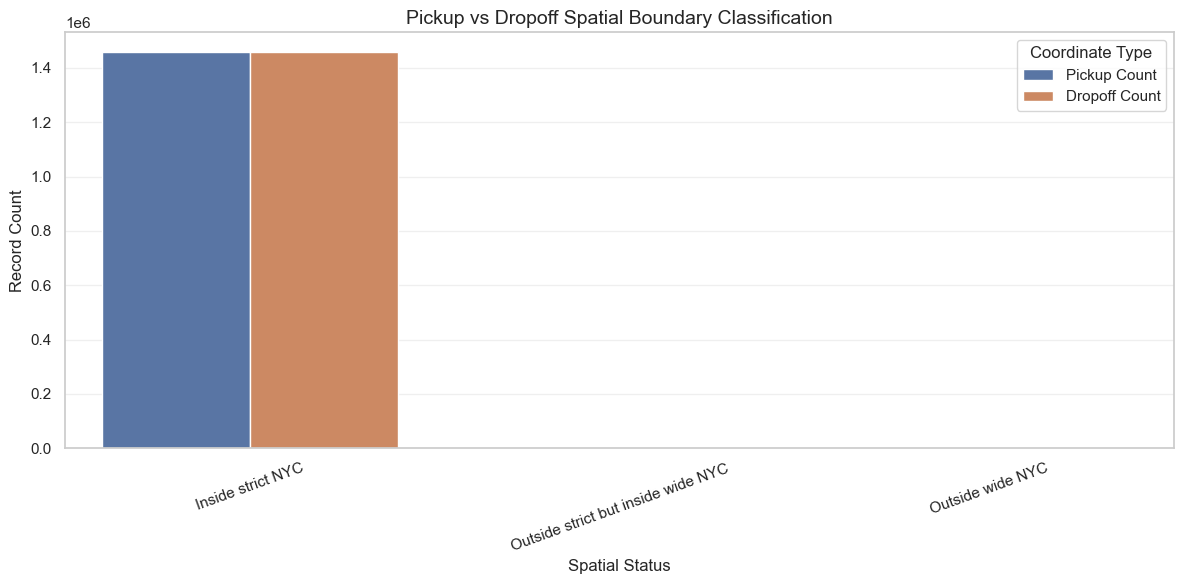

In [94]:
### 5.1.8.7 📊 Boundary Classification Plot

status_plot_df = spatial_status_summary.melt(
    id_vars="Spatial Status",
    value_vars=["Pickup Count", "Dropoff Count"],
    var_name="Coordinate Type",
    value_name="Count"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=status_plot_df,
    x="Spatial Status",
    y="Count",
    hue="Coordinate Type"
)

plt.title("Pickup vs Dropoff Spatial Boundary Classification")
plt.xlabel("Spatial Status")
plt.ylabel("Record Count")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
### 5.1.8.8 🔎 Review Records Outside Wide NYC Boundary

outside_wide_records = spatial_df[spatial_df["either_outside_wide_nyc"]].copy()

review_cols = [
    "id",
    "vendor_id",
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration",
    "pickup_spatial_status",
    "dropoff_spatial_status"
]

outside_wide_review = outside_wide_records[review_cols].sort_values(
    by="trip_duration",
    ascending=False
)

outside_wide_review.head(20)

,id,vendor_id,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_spatial_status,dropoff_spatial_status
114376,id1311087,1,2016-02-29 12:16:29,-75.4559,39.8039,-73.7960,40.7077,23440,Outside wide NYC,Inside strict NYC
1416336,id3795134,1,2016-03-21 20:54:00,-75.2383,39.9230,-73.9226,40.6101,17363,Outside wide NYC,Inside strict NYC
1301396,id1216866,1,2016-03-26 22:01:54,-73.9815,40.7733,-76.1357,40.2436,9922,Inside strict NYC,Outside wide NYC
14502,id1092161,1,2016-04-15 22:35:08,-73.7818,40.6447,-72.7114,41.3115,7153,Inside strict NYC,Outside wide NYC
837898,id2767862,2,2016-05-17 20:29:57,-73.9769,40.7519,-73.6286,41.4214,7064,Inside strict NYC,Outside wide NYC
628028,id0806322,1,2016-04-08 01:05:54,-73.9924,40.7538,-73.7118,41.3606,5947,Inside strict NYC,Outside wide NYC
978647,id0687776,2,2016-04-28 20:22:43,-73.9919,40.7510,-72.9123,41.3890,5922,Inside strict NYC,Outside wide NYC
1058081,id3411872,1,2016-04-08 16:27:07,-74.0024,40.7399,-73.9009,41.3870,5719,Inside strict NYC,Outside wide NYC
512980,id2066082,1,2016-01-25 23:53:17,-73.8777,40.7722,-72.9059,41.3198,5549,Inside strict NYC,Outside wide NYC
396966,id3476102,1,2016-02-19 20:03:37,-73.7848,40.6485,-73.6260,41.4808,5323,Inside strict NYC,Outside wide NYC


In [96]:
### 5.1.8.9 ⏱️ Trip Duration Summary for Spatial Outliers

duration_by_spatial_group = spatial_df.assign(
    spatial_group=np.where(
        spatial_df["either_outside_wide_nyc"],
        "Outside wide NYC",
        "Inside wide NYC"
    )
).groupby("spatial_group")["trip_duration"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max",
    p90=lambda x: x.quantile(0.90),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99)
).reset_index()

duration_by_spatial_group[
    ["mean", "median", "p90", "p95", "p99"]
] = duration_by_spatial_group[
    ["mean", "median", "p90", "p95", "p99"]
].round(2)

duration_by_spatial_group

,spatial_group,count,mean,median,min,max,p90,p95,p99
0,Inside wide NYC,1458589,959.4300,662.0000,1,3526282,1634.0000,2104.0000,3439.0000
1,Outside wide NYC,55,2503.8500,782.0000,19,23440,5937.0000,7983.7000,20158.4200


### 5.1.8.10 🧠 Summary and Decision from Spatial Coordinate Review

The spatial coordinate review confirms that pickup and dropoff locations are mostly concentrated around the expected NYC taxi operating region.  
The visual patterns also show that most coordinate outliers are spatially meaningful, while a very small number of records are clearly far away from NYC.

#### Plot-based Observations

- The boundary classification plot shows that almost all pickup and dropoff records fall inside the strict NYC boundary.
- The number of records outside strict or wide NYC boundary is very small compared to the full dataset.
- The KDE density plots show a strong central density around core NYC locations.
- Pickup coordinates are more compact and concentrated.
- Dropoff coordinates are more spread out, which is expected because passengers can travel to a wider set of destinations.
- The scatter plots show that outside-wide-NYC records are clearly separated from the main NYC cluster.
- Some outside-wide points have extreme longitude or latitude values, indicating likely GPS noise, wrong coordinates, or trips not relevant to NYC taxi behavior.
- The hexbin density plots confirm that the highest-density region is stable and geographically reasonable.
- Dropoff density has a wider spatial footprint than pickup density, which supports the earlier IQR and percentile findings.

#### Important Insight

The spatial plots separate two different types of unusual records:

| Case | Interpretation | Decision |
|---|---|---|
| Outside strict but inside wide NYC | Possibly valid airport, borough, or nearby-area trips | Keep |
| Outside wide NYC | Strong suspicious candidate | Flag for removal/review |
| IQR outlier but spatially inside NYC | Statistically unusual but geographically valid | Keep |
| Extreme coordinate far from NYC | Likely invalid or irrelevant record | Remove candidate |

#### Feature-level Interpretation

| Coordinate Type | Observation | Interpretation |
|---|---|---|
| Pickup coordinates | Dense and compact around NYC | Pickup locations are relatively stable |
| Dropoff coordinates | Wider geographic spread | Dropoff destinations are more diverse |
| Pickup outside-wide points | Very rare but some are extremely far away | Strong suspicious candidates |
| Dropoff outside-wide points | More spatially spread than pickup | Needs distance and duration validation |

#### Final Decision

No records should be removed only because they are outside the strict NYC boundary.

The strict boundary is useful for understanding the dense NYC operating area, but it is too restrictive for final cleaning because valid airport or outer-area trips may fall outside it.

The wide NYC boundary is a safer rule for identifying suspicious coordinates.

Final coordinate-cleaning strategy:

1. Keep records inside the strict NYC boundary.
2. Keep records outside strict but inside wide NYC boundary.
3. Flag records outside the wide NYC boundary as strong cleaning candidates.
4. Validate flagged records using distance and trip duration checks.
5. Remove only clearly invalid or unrealistic coordinate records during final preprocessing.
6. Do not clip raw latitude or longitude values.

#### Modeling Decision

Raw coordinate columns should not be used as final standalone features without transformation.

They should be converted into more meaningful geospatial features:

- Haversine distance
- Manhattan distance
- Direction / bearing
- Pickup-dropoff distance ratio
- Airport indicators
- Pickup/dropoff cluster labels
- Distance from NYC center
- Spatial boundary flags

Overall, the coordinate features are usable.  
The main NYC spatial pattern is strong and valid, but rare extreme coordinates should be handled carefully before modeling.

### 5.1.9 🧹 Coordinate Cleaning Candidate Summary

In this section, we will consolidate all coordinate-related diagnostic checks into one structured cleaning candidate summary.

Previous sections identified:

- Statistical outliers using IQR
- Extreme values using percentile analysis
- Strict and wide NYC boundary violations
- Spatially suspicious pickup/dropoff coordinates

Now we will combine these signals into a final coordinate quality classification.

The goal is not to remove rows immediately.  
Instead, we will classify records into cleaning-risk groups so that final preprocessing can apply a clear and reproducible rule.+

In [97]:
### 5.1.9.1 🚩 Consolidate Coordinate Diagnostic Flags

coordinate_df = train.copy()

coordinate_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

# Coordinate boundary definitions
strict_lon_min, strict_lon_max = -74.30, -73.65
strict_lat_min, strict_lat_max = 40.45, 40.95

wide_lon_min, wide_lon_max = -75.50, -72.80
wide_lat_min, wide_lat_max = 40.00, 41.30

# -----------------------------
# 1. Global coordinate validity
# -----------------------------
coordinate_df["pickup_globally_valid"] = (
    coordinate_df["pickup_longitude"].between(-180, 180) &
    coordinate_df["pickup_latitude"].between(-90, 90)
)

coordinate_df["dropoff_globally_valid"] = (
    coordinate_df["dropoff_longitude"].between(-180, 180) &
    coordinate_df["dropoff_latitude"].between(-90, 90)
)

coordinate_df["any_globally_invalid_coordinate"] = (
    ~coordinate_df["pickup_globally_valid"] |
    ~coordinate_df["dropoff_globally_valid"]
)

# -----------------------------
# 2. Zero coordinate check
# -----------------------------
coordinate_df["pickup_zero_coordinate"] = (
    (coordinate_df["pickup_longitude"] == 0) |
    (coordinate_df["pickup_latitude"] == 0)
)

coordinate_df["dropoff_zero_coordinate"] = (
    (coordinate_df["dropoff_longitude"] == 0) |
    (coordinate_df["dropoff_latitude"] == 0)
)

coordinate_df["any_zero_coordinate"] = (
    coordinate_df["pickup_zero_coordinate"] |
    coordinate_df["dropoff_zero_coordinate"]
)

# -----------------------------
# 3. Strict NYC boundary flags
# -----------------------------
coordinate_df["pickup_inside_strict_nyc"] = (
    coordinate_df["pickup_longitude"].between(strict_lon_min, strict_lon_max) &
    coordinate_df["pickup_latitude"].between(strict_lat_min, strict_lat_max)
)

coordinate_df["dropoff_inside_strict_nyc"] = (
    coordinate_df["dropoff_longitude"].between(strict_lon_min, strict_lon_max) &
    coordinate_df["dropoff_latitude"].between(strict_lat_min, strict_lat_max)
)

coordinate_df["either_outside_strict_nyc"] = (
    ~coordinate_df["pickup_inside_strict_nyc"] |
    ~coordinate_df["dropoff_inside_strict_nyc"]
)

# -----------------------------
# 4. Wide NYC boundary flags
# -----------------------------
coordinate_df["pickup_inside_wide_nyc"] = (
    coordinate_df["pickup_longitude"].between(wide_lon_min, wide_lon_max) &
    coordinate_df["pickup_latitude"].between(wide_lat_min, wide_lat_max)
)

coordinate_df["dropoff_inside_wide_nyc"] = (
    coordinate_df["dropoff_longitude"].between(wide_lon_min, wide_lon_max) &
    coordinate_df["dropoff_latitude"].between(wide_lat_min, wide_lat_max)
)

coordinate_df["either_outside_wide_nyc"] = (
    ~coordinate_df["pickup_inside_wide_nyc"] |
    ~coordinate_df["dropoff_inside_wide_nyc"]
)

# -----------------------------
# 5. IQR outlier flags
# -----------------------------
for col in coordinate_features:
    q1 = coordinate_df[col].quantile(0.25)
    q3 = coordinate_df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    coordinate_df[f"{col}_iqr_outlier"] = (
        (coordinate_df[col] < lower_bound) |
        (coordinate_df[col] > upper_bound)
    )

iqr_flag_cols = [f"{col}_iqr_outlier" for col in coordinate_features]

coordinate_df["any_coordinate_iqr_outlier"] = coordinate_df[iqr_flag_cols].any(axis=1)

# -----------------------------
# 6. Combined diagnostic count
# -----------------------------
main_flag_cols = [
    "any_globally_invalid_coordinate",
    "any_zero_coordinate",
    "either_outside_strict_nyc",
    "either_outside_wide_nyc",
    "any_coordinate_iqr_outlier"
]

coordinate_df["coordinate_diagnostic_flag_count"] = coordinate_df[main_flag_cols].sum(axis=1)

coordinate_df[main_flag_cols + ["coordinate_diagnostic_flag_count"]].head()

,any_globally_invalid_coordinate,any_zero_coordinate,either_outside_strict_nyc,either_outside_wide_nyc,any_coordinate_iqr_outlier,coordinate_diagnostic_flag_count
0,False,False,False,False,False,0
1,False,False,False,False,False,0
2,False,False,False,False,False,0
3,False,False,False,False,False,0
4,False,False,False,False,False,0


In [98]:
### 5.1.9.2 🧭 Coordinate Cleaning Severity Classification

def classify_coordinate_severity(row):
    """
    Classify coordinate records into risk groups.
    This classification is diagnostic and should not directly mutate the training data.
    """
    if row["any_globally_invalid_coordinate"] or row["any_zero_coordinate"]:
        return "Critical - invalid coordinate"
    
    if row["either_outside_wide_nyc"]:
        return "High - outside wide NYC"
    
    if row["either_outside_strict_nyc"] and row["any_coordinate_iqr_outlier"]:
        return "Medium - outside strict + IQR outlier"
    
    if row["either_outside_strict_nyc"]:
        return "Medium - outside strict only"
    
    if row["any_coordinate_iqr_outlier"]:
        return "Low - IQR outlier inside NYC"
    
    return "Clean - normal coordinate range"


coordinate_df["coordinate_cleaning_severity"] = coordinate_df.apply(
    classify_coordinate_severity,
    axis=1
)

def assign_coordinate_action(severity):
    if severity == "Critical - invalid coordinate":
        return "Remove candidate"
    if severity == "High - outside wide NYC":
        return "Strong review / remove candidate"
    if severity.startswith("Medium"):
        return "Keep but review"
    if severity.startswith("Low"):
        return "Keep"
    return "Keep"


coordinate_df["coordinate_cleaning_action"] = coordinate_df["coordinate_cleaning_severity"].apply(
    assign_coordinate_action
)

coordinate_df[
    [
        "coordinate_cleaning_severity",
        "coordinate_cleaning_action",
        "coordinate_diagnostic_flag_count"
    ]
].head()

,coordinate_cleaning_severity,coordinate_cleaning_action,coordinate_diagnostic_flag_count
0,Clean - normal coordinate range,Keep,0
1,Clean - normal coordinate range,Keep,0
2,Clean - normal coordinate range,Keep,0
3,Clean - normal coordinate range,Keep,0
4,Clean - normal coordinate range,Keep,0


In [99]:
### 5.1.9.3 📊 Coordinate Cleaning Candidate Summary Table

coordinate_cleaning_summary = (
    coordinate_df["coordinate_cleaning_severity"]
    .value_counts()
    .rename_axis("Cleaning Severity")
    .reset_index(name="Record Count")
)

coordinate_cleaning_summary["Percentage"] = (
    coordinate_cleaning_summary["Record Count"] / len(coordinate_df) * 100
).round(4)

severity_order = [
    "Clean - normal coordinate range",
    "Low - IQR outlier inside NYC",
    "Medium - outside strict only",
    "Medium - outside strict + IQR outlier",
    "High - outside wide NYC",
    "Critical - invalid coordinate"
]

coordinate_cleaning_summary["Cleaning Severity"] = pd.Categorical(
    coordinate_cleaning_summary["Cleaning Severity"],
    categories=severity_order,
    ordered=True
)

coordinate_cleaning_summary = coordinate_cleaning_summary.sort_values("Cleaning Severity")

coordinate_cleaning_summary

,Cleaning Severity,Record Count,Percentage
0,Clean - normal coordinate range,1267782,86.9151
1,Low - IQR outlier inside NYC,189970,13.0237
2,Medium - outside strict + IQR outlier,837,0.0574
3,High - outside wide NYC,55,0.0038


In [100]:
### 5.1.9.4 ✅ Coordinate Cleaning Action Summary

coordinate_action_summary = (
    coordinate_df["coordinate_cleaning_action"]
    .value_counts()
    .rename_axis("Recommended Action")
    .reset_index(name="Record Count")
)

coordinate_action_summary["Percentage"] = (
    coordinate_action_summary["Record Count"] / len(coordinate_df) * 100
).round(4)

coordinate_action_summary

,Recommended Action,Record Count,Percentage
0,Keep,1457752,99.9388
1,Keep but review,837,0.0574
2,Strong review / remove candidate,55,0.0038


In [101]:
### 5.1.9.5 🧪 Diagnostic Flag Summary

diagnostic_flag_summary = pd.DataFrame({
    "Diagnostic Flag": main_flag_cols,
    "Record Count": [coordinate_df[col].sum() for col in main_flag_cols],
    "Percentage": [(coordinate_df[col].mean() * 100) for col in main_flag_cols]
})

diagnostic_flag_summary["Percentage"] = diagnostic_flag_summary["Percentage"].round(4)

diagnostic_flag_summary

,Diagnostic Flag,Record Count,Percentage
0,any_globally_invalid_coordinate,0,0.0000
1,any_zero_coordinate,0,0.0000
2,either_outside_strict_nyc,892,0.0612
3,either_outside_wide_nyc,55,0.0038
4,any_coordinate_iqr_outlier,190862,13.0849


In [102]:
### 5.1.9.6 🔁 IQR Outlier vs Spatial Boundary Cross-check

iqr_boundary_crosscheck = pd.DataFrame({
    "Condition": [
        "IQR outlier and inside wide NYC",
        "IQR outlier and outside wide NYC",
        "Not IQR outlier but outside wide NYC",
        "Outside strict but inside wide NYC",
        "Inside strict and not IQR outlier"
    ],
    "Record Count": [
        (
            coordinate_df["any_coordinate_iqr_outlier"] &
            ~coordinate_df["either_outside_wide_nyc"]
        ).sum(),
        (
            coordinate_df["any_coordinate_iqr_outlier"] &
            coordinate_df["either_outside_wide_nyc"]
        ).sum(),
        (
            ~coordinate_df["any_coordinate_iqr_outlier"] &
            coordinate_df["either_outside_wide_nyc"]
        ).sum(),
        (
            coordinate_df["either_outside_strict_nyc"] &
            ~coordinate_df["either_outside_wide_nyc"]
        ).sum(),
        (
            ~coordinate_df["either_outside_strict_nyc"] &
            ~coordinate_df["any_coordinate_iqr_outlier"]
        ).sum()
    ]
})

iqr_boundary_crosscheck["Percentage"] = (
    iqr_boundary_crosscheck["Record Count"] / len(coordinate_df) * 100
).round(4)

iqr_boundary_crosscheck

,Condition,Record Count,Percentage
0,IQR outlier and inside wide NYC,190807,13.0811
1,IQR outlier and outside wide NYC,55,0.0038
2,Not IQR outlier but outside wide NYC,0,0.0000
3,Outside strict but inside wide NYC,837,0.0574
4,Inside strict and not IQR outlier,1267782,86.9151


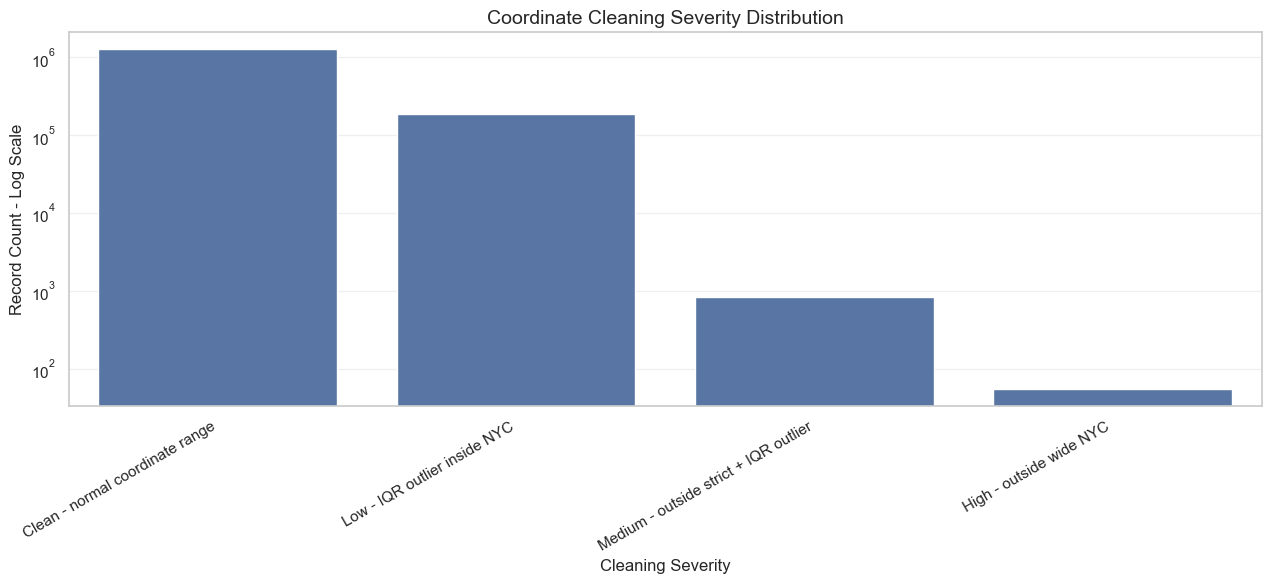

In [103]:
### 5.1.9.7 📊 Coordinate Cleaning Severity Plot

plot_df = coordinate_cleaning_summary.copy()
plot_df["Cleaning Severity"] = plot_df["Cleaning Severity"].astype(str)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=plot_df,
    x="Cleaning Severity",
    y="Record Count"
)

plt.yscale("log")
plt.title("Coordinate Cleaning Severity Distribution")
plt.xlabel("Cleaning Severity")
plt.ylabel("Record Count - Log Scale")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [104]:
### 5.1.9.8 🔎 Review High-risk Coordinate Records

high_risk_coordinate_records = coordinate_df[
    coordinate_df["coordinate_cleaning_severity"].isin([
        "Critical - invalid coordinate",
        "High - outside wide NYC"
    ])
].copy()

review_cols = [
    "id",
    "vendor_id",
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration",
    "coordinate_cleaning_severity",
    "coordinate_cleaning_action",
    "coordinate_diagnostic_flag_count"
]

high_risk_coordinate_review = high_risk_coordinate_records[review_cols].sort_values(
    by=["coordinate_cleaning_severity", "trip_duration"],
    ascending=[True, False]
)

high_risk_coordinate_review.head(30)

,id,vendor_id,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,coordinate_cleaning_severity,coordinate_cleaning_action,coordinate_diagnostic_flag_count
114376,id1311087,1,2016-02-29 12:16:29,-75.4559,39.8039,-73.7960,40.7077,23440,High - outside wide NYC,Strong review / remove candidate,3
1416336,id3795134,1,2016-03-21 20:54:00,-75.2383,39.9230,-73.9226,40.6101,17363,High - outside wide NYC,Strong review / remove candidate,3
1301396,id1216866,1,2016-03-26 22:01:54,-73.9815,40.7733,-76.1357,40.2436,9922,High - outside wide NYC,Strong review / remove candidate,3
14502,id1092161,1,2016-04-15 22:35:08,-73.7818,40.6447,-72.7114,41.3115,7153,High - outside wide NYC,Strong review / remove candidate,3
837898,id2767862,2,2016-05-17 20:29:57,-73.9769,40.7519,-73.6286,41.4214,7064,High - outside wide NYC,Strong review / remove candidate,3
628028,id0806322,1,2016-04-08 01:05:54,-73.9924,40.7538,-73.7118,41.3606,5947,High - outside wide NYC,Strong review / remove candidate,3
978647,id0687776,2,2016-04-28 20:22:43,-73.9919,40.7510,-72.9123,41.3890,5922,High - outside wide NYC,Strong review / remove candidate,3
1058081,id3411872,1,2016-04-08 16:27:07,-74.0024,40.7399,-73.9009,41.3870,5719,High - outside wide NYC,Strong review / remove candidate,3
512980,id2066082,1,2016-01-25 23:53:17,-73.8777,40.7722,-72.9059,41.3198,5549,High - outside wide NYC,Strong review / remove candidate,3
396966,id3476102,1,2016-02-19 20:03:37,-73.7848,40.6485,-73.6260,41.4808,5323,High - outside wide NYC,Strong review / remove candidate,3


In [105]:
### 5.1.9.9 ⏱️ Trip Duration Summary by Coordinate Cleaning Severity

duration_by_coordinate_severity = (
    coordinate_df
    .groupby("coordinate_cleaning_severity")["trip_duration"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99)
    )
    .reset_index()
)

duration_cols = ["mean", "median", "min", "max", "p90", "p95", "p99"]
duration_by_coordinate_severity[duration_cols] = (
    duration_by_coordinate_severity[duration_cols].round(2)
)

duration_by_coordinate_severity

,coordinate_cleaning_severity,count,mean,median,min,max,p90,p95,p99
0,Clean - normal coordinate range,1267782,818.5500,602.0000,1,2227612,1314.0000,1591.0000,2248.0000
1,High - outside wide NYC,55,2503.8500,782.0000,19,23440,5937.0000,7983.7000,20158.4200
2,Low - IQR outlier inside NYC,189970,1893.1500,1558.0000,1,3526282,3039.0000,3618.0000,4977.0000
3,Medium - outside strict + IQR outlier,837,2437.8600,2246.0000,3,85828,4140.8000,4762.0000,6958.9600


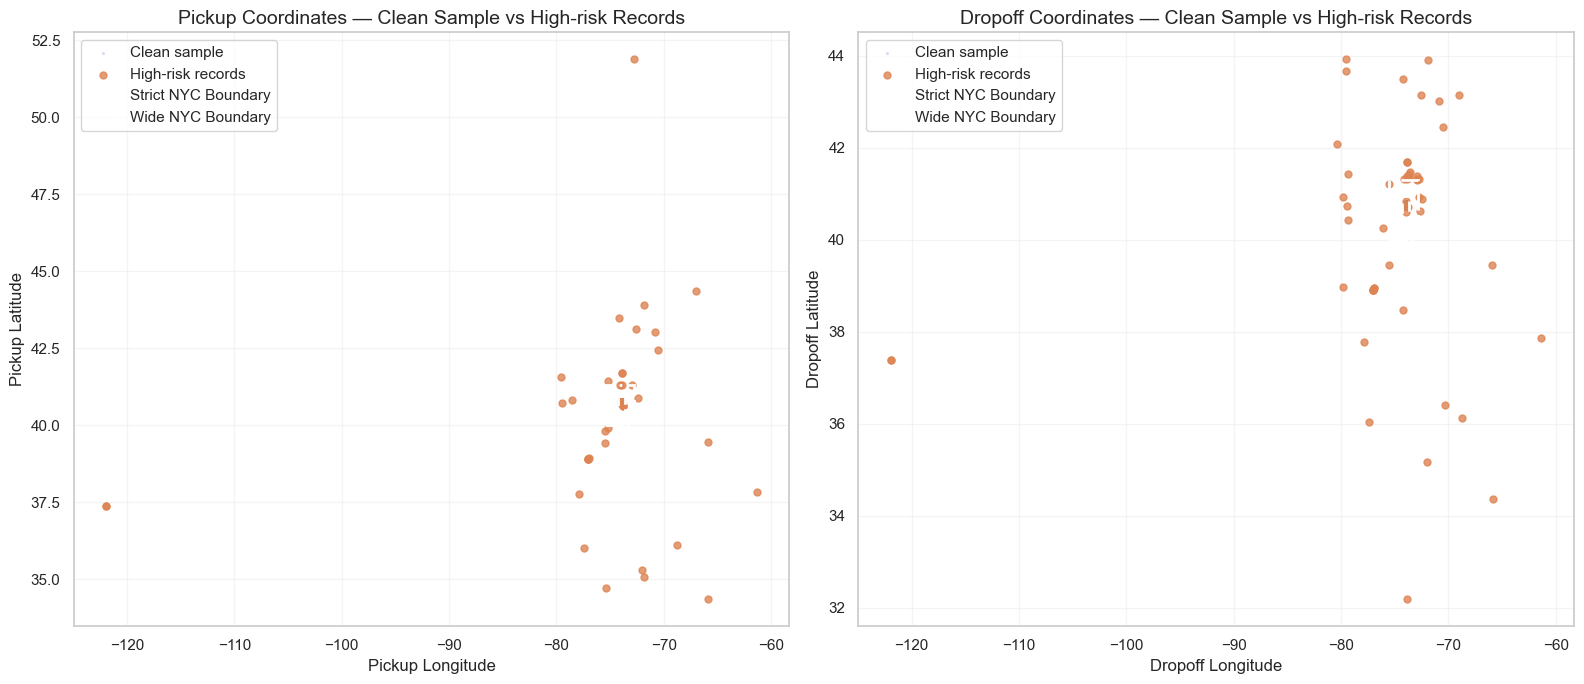

In [106]:
### 5.1.9.10 🗺️ Spatial Review of High-risk Coordinate Records

from matplotlib.patches import Rectangle

def add_boundary_boxes(ax):
    strict_box = Rectangle(
        (strict_lon_min, strict_lat_min),
        strict_lon_max - strict_lon_min,
        strict_lat_max - strict_lat_min,
        fill=False,
        linestyle="--",
        linewidth=2,
        label="Strict NYC Boundary"
    )
    
    wide_box = Rectangle(
        (wide_lon_min, wide_lat_min),
        wide_lon_max - wide_lon_min,
        wide_lat_max - wide_lat_min,
        fill=False,
        linestyle="-.",
        linewidth=2,
        label="Wide NYC Boundary"
    )
    
    ax.add_patch(strict_box)
    ax.add_patch(wide_box)


normal_sample = coordinate_df[
    coordinate_df["coordinate_cleaning_severity"] == "Clean - normal coordinate range"
].sample(
    min(50000, (coordinate_df["coordinate_cleaning_severity"] == "Clean - normal coordinate range").sum()),
    random_state=42
)

high_risk_records = coordinate_df[
    coordinate_df["coordinate_cleaning_severity"].isin([
        "Critical - invalid coordinate",
        "High - outside wide NYC"
    ])
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pickup coordinates
axes[0].scatter(
    normal_sample["pickup_longitude"],
    normal_sample["pickup_latitude"],
    s=2,
    alpha=0.15,
    label="Clean sample"
)

axes[0].scatter(
    high_risk_records["pickup_longitude"],
    high_risk_records["pickup_latitude"],
    s=25,
    alpha=0.8,
    label="High-risk records"
)

add_boundary_boxes(axes[0])

axes[0].set_title("Pickup Coordinates — Clean Sample vs High-risk Records")
axes[0].set_xlabel("Pickup Longitude")
axes[0].set_ylabel("Pickup Latitude")
axes[0].grid(alpha=0.2)
axes[0].legend()

# Dropoff coordinates
axes[1].scatter(
    normal_sample["dropoff_longitude"],
    normal_sample["dropoff_latitude"],
    s=2,
    alpha=0.15,
    label="Clean sample"
)

axes[1].scatter(
    high_risk_records["dropoff_longitude"],
    high_risk_records["dropoff_latitude"],
    s=25,
    alpha=0.8,
    label="High-risk records"
)

add_boundary_boxes(axes[1])

axes[1].set_title("Dropoff Coordinates — Clean Sample vs High-risk Records")
axes[1].set_xlabel("Dropoff Longitude")
axes[1].set_ylabel("Dropoff Latitude")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

In [107]:
### 5.1.9.11 🧹 Final Coordinate Cleaning Rule Preview

coordinate_remove_candidate_mask = (
    coordinate_df["any_globally_invalid_coordinate"] |
    coordinate_df["any_zero_coordinate"] |
    coordinate_df["either_outside_wide_nyc"]
)

coordinate_keep_mask = ~coordinate_remove_candidate_mask

coordinate_rule_preview = pd.DataFrame({
    "Rule": [
        "Total records",
        "Records kept by coordinate rule",
        "Records flagged as coordinate remove candidates"
    ],
    "Count": [
        len(coordinate_df),
        coordinate_keep_mask.sum(),
        coordinate_remove_candidate_mask.sum()
    ]
})

coordinate_rule_preview["Percentage"] = (
    coordinate_rule_preview["Count"] / len(coordinate_df) * 100
).round(4)

coordinate_rule_preview

,Rule,Count,Percentage
0,Total records,1458644,100.0000
1,Records kept by coordinate rule,1458589,99.9962
2,Records flagged as coordinate remove candidates,55,0.0038


In [108]:
### 5.1.9.12 📦 Create Coordinate-clean Candidate Dataset

train_coordinate_clean_candidate = coordinate_df[coordinate_keep_mask].copy()
train_coordinate_remove_candidates = coordinate_df[coordinate_remove_candidate_mask].copy()

print("Original train shape:", train.shape)
print("Coordinate-clean candidate shape:", train_coordinate_clean_candidate.shape)
print("Coordinate remove-candidate shape:", train_coordinate_remove_candidates.shape)
print("Removed candidate percentage:", round(len(train_coordinate_remove_candidates) / len(train) * 100, 4))

Original train shape: (1458644, 12)
Coordinate-clean candidate shape: (1458589, 32)
Coordinate remove-candidate shape: (55, 32)
Removed candidate percentage: 0.0038


### 5.1.9.13 🧠 Summary and Decision from Coordinate Cleaning Candidate Analysis

The coordinate cleaning candidate analysis confirms that most records have valid and geographically reasonable pickup/dropoff coordinates.

The severity distribution shows a clear hierarchy:

- The majority of records fall into the **clean normal coordinate range**.
- A noticeable number of records are marked as **IQR outliers inside NYC**, but these are not necessarily invalid.
- A very small number of records are marked as **outside strict NYC + IQR outlier**.
- Only a tiny number of records fall into the **high-risk outside wide NYC** category.

#### Plot-based Observations

- The severity distribution is highly imbalanced, so log scale was necessary to make rare suspicious groups visible.
- Most records are clean or low-risk.
- The high-risk group is extremely small compared to the full dataset.
- The spatial plot shows that high-risk records are clearly separated from the normal NYC coordinate cluster.
- Several high-risk pickup/dropoff points are far away from NYC, with longitude/latitude values inconsistent with normal NYC taxi trips.
- These high-risk records are likely caused by GPS noise, incorrect coordinates, or trips outside the intended NYC taxi region.

#### Severity-level Interpretation

| Severity Group | Meaning | Decision |
|---|---|---|
| Clean - normal coordinate range | Coordinates are inside expected normal spatial range | Keep |
| Low - IQR outlier inside NYC | Statistically unusual but geographically valid | Keep |
| Medium - outside strict + IQR outlier | Outside dense NYC region but still possibly valid | Keep but monitor |
| High - outside wide NYC | Clearly far from NYC operational area | Strong removal candidate |

#### Important Insight

The IQR method alone would mark many records as outliers, but the spatial review shows that many of them are still geographically valid.

Therefore:

- IQR outlier status should not be used for direct row removal.
- Strict NYC boundary should not be used for direct row removal.
- Wide NYC boundary is the safest rule for identifying clearly suspicious coordinate records.

#### Final Coordinate Cleaning Decision

Records should be kept if:

- Coordinates are globally valid.
- Coordinates are not zero.
- Pickup and dropoff locations are inside the wide NYC boundary.

Records should be flagged as removal candidates if:

- Any coordinate is globally invalid.
- Any coordinate is zero.
- Pickup or dropoff location is outside the wide NYC boundary.

#### Final Rule

The final coordinate cleaning rule will be:

```python
coordinate_remove_candidate_mask = (
    coordinate_df["any_globally_invalid_coordinate"] |
    coordinate_df["any_zero_coordinate"] |
    coordinate_df["either_outside_wide_nyc"]
)

### 5.2.1 Feature Overview — `passenger_count`

`passenger_count` is a discrete count-based numeric feature.

Although it is stored as a numeric column, it should not be analyzed like a continuous variable because it has a small number of repeated integer values.

In this section, we will check:

- Data type
- Missing values
- Unique values
- Minimum and maximum passenger count
- Most frequent passenger count
- Train-test availability
- Basic distribution shape from summary statistics

In [109]:
train['passenger_count']

0          1
1          1
2          1
3          1
4          1
          ..
1458639    4
1458640    1
1458641    1
1458642    1
1458643    1
Name: passenger_count, Length: 1458644, dtype: int64

In [110]:
### 5.2.1.1 Basic Overview of passenger_count

feature = "passenger_count"

def passenger_count_overview(df, dataset_name):
    series = df[feature]
    
    mode_values = series.mode(dropna=True)
    mode_value = mode_values.iloc[0] if len(mode_values) > 0 else np.nan
    mode_count = (series == mode_value).sum() if pd.notna(mode_value) else np.nan
    
    return {
        "Dataset": dataset_name,
        "Rows": len(df),
        "Data Type": series.dtype,
        "Missing Count": series.isna().sum(),
        "Missing Percentage": round(series.isna().mean() * 100, 4),
        "Unique Count": series.nunique(dropna=True),
        "Unique Values": sorted(series.dropna().unique().tolist()),
        "Minimum": series.min(),
        "Maximum": series.max(),
        "Mean": round(series.mean(), 4),
        "Median": series.median(),
        "Mode": mode_value,
        "Mode Count": mode_count,
        "Mode Percentage": round((mode_count / len(df)) * 100, 4)
    }

passenger_overview_df = pd.DataFrame([
    passenger_count_overview(train, "Train"),
    passenger_count_overview(test, "Test")
])

passenger_overview_df


,Dataset,Rows,Data Type,Missing Count,Missing Percentage,Unique Count,Unique Values,Minimum,Maximum,Mean,Median,Mode,Mode Count,Mode Percentage
0,Train,1458644,int64,0,0.0000,10,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",0,9,1.6645,1.0000,1,1033540,70.8562
1,Test,625134,int64,0,0.0000,8,"[0, 1, 2, 3, 4, 5, 6, 9]",0,9,1.6618,1.0000,1,443447,70.9363


In [111]:
### 5.2.1.2 Feature Type Interpretation

passenger_feature_type = pd.DataFrame({
    "Feature": ["passenger_count"],
    "Raw Data Type": [train["passenger_count"].dtype],
    "Analytical Type": ["Discrete / Count Numeric"],
    "Cardinality Type": ["Low-cardinality numeric"],
    "Expected Nature": ["Integer passenger count"],
    "Primary Analysis Method": ["Frequency and proportion-based analysis"],
    "Not Recommended As": ["Continuous distribution feature"]
})

passenger_feature_type

,Feature,Raw Data Type,Analytical Type,Cardinality Type,Expected Nature,Primary Analysis Method,Not Recommended As
0,passenger_count,int64,Discrete / Count Numeric,Low-cardinality numeric,Integer passenger count,Frequency and proportion-based analysis,Continuous distribution feature


#### 5.2.1.3 Initial Decision from Feature Overview

The initial overview confirms that `passenger_count` is a discrete count-based numeric feature.

#### Key Findings

| Check | Train | Test | Interpretation |
|---|---:|---:|---|
| Rows | 1,458,644 | 625,134 | Dataset sizes are consistent with the original split |
| Data type | `int64` | `int64` | Stored as integer count |
| Missing values | 0 | 0 | No missing-value handling needed |
| Unique values | 10 | 8 | Low-cardinality numeric feature |
| Minimum | 0 | 0 | Zero passenger count exists and needs validation |
| Maximum | 9 | 9 | Very high passenger counts exist but are rare candidates |
| Mean | 1.6645 | 1.6618 | Train and test averages are almost identical |
| Median | 1 | 1 | Most trips are single-passenger trips |
| Mode | 1 | 1 | Single-passenger trip is dominant |
| Mode percentage | 70.8562% | 70.9363% | Strongly similar train-test distribution |

#### Interpretation

`passenger_count` is not suitable for continuous-style univariate analysis.

Although the column is numeric, it behaves like a low-cardinality discrete feature because it contains only a small set of integer values.

The feature is heavily dominated by `passenger_count = 1`, which represents around 71% of both train and test records.  
This indicates that most NYC taxi trips in this dataset are single-passenger trips.

Train and test distributions look stable at the overview level because:

- Mean values are almost identical.
- Median values are identical.
- Mode values are identical.
- Mode percentages are almost identical.
- Minimum and maximum values are the same.

This is a good sign for modeling because the feature does not show obvious train-test drift from the initial summary.

#### Important Data Quality Signals

Two values need further investigation:

| Value | Reason |
|---|---|
| `0` | A taxi trip with zero passengers is suspicious |
| `7`, `8`, `9` | Higher than normal taxi passenger capacity; may be rare or data-entry/GPS/system issue |

Train contains passenger counts:

```text
0, 1, 2, 3, 4, 5, 6, 7, 8, 9

### 5.2.2 Data Quality Check — `passenger_count`

In this section, we will check whether `passenger_count` contains invalid, suspicious, or rare values.

Since `passenger_count` is a discrete count feature, the main quality checks are:

- Missing values
- Infinite values
- Negative values
- Non-integer values
- Zero passenger count
- Normal passenger range
- Very high passenger count
- Train-test value mismatch

For NYC taxi trips, the practical normal range is assumed to be:

```text
1 <= passenger_count <= 6

In [112]:
### 5.2.2.1 Data Quality Check for passenger_count

feature = "passenger_count"

def passenger_count_quality_check(df, dataset_name):
    series = pd.to_numeric(df[feature], errors="coerce")
    
    missing_mask = series.isna()
    infinite_mask = np.isinf(series)
    negative_mask = series < 0
    zero_mask = series == 0
    non_integer_mask = series.notna() & (series % 1 != 0)
    normal_range_mask = series.between(1, 6)
    high_count_mask = series > 6
    
    checks = {
        "Missing values": missing_mask,
        "Infinite values": infinite_mask,
        "Negative values": negative_mask,
        "Non-integer values": non_integer_mask,
        "Zero passenger count": zero_mask,
        "Normal range (1-6)": normal_range_mask,
        "High passenger count (>6)": high_count_mask,
        "Outside normal range": ~normal_range_mask
    }
    
    result = []
    
    for check_name, mask in checks.items():
        count = mask.sum()
        percentage = (count / len(df)) * 100
        
        result.append({
            "Dataset": dataset_name,
            "Check": check_name,
            "Count": count,
            "Percentage": round(percentage, 4)
        })
    
    return pd.DataFrame(result)


passenger_quality_df = pd.concat(
    [
        passenger_count_quality_check(train, "Train"),
        passenger_count_quality_check(test, "Test")
    ],
    axis=0
).reset_index(drop=True)

passenger_quality_df

,Dataset,Check,Count,Percentage
0,Train,Missing values,0,0.0000
1,Train,Infinite values,0,0.0000
2,Train,Negative values,0,0.0000
3,Train,Non-integer values,0,0.0000
4,Train,Zero passenger count,60,0.0041
5,Train,Normal range (1-6),1458579,99.9955
6,Train,High passenger count (>6),5,0.0003
7,Train,Outside normal range,65,0.0045
8,Test,Missing values,0,0.0000
9,Test,Infinite values,0,0.0000


In [113]:
### 5.2.2.2 Compact Quality Risk Summary

def passenger_count_risk_summary(df, dataset_name):
    series = pd.to_numeric(df[feature], errors="coerce")
    
    invalid_mask = (
        series.isna() |
        np.isinf(series) |
        (series < 0) |
        (series.notna() & (series % 1 != 0))
    )
    
    suspicious_zero_mask = series == 0
    suspicious_high_mask = series > 6
    normal_mask = series.between(1, 6)
    
    return {
        "Dataset": dataset_name,
        "Total Records": len(df),
        "Invalid Count": invalid_mask.sum(),
        "Invalid Percentage": round(invalid_mask.mean() * 100, 4),
        "Zero Count": suspicious_zero_mask.sum(),
        "Zero Percentage": round(suspicious_zero_mask.mean() * 100, 4),
        "High Count (>6)": suspicious_high_mask.sum(),
        "High Count Percentage": round(suspicious_high_mask.mean() * 100, 4),
        "Normal Count (1-6)": normal_mask.sum(),
        "Normal Percentage": round(normal_mask.mean() * 100, 4)
    }


passenger_risk_summary = pd.DataFrame([
    passenger_count_risk_summary(train, "Train"),
    passenger_count_risk_summary(test, "Test")
])

passenger_risk_summary

,Dataset,Total Records,Invalid Count,Invalid Percentage,Zero Count,Zero Percentage,High Count (>6),High Count Percentage,Normal Count (1-6),Normal Percentage
0,Train,1458644,0,0.0000,60,0.0041,5,0.0003,1458579,99.9955
1,Test,625134,0,0.0000,23,0.0037,2,0.0003,625109,99.9960


In [114]:
### 5.2.2.3 Train-Test Unique Value Consistency

train_unique_passenger_counts = set(train[feature].dropna().unique())
test_unique_passenger_counts = set(test[feature].dropna().unique())

passenger_value_consistency = pd.DataFrame({
    "Check": [
        "Values present in train",
        "Values present in test",
        "Values present in train but missing in test",
        "Values present in test but missing in train",
        "Common values"
    ],
    "Values": [
        sorted(train_unique_passenger_counts),
        sorted(test_unique_passenger_counts),
        sorted(train_unique_passenger_counts - test_unique_passenger_counts),
        sorted(test_unique_passenger_counts - train_unique_passenger_counts),
        sorted(train_unique_passenger_counts & test_unique_passenger_counts)
    ]
})

passenger_value_consistency

,Check,Values
0,Values present in train,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
1,Values present in test,"[0, 1, 2, 3, 4, 5, 6, 9]"
2,Values present in train but missing in test,"[7, 8]"
3,Values present in test but missing in train,[]
4,Common values,"[0, 1, 2, 3, 4, 5, 6, 9]"


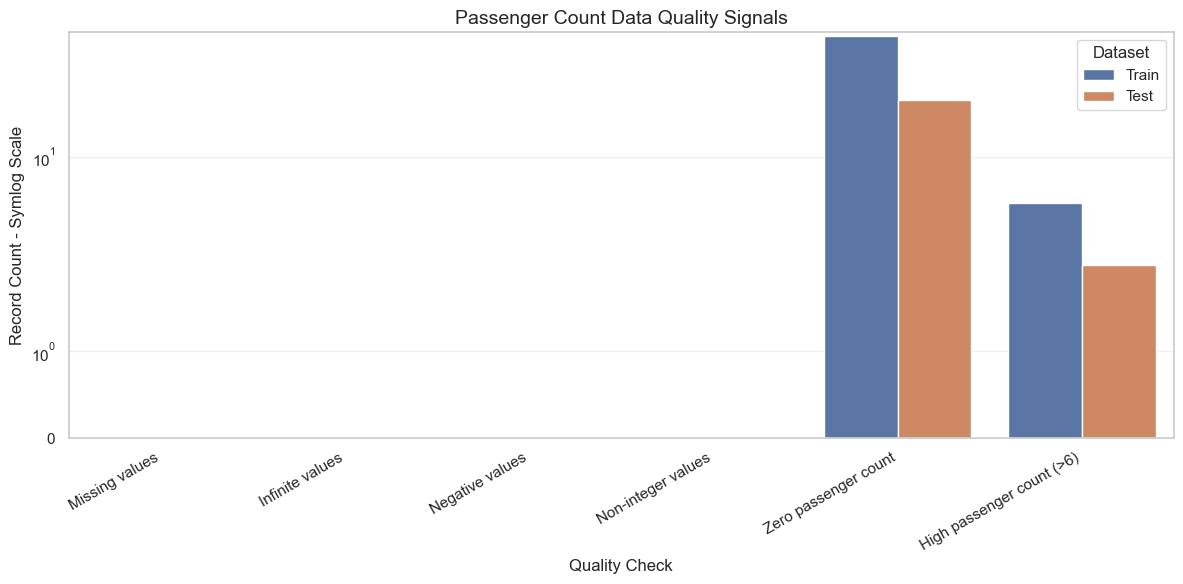

In [115]:
### 5.2.2.4 Passenger Count Quality Signal Plot

quality_plot_df = passenger_quality_df[
    passenger_quality_df["Check"].isin([
        "Missing values",
        "Infinite values",
        "Negative values",
        "Non-integer values",
        "Zero passenger count",
        "High passenger count (>6)"
    ])
].copy()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=quality_plot_df,
    x="Check",
    y="Count",
    hue="Dataset"
)

plt.yscale("symlog")
plt.title("Passenger Count Data Quality Signals")
plt.xlabel("Quality Check")
plt.ylabel("Record Count - Symlog Scale")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [116]:
### 5.2.2.5 Preview Suspicious passenger_count Records

train_passenger_suspicious = train[
    (train[feature] == 0) |
    (train[feature] > 6) |
    (train[feature] < 0) |
    (train[feature].isna())
].copy()

preview_cols = [
    "id",
    "vendor_id",
    "pickup_datetime",
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"
]

train_passenger_suspicious[preview_cols].sort_values(
    by="passenger_count"
).head(30)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
62744,id3917283,2,2016-06-06 16:39:09,0,-73.7764,40.6452,-73.7764,40.6453,85901
136519,id3645383,2,2016-01-01 05:01:32,0,-73.9931,40.7575,-73.9933,40.7575,4
194288,id2840829,2,2016-02-21 01:33:52,0,-73.9462,40.7729,-73.9468,40.7748,155
217765,id3762593,1,2016-01-04 12:24:17,0,-73.8152,40.7001,-73.9507,40.7552,2251
263809,id2154895,1,2016-05-23 23:37:37,0,-73.8616,40.7050,-73.8616,40.7050,8
278290,id0796773,1,2016-02-07 17:23:48,0,-73.9549,40.6879,-73.9547,40.6879,9
301600,id2091096,2,2016-01-01 23:52:46,0,-73.9937,40.7570,-73.9189,40.7578,2072
303133,id0414625,2,2016-01-05 18:52:20,0,-73.9853,40.7383,-73.9854,40.7384,15
337809,id0271506,2,2016-05-22 00:23:15,0,-73.9567,40.7771,-73.9568,40.7770,41
375972,id3176865,2,2016-05-31 05:10:23,0,-73.9825,40.7280,-73.9825,40.7280,15


#### 5.2.2.6 Decision from Passenger Count Data Quality Check

The data quality check shows that `passenger_count` is mostly clean and usable.

#### Main Findings

| Quality Check | Observation | Decision |
|---|---|---|
| Missing values | Not present | No imputation needed |
| Infinite values | Not present | No action needed |
| Negative values | Not present | No invalid negative count issue |
| Non-integer values | Not present | Feature is correctly stored as integer count |
| Zero passenger count | Present in both train and test | Suspicious; flag for review |
| High passenger count `> 6` | Present in both train and test | Rare; flag for review |

#### Interpretation

The plot confirms that there are no structural data quality issues such as missing, infinite, negative, or non-integer values.

The only visible quality concerns are:

- `passenger_count = 0`
- `passenger_count > 6`

Both appear in very small numbers compared to the full dataset.

`passenger_count = 0` is not realistic for a completed taxi trip and is likely a data-entry or system-recording issue.

`passenger_count > 6` is also unusual because it is above the normal passenger capacity range for standard taxi trips. However, these values should not be removed immediately because they may be rare valid cases or recording anomalies.

#### Current Decision

No rows will be removed at this stage.

Instead, the following rules will be carried forward:

| Condition | Status | Action |
|---|---|---|
| `1 <= passenger_count <= 6` | Normal | Keep |
| `passenger_count == 0` | Suspicious | Flag as removal candidate |
| `passenger_count > 6` | Rare / high count | Flag for review |
| Missing / negative / non-integer | Invalid if present | Remove or fix |

#### Final Data Quality Decision

`passenger_count` is valid enough to continue analysis.

The next step should be frequency distribution analysis to check:

- How dominant single-passenger trips are
- How frequent each passenger count value is
- Whether `0`, `7`, `8`, and `9` are rare enough to remove or group
- Whether train and test distributions are consistent

So, `5.2.2` decision is:

> Keep `passenger_count` for modeling, but flag zero and high passenger counts for deeper frequency-based review before final preprocessing.

### 5.2.3 Frequency Distribution — `passenger_count`

In this section, we will analyze the frequency distribution of `passenger_count`.

Since this feature is discrete and low-cardinality, frequency-based analysis is more useful than continuous distribution analysis.

We will check:

- Count of each passenger value
- Percentage share of each value
- Cumulative percentage
- Train and test value coverage
- Dominant and rare passenger count values

In [117]:
### 5.2.3.1 Train Frequency Distribution

feature = "passenger_count"

train_passenger_freq = (
    train[feature]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(feature)
    .reset_index(name="Train Count")
)

train_passenger_freq["Train Percentage"] = (
    train_passenger_freq["Train Count"] / len(train) * 100
).round(4)

train_passenger_freq["Train Cumulative Count"] = train_passenger_freq["Train Count"].cumsum()

train_passenger_freq["Train Cumulative Percentage"] = (
    train_passenger_freq["Train Cumulative Count"] / len(train) * 100
).round(4)

train_passenger_freq

,passenger_count,Train Count,Train Percentage,Train Cumulative Count,Train Cumulative Percentage
0,0,60,0.0041,60,0.0041
1,1,1033540,70.8562,1033600,70.8603
2,2,210318,14.4187,1243918,85.2791
3,3,59896,4.1063,1303814,89.3853
4,4,28404,1.9473,1332218,91.3326
5,5,78088,5.3535,1410306,96.6861
6,6,48333,3.3136,1458639,99.9997
7,7,3,0.0002,1458642,99.9999
8,8,1,0.0001,1458643,99.9999
9,9,1,0.0001,1458644,100.0000


In [118]:
### 5.2.3.2 Test Frequency Distribution

test_passenger_freq = (
    test[feature]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(feature)
    .reset_index(name="Test Count")
)

test_passenger_freq["Test Percentage"] = (
    test_passenger_freq["Test Count"] / len(test) * 100
).round(4)

test_passenger_freq["Test Cumulative Count"] = test_passenger_freq["Test Count"].cumsum()

test_passenger_freq["Test Cumulative Percentage"] = (
    test_passenger_freq["Test Cumulative Count"] / len(test) * 100
).round(4)

test_passenger_freq

,passenger_count,Test Count,Test Percentage,Test Cumulative Count,Test Cumulative Percentage
0,0,23,0.0037,23,0.0037
1,1,443447,70.9363,443470,70.9400
2,2,90027,14.4012,533497,85.3412
3,3,25686,4.1089,559183,89.4501
4,4,12017,1.9223,571200,91.3724
5,5,33411,5.3446,604611,96.7170
6,6,20521,3.2827,625132,99.9997
7,9,2,0.0003,625134,100.0000


In [119]:
### 5.2.3.3 Combined Train-Test Frequency Table

all_passenger_values = sorted(
    set(train[feature].dropna().unique()).union(set(test[feature].dropna().unique()))
)

train_counts = train[feature].value_counts(dropna=False).reindex(all_passenger_values, fill_value=0)
test_counts = test[feature].value_counts(dropna=False).reindex(all_passenger_values, fill_value=0)

passenger_frequency_comparison = pd.DataFrame({
    "passenger_count": all_passenger_values,
    "Train Count": train_counts.values,
    "Train Percentage": (train_counts.values / len(train) * 100),
    "Test Count": test_counts.values,
    "Test Percentage": (test_counts.values / len(test) * 100)
})

passenger_frequency_comparison["Percentage Difference"] = (
    passenger_frequency_comparison["Train Percentage"] -
    passenger_frequency_comparison["Test Percentage"]
)

numeric_cols = [
    "Train Percentage",
    "Test Percentage",
    "Percentage Difference"
]

passenger_frequency_comparison[numeric_cols] = passenger_frequency_comparison[numeric_cols].round(4)

passenger_frequency_comparison

,passenger_count,Train Count,Train Percentage,Test Count,Test Percentage,Percentage Difference
0,0,60,0.0041,23,0.0037,0.0004
1,1,1033540,70.8562,443447,70.9363,-0.0801
2,2,210318,14.4187,90027,14.4012,0.0175
3,3,59896,4.1063,25686,4.1089,-0.0026
4,4,28404,1.9473,12017,1.9223,0.0250
5,5,78088,5.3535,33411,5.3446,0.0089
6,6,48333,3.3136,20521,3.2827,0.0309
7,7,3,0.0002,0,0.0000,0.0002
8,8,1,0.0001,0,0.0000,0.0001
9,9,1,0.0001,2,0.0003,-0.0003


In [120]:
### 5.2.3.4 Dominant and Rare Value Summary

rare_threshold_pct = 0.1

train_freq_ranked = passenger_frequency_comparison.sort_values(
    by="Train Count",
    ascending=False
).copy()

test_freq_ranked = passenger_frequency_comparison.sort_values(
    by="Test Count",
    ascending=False
).copy()

dominant_rare_summary = pd.DataFrame({
    "Metric": [
        "Most common train passenger_count",
        "Most common train passenger_count percentage",
        "Most common test passenger_count",
        "Most common test passenger_count percentage",
        f"Train values below {rare_threshold_pct}% share",
        f"Test values below {rare_threshold_pct}% share",
        "Train values present but missing in test",
        "Test values present but missing in train"
    ],
    "Value": [
        train_freq_ranked.iloc[0]["passenger_count"],
        round(train_freq_ranked.iloc[0]["Train Percentage"], 4),
        test_freq_ranked.iloc[0]["passenger_count"],
        round(test_freq_ranked.iloc[0]["Test Percentage"], 4),
        passenger_frequency_comparison.loc[
            passenger_frequency_comparison["Train Percentage"] < rare_threshold_pct,
            "passenger_count"
        ].tolist(),
        passenger_frequency_comparison.loc[
            passenger_frequency_comparison["Test Percentage"] < rare_threshold_pct,
            "passenger_count"
        ].tolist(),
        passenger_frequency_comparison.loc[
            (passenger_frequency_comparison["Train Count"] > 0) &
            (passenger_frequency_comparison["Test Count"] == 0),
            "passenger_count"
        ].tolist(),
        passenger_frequency_comparison.loc[
            (passenger_frequency_comparison["Test Count"] > 0) &
            (passenger_frequency_comparison["Train Count"] == 0),
            "passenger_count"
        ].tolist()
    ]
})

dominant_rare_summary

,Metric,Value
0,Most common train passenger_count,1.0000
1,Most common train passenger_count percentage,70.8562
2,Most common test passenger_count,1.0000
3,Most common test passenger_count percentage,70.9363
4,Train values below 0.1% share,"[0, 7, 8, 9]"
5,Test values below 0.1% share,"[0, 7, 8, 9]"
6,Train values present but missing in test,"[7, 8]"
7,Test values present but missing in train,[]


#### 5.2.3.6 Decision from Frequency Distribution

The frequency distribution confirms that `passenger_count` is a highly imbalanced low-cardinality count feature.

#### Key Frequency Findings

| Passenger Count | Train % | Test % | Interpretation |
|---:|---:|---:|---|
| 0 | 0.0041% | 0.0037% | Suspicious zero-passenger records |
| 1 | 70.8562% | 70.9363% | Dominant class |
| 2 | 14.4187% | 14.4012% | Second most common |
| 3 | 4.1063% | 4.1089% | Normal but less frequent |
| 4 | 1.9473% | 1.9223% | Normal |
| 5 | 5.3535% | 5.3446% | Normal group/passenger van pattern |
| 6 | 3.3136% | 3.2827% | Normal upper-capacity group |
| 7 | 0.0002% | 0.0000% | Extremely rare; train-only |
| 8 | 0.0001% | 0.0000% | Extremely rare; train-only |
| 9 | 0.0001% | 0.0003% | Extremely rare; present in both train/test pattern as high-count anomaly |

#### Main Interpretation

`passenger_count = 1` dominates the feature, covering around **71%** of both train and test data.

The normal passenger range from `1` to `6` covers almost the entire dataset:

- Train normal range coverage: approximately **99.9956%**
- Test normal range coverage: approximately **99.9960%**

This means the feature is mostly clean and stable.

The suspicious values are very rare:

| Group | Train Count | Test Count | Decision |
|---|---:|---:|---|
| `passenger_count = 0` | 60 | 23 | Suspicious |
| `passenger_count > 6` | 5 | 2 | Extremely rare / high-count anomaly |

#### Train-Test Consistency

Train and test distributions are strongly aligned.

Important points:

- The dominant value is `1` in both train and test.
- Mean, median, and mode were already very similar in the overview.
- Percentage differences across normal values are very small.
- No passenger count value appears only in test.
- `7` and `8` appear only in train, but their counts are extremely small.

This means there is no serious train-test drift for `passenger_count`.

#### Frequency-based Decision

No direct row removal should be applied based only on frequency distribution.

However, the following values should be flagged:

| Condition | Status | Action |
|---|---|---|
| `1 <= passenger_count <= 6` | Normal | Keep |
| `passenger_count == 0` | Suspicious | Flag as removal/imputation candidate |
| `passenger_count > 6` | Extremely rare high count | Flag for review or group as `6+` |
| `7` and `8` train-only values | Very rare | Not a train-test drift concern |

#### Modeling Decision

For tree-based models, `passenger_count` can be kept as a numeric discrete feature.

For linear models or encoded pipelines, it may be better to create grouped features later:

- `is_single_passenger`
- `is_group_trip`
- `is_large_group`
- `passenger_count_grouped`
- `passenger_count_is_zero`
- `passenger_count_gt_6`

#### Current Final Decision

`passenger_count` is usable for modeling.

The feature should be carried forward, but suspicious values should be handled during preprocessing:

- `passenger_count = 0`: review and likely remove or impute
- `passenger_count > 6`: review, group as `6+`, or flag
- `1–6`: keep as valid passenger counts

The next step is to visualize the distribution to make the dominance and rare values easier to interpret.

### 5.2.4 Passenger Count Distribution Visualization

In this section, we will visualize the distribution of `passenger_count`.

Since `passenger_count` is a low-cardinality discrete feature, bar-based plots are more appropriate than continuous plots such as KDE or normal distribution plots.

We will use:

- Count bar plot
- Percentage bar plot
- Train-test percentage comparison plot
- Log-scale count plot for rare values

These visualizations will help confirm whether suspicious values such as `0`, `7`, `8`, and `9` are rare compared to normal passenger counts.

In [121]:
### 5.2.4.1 Prepare Passenger Count Plot Data

feature = "passenger_count"

# Recreate combined frequency table if needed
all_passenger_values = sorted(
    set(train[feature].dropna().unique()).union(set(test[feature].dropna().unique()))
)

train_counts = train[feature].value_counts(dropna=False).reindex(all_passenger_values, fill_value=0)
test_counts = test[feature].value_counts(dropna=False).reindex(all_passenger_values, fill_value=0)

passenger_plot_df = pd.DataFrame({
    "passenger_count": all_passenger_values,
    "Train Count": train_counts.values,
    "Train Percentage": train_counts.values / len(train) * 100,
    "Test Count": test_counts.values,
    "Test Percentage": test_counts.values / len(test) * 100
})

passenger_plot_df["Train Percentage"] = passenger_plot_df["Train Percentage"].round(4)
passenger_plot_df["Test Percentage"] = passenger_plot_df["Test Percentage"].round(4)

passenger_plot_df

,passenger_count,Train Count,Train Percentage,Test Count,Test Percentage
0,0,60,0.0041,23,0.0037
1,1,1033540,70.8562,443447,70.9363
2,2,210318,14.4187,90027,14.4012
3,3,59896,4.1063,25686,4.1089
4,4,28404,1.9473,12017,1.9223
5,5,78088,5.3535,33411,5.3446
6,6,48333,3.3136,20521,3.2827
7,7,3,0.0002,0,0.0000
8,8,1,0.0001,0,0.0000
9,9,1,0.0001,2,0.0003


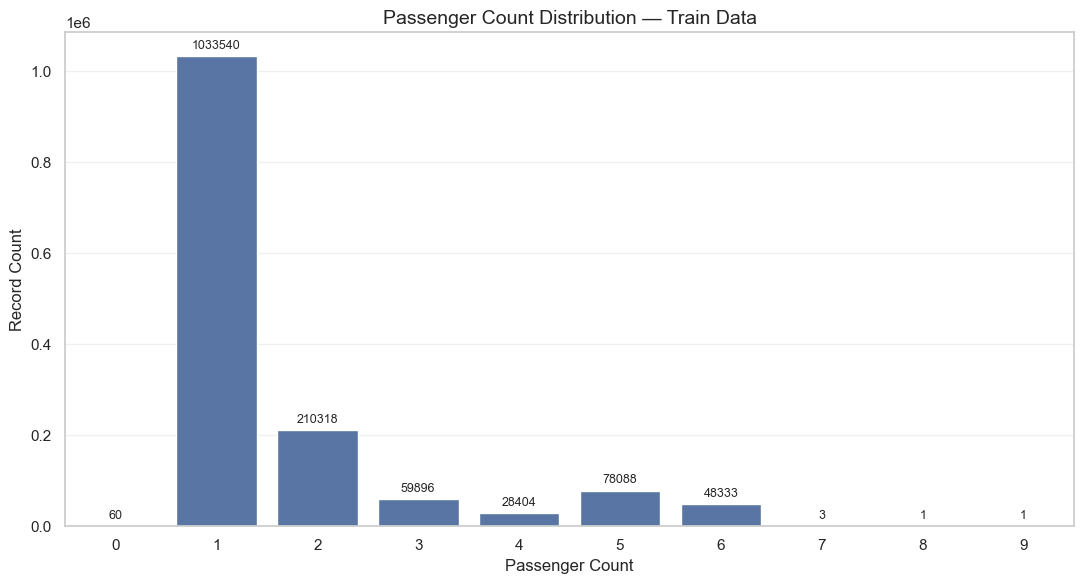

In [122]:
### 5.2.4.2 Passenger Count Distribution in Train Data

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=passenger_plot_df,
    x="passenger_count",
    y="Train Count"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", padding=3, fontsize=9)

plt.title("Passenger Count Distribution — Train Data")
plt.xlabel("Passenger Count")
plt.ylabel("Record Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

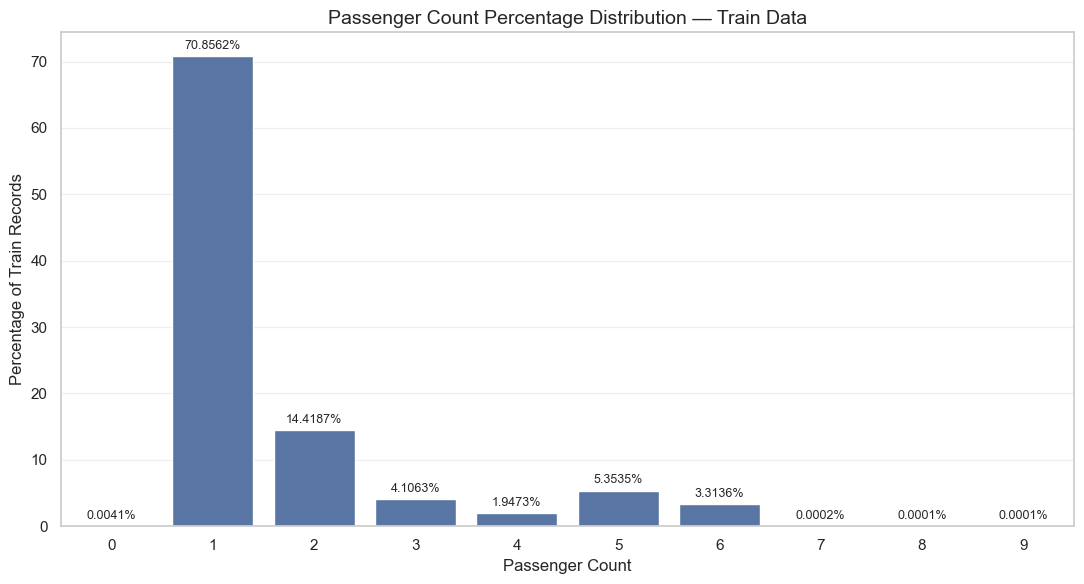

In [123]:
### 5.2.4.3 Passenger Count Percentage Distribution in Train Data

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=passenger_plot_df,
    x="passenger_count",
    y="Train Percentage"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f%%", label_type="edge", padding=3, fontsize=9)

plt.title("Passenger Count Percentage Distribution — Train Data")
plt.xlabel("Passenger Count")
plt.ylabel("Percentage of Train Records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

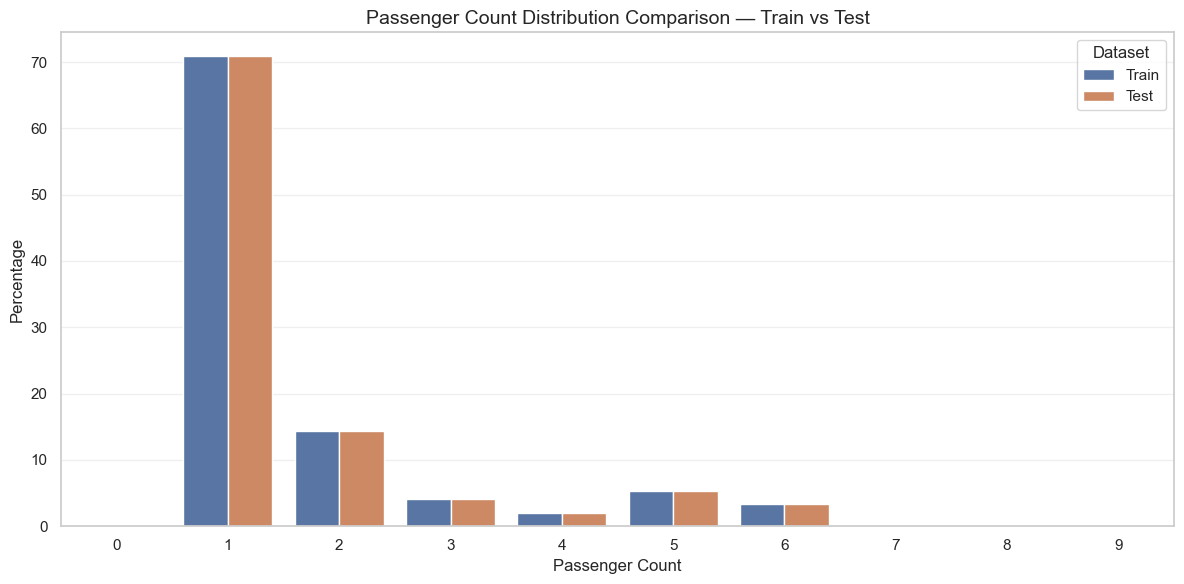

In [124]:
### 5.2.4.4 Train vs Test Passenger Count Percentage Comparison

comparison_plot_df = passenger_plot_df.melt(
    id_vars="passenger_count",
    value_vars=["Train Percentage", "Test Percentage"],
    var_name="Dataset",
    value_name="Percentage"
)

comparison_plot_df["Dataset"] = comparison_plot_df["Dataset"].str.replace(
    " Percentage", "", regex=False
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_plot_df,
    x="passenger_count",
    y="Percentage",
    hue="Dataset"
)

plt.title("Passenger Count Distribution Comparison — Train vs Test")
plt.xlabel("Passenger Count")
plt.ylabel("Percentage")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

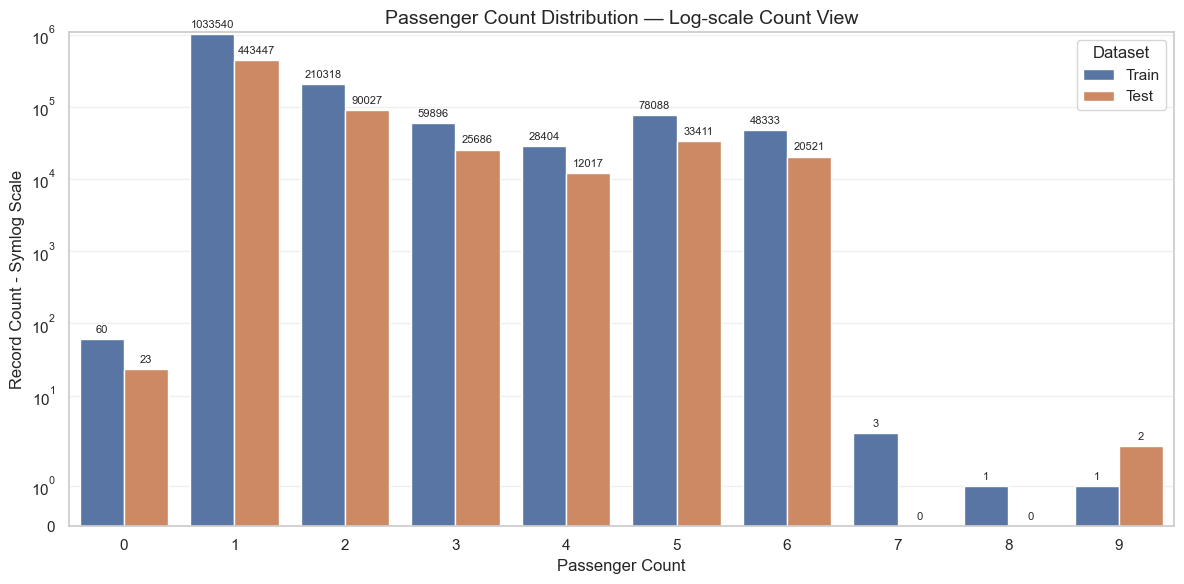

In [125]:
### 5.2.4.5 Log-scale Passenger Count Distribution

log_plot_df = passenger_plot_df.melt(
    id_vars="passenger_count",
    value_vars=["Train Count", "Test Count"],
    var_name="Dataset",
    value_name="Count"
)

log_plot_df["Dataset"] = log_plot_df["Dataset"].str.replace(
    " Count", "", regex=False
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=log_plot_df,
    x="passenger_count",
    y="Count",
    hue="Dataset"
)

plt.yscale("symlog")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", padding=3, fontsize=8)

plt.title("Passenger Count Distribution — Log-scale Count View")
plt.xlabel("Passenger Count")
plt.ylabel("Record Count - Symlog Scale")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

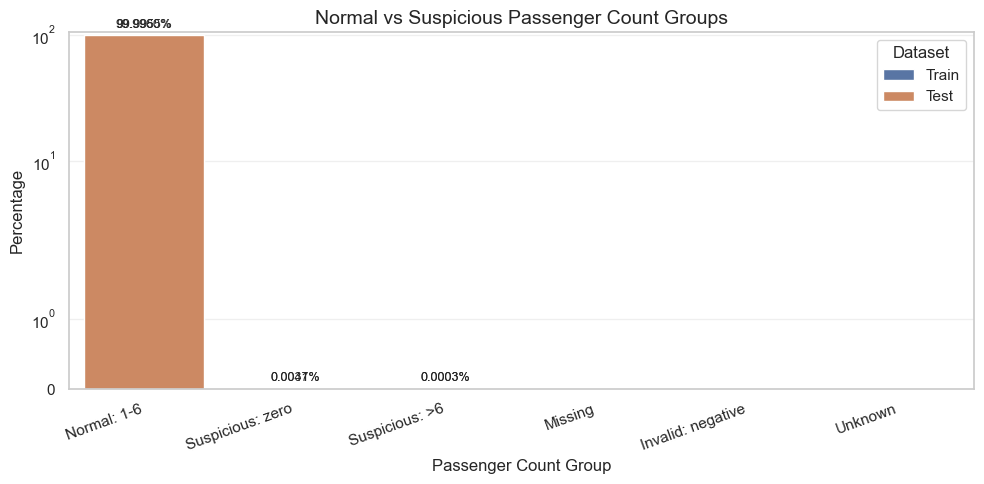

,Passenger Count Group,Train Count,Test Count,Train Percentage,Test Percentage
0,Normal: 1-6,1458579,625109,99.9955,99.9960
1,Suspicious: zero,60,23,0.0041,0.0037
2,Suspicious: >6,5,2,0.0003,0.0003


In [126]:
### 5.2.4.6 Normal vs Suspicious Passenger Count Grouping — Fixed Version

def passenger_count_group(value):
    if pd.isna(value):
        return "Missing"
    if value < 0:
        return "Invalid: negative"
    if value == 0:
        return "Suspicious: zero"
    if 1 <= value <= 6:
        return "Normal: 1-6"
    if value > 6:
        return "Suspicious: >6"
    return "Unknown"


train_passenger_group = train[feature].apply(passenger_count_group)
test_passenger_group = test[feature].apply(passenger_count_group)

# Build count table with explicit index name
group_plot_df = (
    pd.concat(
        [
            train_passenger_group.value_counts().rename("Train Count"),
            test_passenger_group.value_counts().rename("Test Count")
        ],
        axis=1
    )
    .fillna(0)
    .rename_axis("Passenger Count Group")
    .reset_index()
)

group_plot_df["Train Count"] = group_plot_df["Train Count"].astype(int)
group_plot_df["Test Count"] = group_plot_df["Test Count"].astype(int)

group_plot_df["Train Percentage"] = (
    group_plot_df["Train Count"] / len(train) * 100
).round(4)

group_plot_df["Test Percentage"] = (
    group_plot_df["Test Count"] / len(test) * 100
).round(4)

# Keep logical order
group_order = [
    "Normal: 1-6",
    "Suspicious: zero",
    "Suspicious: >6",
    "Missing",
    "Invalid: negative",
    "Unknown"
]

group_plot_df["Passenger Count Group"] = pd.Categorical(
    group_plot_df["Passenger Count Group"],
    categories=group_order,
    ordered=True
)

group_plot_df = group_plot_df.sort_values("Passenger Count Group")

group_percentage_plot_df = group_plot_df.melt(
    id_vars="Passenger Count Group",
    value_vars=["Train Percentage", "Test Percentage"],
    var_name="Dataset",
    value_name="Percentage"
)

group_percentage_plot_df["Dataset"] = group_percentage_plot_df["Dataset"].str.replace(
    " Percentage", "",
    regex=False
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=group_percentage_plot_df,
    x="Passenger Count Group",
    y="Percentage",
    hue="Dataset"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f%%", label_type="edge", padding=3, fontsize=9)

plt.title("Normal vs Suspicious Passenger Count Groups")
plt.xlabel("Passenger Count Group")
plt.ylabel("Percentage")
plt.yscale("symlog")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

group_plot_df

#### 5.2.4.7 Manual Summary and Decision from Passenger Count Visualizations

The passenger count visualizations confirm that `passenger_count` is a strongly imbalanced discrete feature.

#### Visual Findings

| Observation | Evidence | Interpretation |
|---|---|---|
| Single-passenger trips dominate | `passenger_count = 1` has the largest bar in both count and percentage plots | Most taxi trips are single-passenger trips |
| Normal values dominate | `1–6` passenger counts cover almost all records | The feature is mostly clean |
| Zero passenger values exist | `0` appears in both train and test but with very small count | Suspicious data-quality issue |
| High passenger counts are extremely rare | `7`, `8`, and `9` appear only as tiny bars in log-scale view | Rare high-count anomalies |
| Train-test distributions are very similar | Train/test bars overlap closely for values `1–6` | No strong distribution drift |
| Rare values need log-scale | Normal scale hides `0`, `7`, `8`, `9` | Rare values exist but are negligible in proportion |

#### Numeric Evidence from Plots

| Passenger Count | Train Count | Test Count | Train % | Interpretation |
|---:|---:|---:|---:|---|
| 0 | 60 | 23 | 0.0041% | Suspicious zero-passenger records |
| 1 | 1,033,540 | 443,447 | 70.8562% | Dominant value |
| 2 | 210,318 | 90,027 | 14.4187% | Common |
| 3 | 59,896 | 25,686 | 4.1063% | Normal |
| 4 | 28,404 | 12,017 | 1.9473% | Normal |
| 5 | 78,088 | 33,411 | 5.3535% | Normal group trips |
| 6 | 48,333 | 20,521 | 3.3136% | Normal upper-capacity trips |
| 7 | 3 | 0 | 0.0002% | Extremely rare train-only value |
| 8 | 1 | 0 | 0.0001% | Extremely rare train-only value |
| 9 | 1 | 2 | 0.0001% | Extremely rare high-count value |

#### Interpretation

The distribution is not continuous and should not be interpreted using KDE, normality, or IQR methods.

The feature behaves like a low-cardinality count variable where frequency and proportion are the most meaningful analysis tools.

The dominance of `passenger_count = 1` means the feature has strong class imbalance, but it is still useful because passenger count may capture trip behavior differences between single-passenger and group trips.

#### Train-Test Stability Decision

The train and test distributions are highly consistent.

There is no meaningful train-test drift because:

- `passenger_count = 1` dominates both datasets.
- Normal values `1–6` have almost identical proportions.
- Rare values are negligible.
- No new important passenger count value appears only in test.

The train-only values `7` and `8` are not a major issue because they occur only a few times.

#### Cleaning Decision

No rows should be removed based only on visualization.

However, the following rules should be carried forward:

| Condition | Status | Action |
|---|---|---|
| `1 <= passenger_count <= 6` | Normal | Keep |
| `passenger_count == 0` | Suspicious | Flag as removal or imputation candidate |
| `passenger_count > 6` | Extremely rare high count | Flag for review or group as `6+` |

#### Modeling Decision

`passenger_count` should be kept for modeling.

Recommended handling:

- For tree-based models: keep as numeric discrete feature.
- For linear models: consider one-hot encoding or grouped categories.
- For feature engineering: create binary/grouped indicators later.

Possible engineered features:

```text
is_single_passenger
is_group_trip
is_large_group
passenger_count_grouped
passenger_count_is_zero
passenger_count_gt_6

### 5.2.5 Passenger Count Dominance and Imbalance Analysis

In this section, we analyze whether the `passenger_count` feature is dominated by one or a few passenger-count values.

This is a univariate analysis because we are only studying the distribution of `passenger_count`.

We will check:

- Which passenger count appears most frequently
- How much percentage each passenger count contributes
- Whether one class dominates the feature
- How quickly cumulative percentage increases
- Whether the feature is balanced or imbalanced+

#### 5.2.5.1 Create Passenger Count Dominance Table

In [127]:
passenger_count_dominance = (
    train["passenger_count"]
    .value_counts(dropna=False)
    .sort_values(ascending=False)
    .reset_index()
)

passenger_count_dominance.columns = ["passenger_count", "count"]

passenger_count_dominance["percentage"] = (
    passenger_count_dominance["count"] / len(train) * 100
).round(4)

passenger_count_dominance["cumulative_count"] = (
    passenger_count_dominance["count"].cumsum()
)

passenger_count_dominance["cumulative_percentage"] = (
    passenger_count_dominance["percentage"].cumsum()
).round(4)

passenger_count_dominance["rank_by_frequency"] = (
    range(1, len(passenger_count_dominance) + 1)
)

passenger_count_dominance["passenger_count_label"] = (
    passenger_count_dominance["passenger_count"].astype(str)
)

passenger_count_dominance

,passenger_count,count,percentage,cumulative_count,cumulative_percentage,rank_by_frequency,passenger_count_label
0,1,1033540,70.8562,1033540,70.8562,1,1
1,2,210318,14.4187,1243858,85.2749,2,2
2,5,78088,5.3535,1321946,90.6284,3,5
3,3,59896,4.1063,1381842,94.7347,4,3
4,6,48333,3.3136,1430175,98.0483,5,6
5,4,28404,1.9473,1458579,99.9956,6,4
6,0,60,0.0041,1458639,99.9997,7,0
7,7,3,0.0002,1458642,99.9999,8,7
8,9,1,0.0001,1458643,100.0000,9,9
9,8,1,0.0001,1458644,100.0001,10,8


#### 5.2.5.2 Sorted Percentage Bar Plot

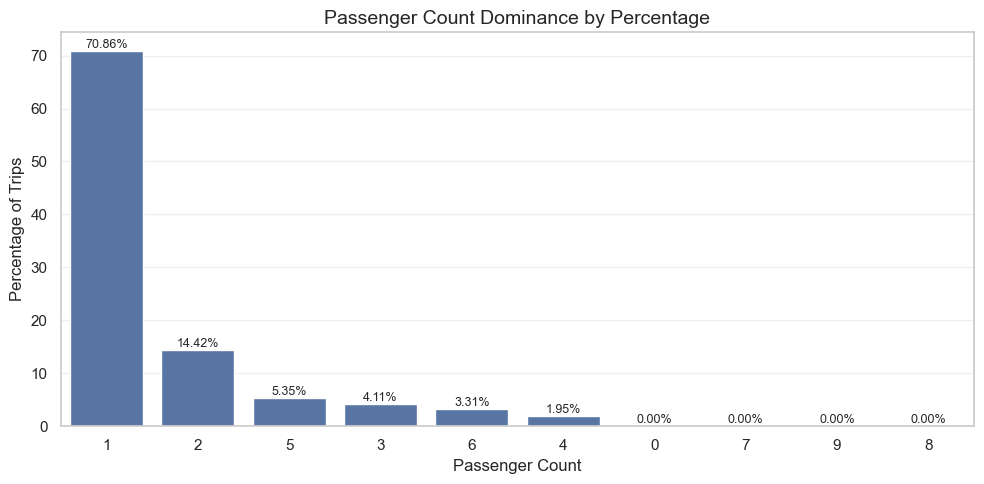

In [128]:
# 5.2.5.2 Sorted Percentage Bar Plot

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=passenger_count_dominance,
    x="passenger_count_label",
    y="percentage"
)

plt.title("Passenger Count Dominance by Percentage")
plt.xlabel("Passenger Count")
plt.ylabel("Percentage of Trips")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", fontsize=9)

plt.tight_layout()
plt.show()

#### 5.2.5.3 Sorted Horizontal Bar Plot

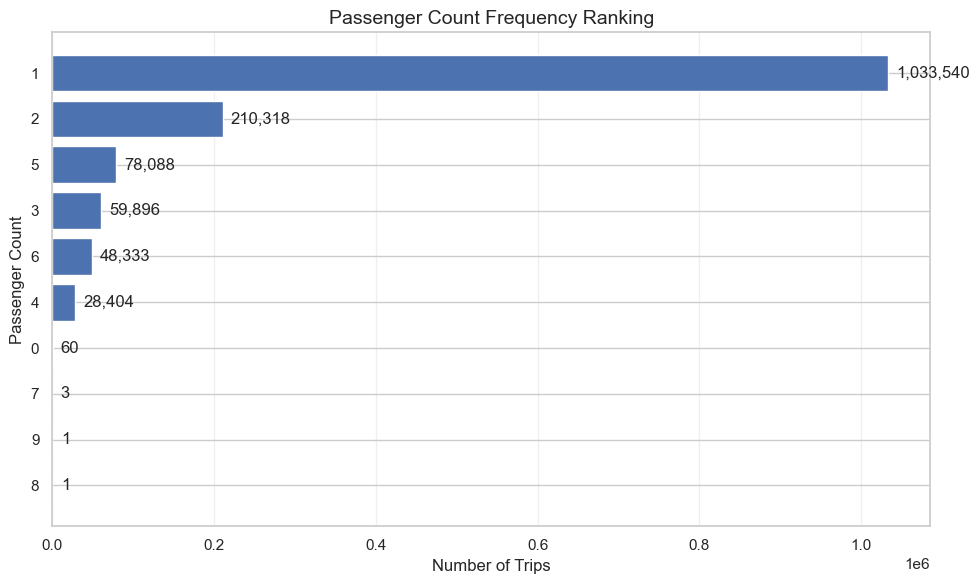

In [129]:
# 5.2.5.3 Sorted Horizontal Bar Plot

horizontal_plot_data = passenger_count_dominance.sort_values(
    by="count",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    horizontal_plot_data["passenger_count_label"],
    horizontal_plot_data["count"]
)

plt.title("Passenger Count Frequency Ranking")
plt.xlabel("Number of Trips")
plt.ylabel("Passenger Count")
plt.grid(axis="x", alpha=0.3)

max_count = horizontal_plot_data["count"].max()

for index, value in enumerate(horizontal_plot_data["count"]):
    plt.text(
        value + max_count * 0.01,
        index,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

#### 5.2.5.4 Pareto Chart: Count + Cumulative Percentage

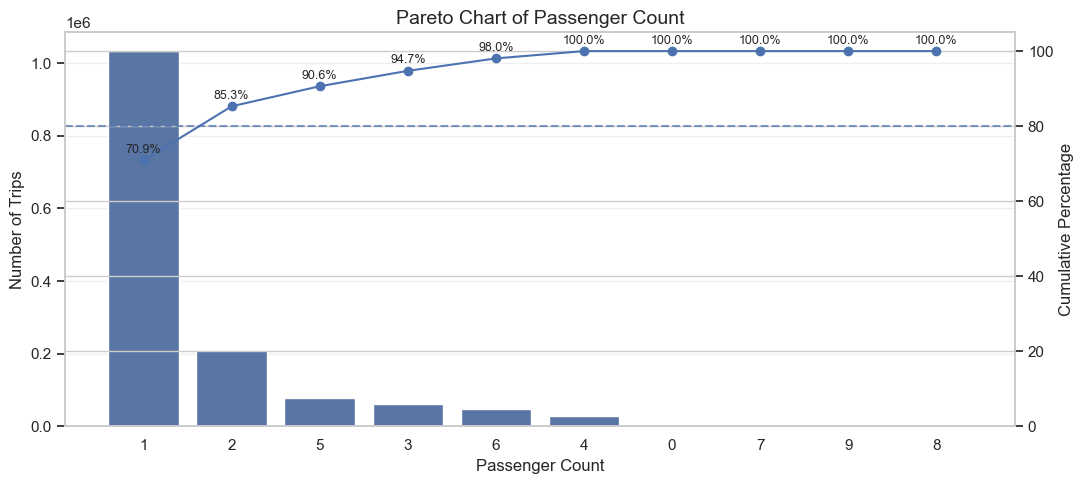

In [130]:
# 5.2.5.4 Pareto Chart: Count and Cumulative Percentage

pareto_data = passenger_count_dominance.sort_values(
    by="count",
    ascending=False
)

fig, ax1 = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=pareto_data,
    x="passenger_count_label",
    y="count",
    ax=ax1
)

ax1.set_title("Pareto Chart of Passenger Count")
ax1.set_xlabel("Passenger Count")
ax1.set_ylabel("Number of Trips")
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    pareto_data["passenger_count_label"],
    pareto_data["cumulative_percentage"],
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage")
ax2.set_ylim(0, 105)

ax2.axhline(
    y=80,
    linestyle="--",
    alpha=0.7
)

for x, y in zip(
    pareto_data["passenger_count_label"],
    pareto_data["cumulative_percentage"]
):
    ax2.text(
        x,
        y + 2,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### 5.2.5.5 Lollipop Chart

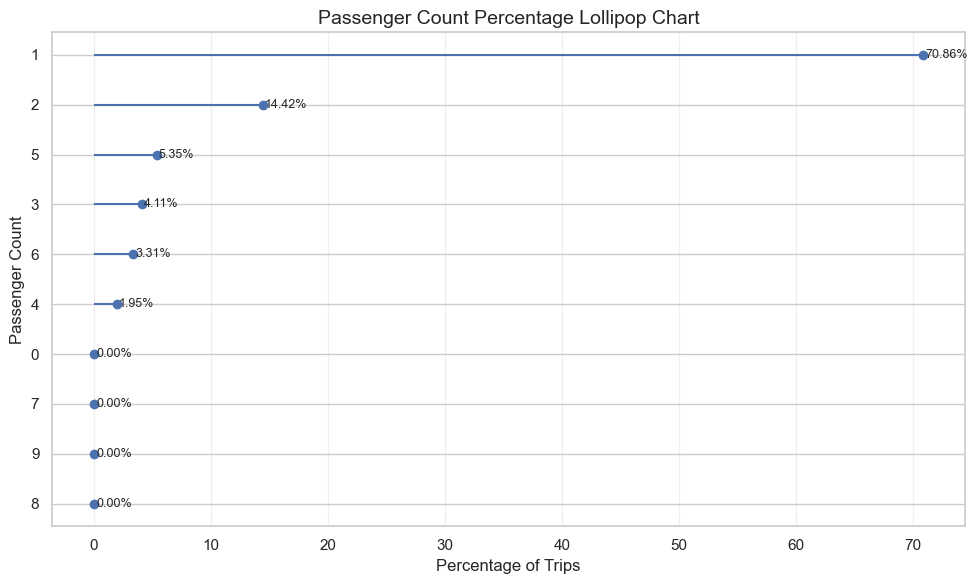

In [131]:
# 5.2.5.5 Lollipop Chart for Passenger Count Percentage

lollipop_data = passenger_count_dominance.sort_values(
    by="percentage",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.hlines(
    y=lollipop_data["passenger_count_label"],
    xmin=0,
    xmax=lollipop_data["percentage"]
)

plt.plot(
    lollipop_data["percentage"],
    lollipop_data["passenger_count_label"],
    "o"
)

plt.title("Passenger Count Percentage Lollipop Chart")
plt.xlabel("Percentage of Trips")
plt.ylabel("Passenger Count")
plt.grid(axis="x", alpha=0.3)

for percentage, label in zip(
    lollipop_data["percentage"],
    lollipop_data["passenger_count_label"]
):
    plt.text(
        percentage + 0.2,
        label,
        f"{percentage:.2f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### 5.2.5.6 Dominance Metrics Summary Table

In [132]:
# 5.2.5.6 Dominance Metrics Summary Table

top_1_value = passenger_count_dominance.iloc[0]["passenger_count"]
top_1_percentage = passenger_count_dominance.iloc[0]["percentage"]

top_2_percentage = passenger_count_dominance.head(2)["percentage"].sum().round(4)
top_3_percentage = passenger_count_dominance.head(3)["percentage"].sum().round(4)

unique_passenger_counts = train["passenger_count"].nunique(dropna=False)

normal_range_percentage = (
    train["passenger_count"].between(1, 6).mean() * 100
).round(4)

zero_passenger_percentage = (
    (train["passenger_count"] == 0).mean() * 100
).round(4)

high_passenger_percentage = (
    (train["passenger_count"] > 6).mean() * 100
).round(4)

dominance_summary = pd.DataFrame({
    "Metric": [
        "Most frequent passenger count",
        "Most frequent passenger count percentage",
        "Top 2 passenger counts coverage",
        "Top 3 passenger counts coverage",
        "Number of unique passenger_count values",
        "Normal range percentage: 1 to 6",
        "Zero passenger percentage",
        "High passenger percentage: greater than 6"
    ],
    "Value": [
        top_1_value,
        f"{top_1_percentage:.4f}%",
        f"{top_2_percentage:.4f}%",
        f"{top_3_percentage:.4f}%",
        unique_passenger_counts,
        f"{normal_range_percentage:.4f}%",
        f"{zero_passenger_percentage:.4f}%",
        f"{high_passenger_percentage:.4f}%"
    ]
})

dominance_summary

,Metric,Value
0,Most frequent passenger count,1
1,Most frequent passenger count percentage,70.8562%
2,Top 2 passenger counts coverage,85.2749%
3,Top 3 passenger counts coverage,90.6284%
4,Number of unique passenger_count values,10
5,Normal range percentage: 1 to 6,99.9955%
6,Zero passenger percentage,0.0041%
7,High passenger percentage: greater than 6,0.0003%


#### 5.2.5.7 Automatic Text Summary

In [133]:
# 5.2.5.7 Automatic Text Summary

dominant_value = passenger_count_dominance.iloc[0]["passenger_count"]
dominant_percentage = passenger_count_dominance.iloc[0]["percentage"]

if dominant_percentage >= 70:
    imbalance_level = "highly imbalanced"
elif dominant_percentage >= 50:
    imbalance_level = "moderately imbalanced"
else:
    imbalance_level = "not strongly imbalanced"

print("Passenger Count Dominance Summary")
print("----------------------------------")
print(f"Most frequent passenger count: {dominant_value}")
print(f"Percentage of most frequent passenger count: {dominant_percentage:.4f}%")
print(f"Imbalance level: {imbalance_level}")
print(f"Normal range percentage (1 to 6): {normal_range_percentage:.4f}%")
print(f"Zero passenger percentage: {zero_passenger_percentage:.4f}%")
print(f"High passenger percentage (>6): {high_passenger_percentage:.4f}%")

Passenger Count Dominance Summary
----------------------------------
Most frequent passenger count: 1
Percentage of most frequent passenger count: 70.8562%
Imbalance level: highly imbalanced
Normal range percentage (1 to 6): 99.9955%
Zero passenger percentage: 0.0041%
High passenger percentage (>6): 0.0003%


#### 5.2.5.8 Decision from Passenger Count Dominance and Imbalance Analysis

From the dominance and imbalance analysis, we can clearly see that `passenger_count` is highly dominated by one value.

The most frequent passenger count is `1`, which represents around **70.86%** of all trips. This means most taxi rides in the dataset are single-passenger rides.

The second most common value is `2`, and the cumulative percentage after passenger counts `1` and `2` reaches around **85.3%**. After adding passenger count `5`, the cumulative coverage becomes around **90.6%**.

The normal passenger-count range from `1` to `6` covers approximately **99.9955%** of the dataset. This confirms that almost all records belong to realistic passenger-count values.

However, there are some suspicious and rare values:

- `passenger_count = 0` appears in only **60 records**, around **0.0041%** of the dataset.
- `passenger_count > 6` appears in only a few records, around **0.0003%** of the dataset.
- These values are extremely rare and should not be treated as normal passenger-count patterns.

So, the feature is highly imbalanced, but this imbalance is not a problem by itself. It is expected that most taxi trips have only one passenger.

Final univariate decision:

- Keep `passenger_count` as a useful feature.
- Treat values from `1` to `6` as the normal passenger-count range.
- Treat `passenger_count = 0` as a suspicious data-quality issue.
- Treat `passenger_count > 6` as rare high-passenger-count anomaly.
- Do not remove any rows in this EDA section.
- Cleaning and transformation decisions will be applied later during preprocessing.

#### 5.2.5.9 Feature Engineering Decision for Passenger Count

Based on the univariate distribution of `passenger_count`, this feature should not be dropped.

Although the feature is highly imbalanced, it still contains useful information about trip type. A single-passenger trip and a group-passenger trip may behave differently later in bivariate or modeling analysis.

For future feature engineering, the following new features can be created:

| New Feature | Logic | Purpose |
|---|---|---|
| `is_single_passenger` | `passenger_count == 1` | Identify single-passenger trips |
| `is_group_trip` | `passenger_count >= 2` and `passenger_count <= 6` | Identify normal group trips |
| `is_zero_passenger` | `passenger_count == 0` | Flag suspicious zero-passenger records |
| `is_high_passenger_count` | `passenger_count > 6` | Flag rare high-count anomalies |
| `passenger_count_group` | zero / single / group / high | Convert raw count into meaningful groups |

Recommended future transformation plan:

- Keep original `passenger_count`.
- Create binary flag features for suspicious and meaningful groups.
- Create a grouped categorical version called `passenger_count_group`.
- Review suspicious values during preprocessing.
- Do not apply final cleaning now because this section is only EDA.

#### 5.2.5.10 Final Summary of Passenger Count Dominance Analysis

The `passenger_count` feature is a low-cardinality discrete numeric feature.

The distribution is highly imbalanced because passenger count `1` dominates the dataset with around **70.86%** of all records. Passenger counts `1` and `2` together cover around **85.3%** of the data, which shows that most taxi trips are taken by one or two passengers.

Almost all records fall inside the normal range of `1` to `6` passengers. This range covers approximately **99.9955%** of the dataset.

Only a very small number of records have suspicious or rare values. There are **60 records** with `passenger_count = 0`, and only a few records with passenger count greater than `6`.

Therefore, the feature is valid and should be kept for modeling. However, suspicious and rare values should be handled carefully during preprocessing or feature engineering.

Final decision:

`passenger_count` will be kept as an input feature, and additional flag/group features will be created later to represent single-passenger trips, group trips, zero-passenger trips, and rare high-passenger-count trips.

### 5.2.6 Final Passenger Count Data Quality and Feature Engineering Decision

In the previous section, we analyzed the dominance and imbalance of the `passenger_count` feature.

The analysis showed that:

- `passenger_count = 1` is the dominant value.
- The normal passenger-count range is from `1` to `6`.
- `passenger_count = 0` is extremely rare and suspicious.
- `passenger_count > 6` is extremely rare and should be treated as an anomaly.

This section converts the EDA findings into clear data-quality and feature-engineering decisions.

No new plots are created here because the distribution has already been analyzed in the previous section.

#### 5.2.6.1 Passenger Count Key Metrics Recap

In [134]:
# 5.2.6.1 Passenger Count Key Metrics Recap

total_records = len(train)

single_passenger_count = (train["passenger_count"] == 1).sum()
single_passenger_percentage = (single_passenger_count / total_records * 100).round(4)

normal_passenger_count = train["passenger_count"].between(1, 6).sum()
normal_passenger_percentage = (normal_passenger_count / total_records * 100).round(4)

zero_passenger_count = (train["passenger_count"] == 0).sum()
zero_passenger_percentage = (zero_passenger_count / total_records * 100).round(4)

high_passenger_count = (train["passenger_count"] > 6).sum()
high_passenger_percentage = (high_passenger_count / total_records * 100).round(4)

passenger_count_metrics_recap = pd.DataFrame({
    "Metric": [
        "Total records",
        "Single-passenger records",
        "Single-passenger percentage",
        "Normal passenger-count records: 1 to 6",
        "Normal passenger-count percentage",
        "Zero-passenger records",
        "Zero-passenger percentage",
        "High passenger-count records: greater than 6",
        "High passenger-count percentage"
    ],
    "Value": [
        f"{total_records:,}",
        f"{single_passenger_count:,}",
        f"{single_passenger_percentage}%",
        f"{normal_passenger_count:,}",
        f"{normal_passenger_percentage}%",
        f"{zero_passenger_count:,}",
        f"{zero_passenger_percentage}%",
        f"{high_passenger_count:,}",
        f"{high_passenger_percentage}%"
    ]
})

passenger_count_metrics_recap

,Metric,Value
0,Total records,"1,458,644"
1,Single-passenger records,"1,033,540"
2,Single-passenger percentage,70.8562%
3,Normal passenger-count records: 1 to 6,"1,458,579"
4,Normal passenger-count percentage,99.9955%
5,Zero-passenger records,60
6,Zero-passenger percentage,0.0041%
7,High passenger-count records: greater than 6,5
8,High passenger-count percentage,0.0003%


### 5.2.6.2 Passenger Count Issue-Action Matrix

In [135]:
# 5.2.6.2 Passenger Count Issue-Action Matrix

passenger_count_issue_action = pd.DataFrame({
    "EDA Finding": [
        "Single passenger is dominant",
        "Normal passenger-count range is very stable",
        "Zero passenger count exists",
        "Passenger count greater than 6 exists",
        "Feature is highly imbalanced"
    ],
    "Evidence": [
        f"passenger_count = 1 covers {single_passenger_percentage}% of records",
        f"passenger_count from 1 to 6 covers {normal_passenger_percentage}% of records",
        f"passenger_count = 0 appears in {zero_passenger_count:,} records",
        f"passenger_count > 6 appears in {high_passenger_count:,} records",
        "One value dominates the feature distribution"
    ],
    "Interpretation": [
        "Expected taxi-trip pattern",
        "Valid passenger-count range",
        "Suspicious data-quality issue",
        "Rare high-count anomaly",
        "Expected imbalance, not necessarily a problem"
    ],
    "EDA Decision": [
        "Keep the feature",
        "Treat 1 to 6 as valid values",
        "Do not remove now; flag for preprocessing",
        "Do not remove now; flag for preprocessing",
        "Keep the feature despite imbalance"
    ]
})

passenger_count_issue_action

,EDA Finding,Evidence,Interpretation,EDA Decision
0,Single passenger is dominant,passenger_count = 1 covers 70.8562% of records,Expected taxi-trip pattern,Keep the feature
1,Normal passenger-count range is very stable,passenger_count from 1 to 6 covers 99.9955% of...,Valid passenger-count range,Treat 1 to 6 as valid values
2,Zero passenger count exists,passenger_count = 0 appears in 60 records,Suspicious data-quality issue,Do not remove now; flag for preprocessing
3,Passenger count greater than 6 exists,passenger_count > 6 appears in 5 records,Rare high-count anomaly,Do not remove now; flag for preprocessing
4,Feature is highly imbalanced,One value dominates the feature distribution,"Expected imbalance, not necessarily a problem",Keep the feature despite imbalance


#### 5.2.6.3 Passenger Count Feature Engineering Plan

In [136]:
# 5.2.6.3 Passenger Count Feature Engineering Plan

passenger_count_feature_plan = pd.DataFrame({
    "Proposed Feature": [
        "passenger_count",
        "is_single_passenger",
        "is_zero_passenger",
        "is_high_passenger_count",
        "passenger_count_group"
    ],
    "Logic": [
        "Original passenger_count value",
        "1 if passenger_count == 1 else 0",
        "1 if passenger_count == 0 else 0",
        "1 if passenger_count > 6 else 0",
        "zero / single / normal_group / high"
    ],
    "Purpose": [
        "Keep original numerical information",
        "Capture dominant single-passenger trip pattern",
        "Flag suspicious zero-passenger records",
        "Flag rare high-count anomaly",
        "Create interpretable grouped passenger categories"
    ],
    "When to Create": [
        "Keep for modeling",
        "During feature engineering",
        "During feature engineering",
        "During feature engineering",
        "During feature engineering"
    ]
})

passenger_count_feature_plan

,Proposed Feature,Logic,Purpose,When to Create
0,passenger_count,Original passenger_count value,Keep original numerical information,Keep for modeling
1,is_single_passenger,1 if passenger_count == 1 else 0,Capture dominant single-passenger trip pattern,During feature engineering
2,is_zero_passenger,1 if passenger_count == 0 else 0,Flag suspicious zero-passenger records,During feature engineering
3,is_high_passenger_count,1 if passenger_count > 6 else 0,Flag rare high-count anomaly,During feature engineering
4,passenger_count_group,zero / single / normal_group / high,Create interpretable grouped passenger categories,During feature engineering


#### 5.2.6.4 Passenger Count Future Transformation Template

In [137]:
# 5.2.6.4 Passenger Count Future Transformation Template
# This code is only a template for the future preprocessing / feature engineering stage.
# It is not applied permanently in this EDA section.

def create_passenger_count_group(value):
    if value == 0:
        return "zero"
    elif value == 1:
        return "single"
    elif 2 <= value <= 6:
        return "normal_group"
    elif value > 6:
        return "high"
    else:
        return "unknown"

passenger_count_transformation_template = pd.DataFrame({
    "Feature": [
        "is_single_passenger",
        "is_zero_passenger",
        "is_high_passenger_count",
        "passenger_count_group"
    ],
    "Example Code": [
        "train['is_single_passenger'] = (train['passenger_count'] == 1).astype(int)",
        "train['is_zero_passenger'] = (train['passenger_count'] == 0).astype(int)",
        "train['is_high_passenger_count'] = (train['passenger_count'] > 6).astype(int)",
        "train['passenger_count_group'] = train['passenger_count'].apply(create_passenger_count_group)"
    ],
    "Apply Now?": [
        "No",
        "No",
        "No",
        "No"
    ],
    "Reason": [
        "Feature engineering will be done later",
        "Suspicious values should be handled carefully later",
        "Rare anomalies should be reviewed later",
        "Grouped categorical feature should be encoded later"
    ]
})

passenger_count_transformation_template

,Feature,Example Code,Apply Now?,Reason
0,is_single_passenger,train['is_single_passenger'] = (train['passeng...,No,Feature engineering will be done later
1,is_zero_passenger,train['is_zero_passenger'] = (train['passenger...,No,Suspicious values should be handled carefully ...
2,is_high_passenger_count,train['is_high_passenger_count'] = (train['pas...,No,Rare anomalies should be reviewed later
3,passenger_count_group,train['passenger_count_group'] = train['passen...,No,Grouped categorical feature should be encoded ...


#### 5.2.6.5 Final Passenger Count Decision Table

In [138]:
# 5.2.6.5 Final Passenger Count Decision Table

passenger_count_final_decision = pd.DataFrame({
    "Decision Area": [
        "Feature usability",
        "Valid value range",
        "Suspicious value",
        "Rare anomaly",
        "Row removal",
        "Future feature engineering",
        "Final modeling decision"
    ],
    "Final Decision": [
        "Useful feature; keep it",
        "1 to 6 passengers",
        "passenger_count = 0",
        "passenger_count > 6",
        "No rows removed during EDA",
        "Create binary flags and grouped feature later",
        "Use passenger_count with engineered support features"
    ]
})

passenger_count_final_decision

,Decision Area,Final Decision
0,Feature usability,Useful feature; keep it
1,Valid value range,1 to 6 passengers
2,Suspicious value,passenger_count = 0
3,Rare anomaly,passenger_count > 6
4,Row removal,No rows removed during EDA
5,Future feature engineering,Create binary flags and grouped feature later
6,Final modeling decision,Use passenger_count with engineered support fe...


#### 5.2.6 Final Decision

The `passenger_count` feature will be kept for future modeling.

The univariate analysis shows that this feature is highly imbalanced, mainly because `passenger_count = 1` dominates the dataset. This is expected for taxi-trip data and does not make the feature invalid.

The valid passenger-count range will be considered from `1` to `6`.

The value `passenger_count = 0` will be treated as a suspicious data-quality issue, while values greater than `6` will be treated as rare high-count anomalies.

No rows will be removed in this EDA section.

During the future preprocessing and feature engineering stage, the following features can be created:

- `is_single_passenger`
- `is_zero_passenger`
- `is_high_passenger_count`
- `passenger_count_group`

Final decision:

`passenger_count` is a valid, useful, low-cardinality numerical feature and should be kept for modeling with additional flag/group features created later.

# 6. Categorical Feature Analysis

This section analyzes the raw categorical variables in the dataset.

The goal is to understand:

- which variables are truly categorical
- which categorical subtype each variable belongs to
- whether categorical features have missing values
- whether categorical features have high or low cardinality
- whether train and test contain the same category labels
- what feature-engineering decision should be made after univariate analysis

Important rule:

This section only performs **univariate categorical analysis**.  
No relationship with `trip_duration` will be analyzed here.  
Feature-target relationship will be handled later in bivariate analysis.

## 6.1 Categorical Feature Overview

This subsection creates the master overview for all raw categorical-like variables.

It separates:

- nominal categorical variables
- binary categorical variables
- ordinal categorical variables
- identifier columns

This prevents treating ID columns or numeric-coded categories incorrectly.

In [139]:
# 6.1.1 Define Categorical Feature Groups

# Raw categorical/model-input categorical features
nominal_categorical_features = ["vendor_id"]
binary_categorical_features = ["store_and_fwd_flag"]
ordinal_categorical_features = []

# Identifier columns are not predictive categorical features
identifier_features = ["id"]

# Final categorical columns to analyze in Section 6
categorical_features = (
    nominal_categorical_features
    + binary_categorical_features
    + ordinal_categorical_features
)

# Safety check: keep only columns that exist in train
categorical_features = [col for col in categorical_features if col in train.columns]
identifier_features = [col for col in identifier_features if col in train.columns]

print("Categorical features for Section 6:", categorical_features)
print("Identifier features excluded from categorical modeling:", identifier_features)

Categorical features for Section 6: ['vendor_id', 'store_and_fwd_flag']
Identifier features excluded from categorical modeling: ['id']


In [140]:
# 6.1.1 Categorical Feature Type Mapping Table

categorical_type_mapping = pd.DataFrame({
    "Feature": ["vendor_id", "store_and_fwd_flag", "id", "Raw ordinal categorical feature"],
    "Raw Data Type in Train": [
        train["vendor_id"].dtype if "vendor_id" in train.columns else "Not found",
        train["store_and_fwd_flag"].dtype if "store_and_fwd_flag" in train.columns else "Not found",
        train["id"].dtype if "id" in train.columns else "Not found",
        "Not available"
    ],
    "Semantic Type": [
        "Categorical",
        "Categorical",
        "Identifier",
        "Not available"
    ],
    "Categorical Subtype": [
        "Nominal categorical",
        "Binary categorical",
        "Identifier / row key",
        "No raw ordinal feature"
    ],
    "Use as Model Input?": [
        "Yes",
        "Yes",
        "No",
        "No"
    ],
    "Reason": [
        "Represents vendor/provider identity; numeric code is only a label",
        "Represents store-and-forward status with two possible labels",
        "Unique row identifier; useful only for tracking/submission",
        "The raw dataset has no natural ordered category column"
    ],
    "Detailed Analysis Section": [
        "6.2",
        "6.3",
        "8.1",
        "6.4"
    ]
})

categorical_type_mapping

,Feature,Raw Data Type in Train,Semantic Type,Categorical Subtype,Use as Model Input?,Reason,Detailed Analysis Section
0,vendor_id,int64,Categorical,Nominal categorical,Yes,Represents vendor/provider identity; numeric c...,6.2
1,store_and_fwd_flag,object,Categorical,Binary categorical,Yes,Represents store-and-forward status with two p...,6.3
2,id,object,Identifier,Identifier / row key,No,Unique row identifier; useful only for trackin...,8.1
3,Raw ordinal categorical feature,Not available,Not available,No raw ordinal feature,No,The raw dataset has no natural ordered categor...,6.4


#### 6.1.1 Decision

Only `vendor_id` and `store_and_fwd_flag` will be analyzed as categorical features in Section 6.

The `id` column will not be treated as a categorical predictor because it is an identifier.  
It will be checked later only for uniqueness and tracking purpose.

No raw ordinal categorical feature exists in this dataset.

### 6.1.2 Categorical Missing Value Overview

This part checks missing values only for raw categorical model-input features.

Features checked:

- `vendor_id`
- `store_and_fwd_flag`

The goal is to decide whether categorical imputation is needed before modeling.

We will use:

1. missing summary table
2. missing percentage comparison plot
3. missing vs non-missing stacked completeness plot
4. missingness matrix for row-level pattern checking

In [142]:
# 6.1.2 Categorical Missing Value Summary

def categorical_missing_summary(train_df, test_df, features):
    rows = []

    for feature in features:
        train_missing = train_df[feature].isna().sum() if feature in train_df.columns else np.nan
        test_missing = test_df[feature].isna().sum() if feature in test_df.columns else np.nan

        train_total = len(train_df) if feature in train_df.columns else np.nan
        test_total = len(test_df) if feature in test_df.columns else np.nan

        train_missing_pct = (train_missing / train_total) * 100 if feature in train_df.columns else np.nan
        test_missing_pct = (test_missing / test_total) * 100 if feature in test_df.columns else np.nan

        rows.append({
            "Feature": feature,
            "Train Missing Count": train_missing,
            "Train Missing %": train_missing_pct,
            "Train Non-Missing Count": train_total - train_missing if feature in train_df.columns else np.nan,
            "Test Missing Count": test_missing,
            "Test Missing %": test_missing_pct,
            "Test Non-Missing Count": test_total - test_missing if feature in test_df.columns else np.nan
        })

    return pd.DataFrame(rows)


categorical_missing_df = categorical_missing_summary(
    train_df=train,
    test_df=test,
    features=categorical_features
)

categorical_missing_df[
    ["Train Missing %", "Test Missing %"]
] = categorical_missing_df[
    ["Train Missing %", "Test Missing %"]
].round(4)

categorical_missing_df

,Feature,Train Missing Count,Train Missing %,Train Non-Missing Count,Test Missing Count,Test Missing %,Test Non-Missing Count
0,vendor_id,0,0.0000,1458644,0,0.0000,625134
1,store_and_fwd_flag,0,0.0000,1458644,0,0.0000,625134


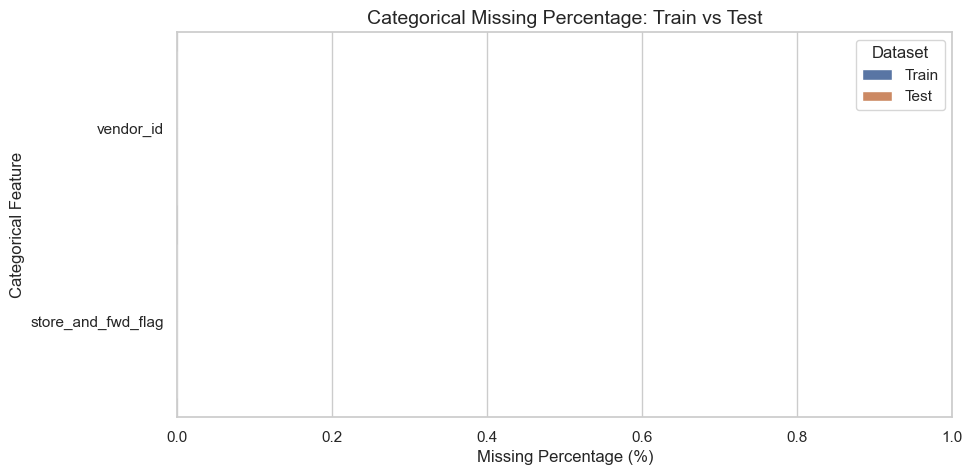

In [ ]:
# 6.1.2 Missing Percentage Comparison Plot

missing_pct_long = categorical_missing_df.melt(
    id_vars="Feature",
    value_vars=["Train Missing %", "Test Missing %"],
    var_name="Dataset",
    value_name="Missing Percentage"
)

missing_pct_long["Dataset"] = missing_pct_long["Dataset"].str.replace(" Missing %", "")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_pct_long,
    y="Feature",
    x="Missing Percentage",
    hue="Dataset"
)

plt.title("Categorical Missing Percentage: Train vs Test")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Categorical Feature")
plt.xlim(0, max(1, missing_pct_long["Missing Percentage"].max() + 0.5))
plt.legend(title="Dataset")
plt.show()

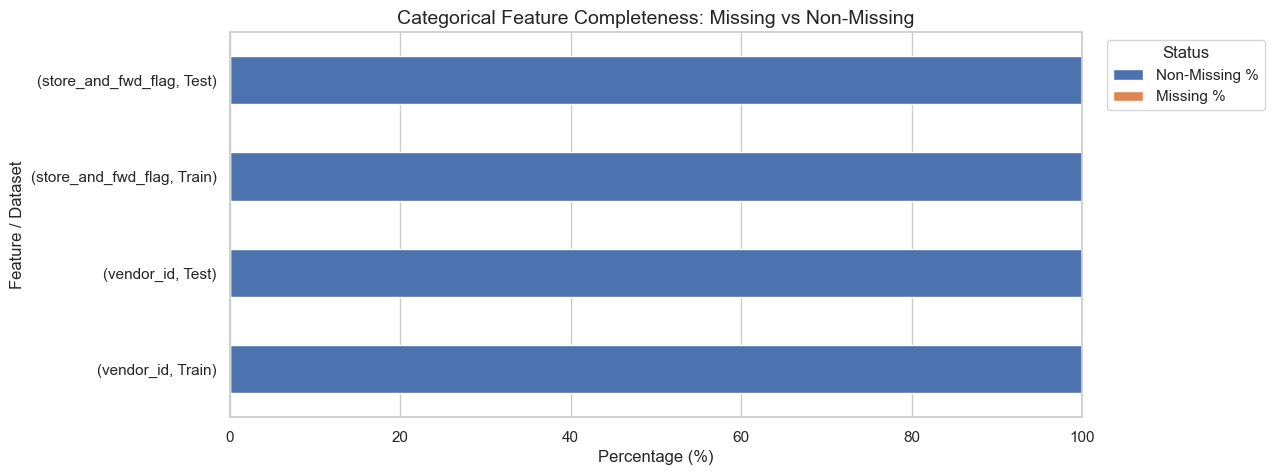

In [144]:
# 6.1.2 Missing vs Non-Missing Completeness Plot

completeness_rows = []

for _, row in categorical_missing_df.iterrows():
    feature = row["Feature"]

    completeness_rows.append({
        "Feature": feature,
        "Dataset": "Train",
        "Missing %": row["Train Missing %"],
        "Non-Missing %": 100 - row["Train Missing %"]
    })

    completeness_rows.append({
        "Feature": feature,
        "Dataset": "Test",
        "Missing %": row["Test Missing %"],
        "Non-Missing %": 100 - row["Test Missing %"]
    })

completeness_df = pd.DataFrame(completeness_rows)

completeness_plot_df = completeness_df.set_index(["Feature", "Dataset"])[
    ["Non-Missing %", "Missing %"]
]

ax = completeness_plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 5)
)

plt.title("Categorical Feature Completeness: Missing vs Non-Missing")
plt.xlabel("Percentage (%)")
plt.ylabel("Feature / Dataset")
plt.xlim(0, 100)
plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

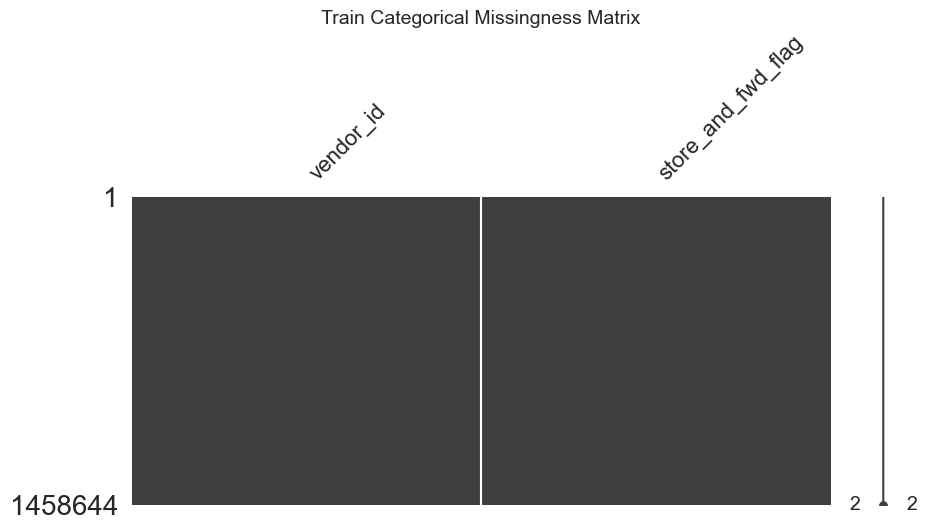

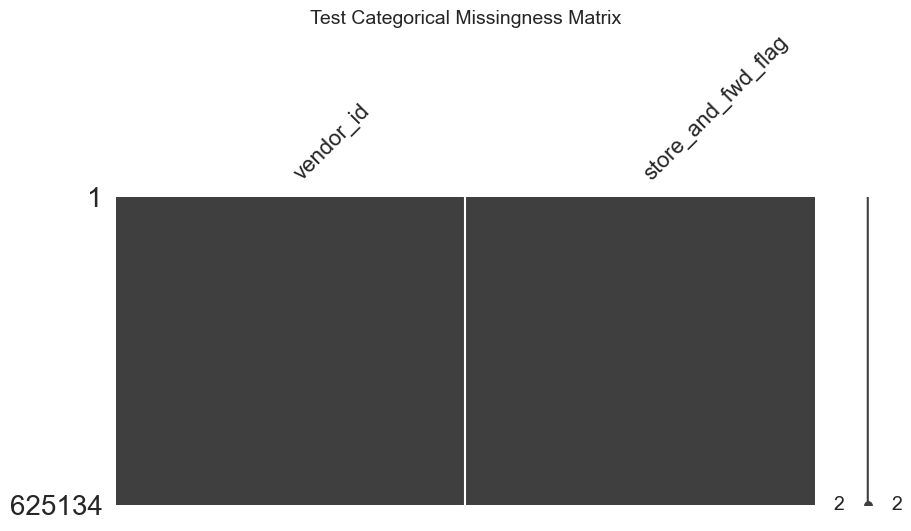

In [145]:
# 6.1.2 Categorical Missingness Matrix

# This plot shows row-level missingness pattern.
# It is useful when missing values exist in multiple categorical columns.

if len(categorical_features) > 0:
    msno.matrix(train[categorical_features], figsize=(10, 4))
    plt.title("Train Categorical Missingness Matrix")
    plt.show()

    msno.matrix(test[categorical_features], figsize=(10, 4))
    plt.title("Test Categorical Missingness Matrix")
    plt.show()
else:
    print("No categorical features available for missingness matrix.")

### 6.1.3 Categorical Cardinality Overview

Cardinality means the number of unique categories in a feature.

This check helps decide the encoding strategy.

General rule:

- Low cardinality: safe for one-hot encoding
- Medium cardinality: one-hot may still work but should be reviewed
- High cardinality: may need special encoding
- Identifier-like: should not be encoded as a categorical feature

This section checks cardinality only for categorical model-input features.  
The `id` column is not analyzed here because it is an identifier and will be handled later.

In [146]:
# 6.1.3 Categorical Cardinality Summary

def classify_cardinality(n_unique):
    if n_unique <= 2:
        return "Binary / very low cardinality"
    elif n_unique <= 10:
        return "Low cardinality"
    elif n_unique <= 50:
        return "Medium cardinality"
    else:
        return "High cardinality"


def encoding_risk(cardinality_type):
    if cardinality_type in ["Binary / very low cardinality", "Low cardinality"]:
        return "Low encoding risk"
    elif cardinality_type == "Medium cardinality":
        return "Moderate encoding risk"
    else:
        return "High encoding risk"


def get_unique_values_as_text(series, max_values=10):
    values = sorted(series.dropna().unique().tolist(), key=lambda x: str(x))

    if len(values) <= max_values:
        return values
    else:
        return values[:max_values] + ["..."]


cardinality_rows = []

for feature in categorical_features:
    train_unique = train[feature].nunique(dropna=True)
    test_unique = test[feature].nunique(dropna=True) if feature in test.columns else np.nan

    card_type = classify_cardinality(train_unique)

    cardinality_rows.append({
        "Feature": feature,
        "Categorical Subtype": (
            "Nominal" if feature in nominal_categorical_features
            else "Binary" if feature in binary_categorical_features
            else "Ordinal"
        ),
        "Train Unique Count": train_unique,
        "Test Unique Count": test_unique,
        "Train Unique Values": get_unique_values_as_text(train[feature]),
        "Test Unique Values": get_unique_values_as_text(test[feature]) if feature in test.columns else "Not found in test",
        "Cardinality Type": card_type,
        "Encoding Risk": encoding_risk(card_type)
    })

categorical_cardinality_df = pd.DataFrame(cardinality_rows)

categorical_cardinality_df

,Feature,Categorical Subtype,Train Unique Count,Test Unique Count,Train Unique Values,Test Unique Values,Cardinality Type,Encoding Risk
0,vendor_id,Nominal,2,2,"[1, 2]","[1, 2]",Binary / very low cardinality,Low encoding risk
1,store_and_fwd_flag,Binary,2,2,"[N, Y]","[N, Y]",Binary / very low cardinality,Low encoding risk


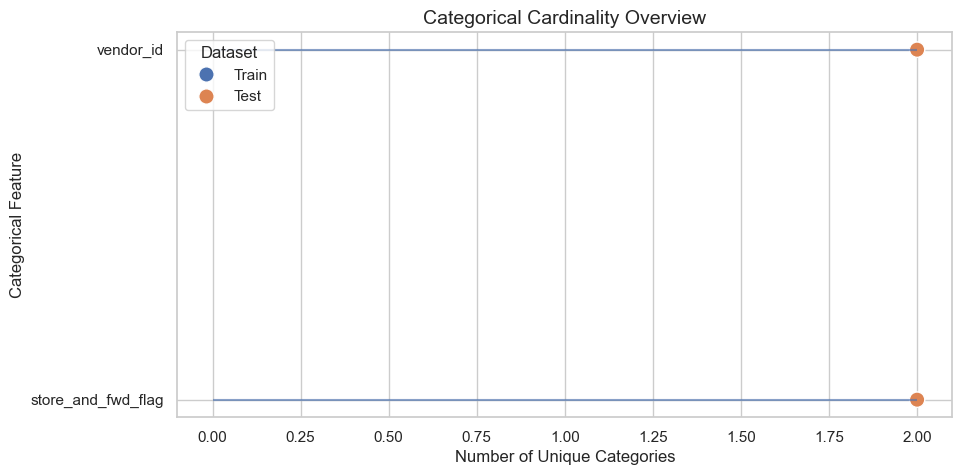

In [147]:
# 6.1.3 Cardinality Lollipop Plot

cardinality_plot_df = categorical_cardinality_df.melt(
    id_vars="Feature",
    value_vars=["Train Unique Count", "Test Unique Count"],
    var_name="Dataset",
    value_name="Unique Count"
)

cardinality_plot_df["Dataset"] = cardinality_plot_df["Dataset"].str.replace(" Unique Count", "")

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=cardinality_plot_df,
    x="Unique Count",
    y="Feature",
    hue="Dataset",
    s=120
)

for _, row in cardinality_plot_df.iterrows():
    plt.hlines(
        y=row["Feature"],
        xmin=0,
        xmax=row["Unique Count"],
        alpha=0.4
    )

plt.title("Categorical Cardinality Overview")
plt.xlabel("Number of Unique Categories")
plt.ylabel("Categorical Feature")
plt.legend(title="Dataset")
plt.show()

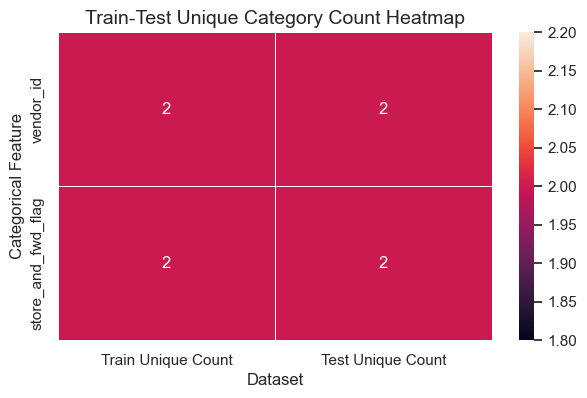

In [148]:
# 6.1.3 Cardinality Heatmap

cardinality_heatmap_df = categorical_cardinality_df.set_index("Feature")[
    ["Train Unique Count", "Test Unique Count"]
]

plt.figure(figsize=(7, 4))

sns.heatmap(
    cardinality_heatmap_df,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Train-Test Unique Category Count Heatmap")
plt.xlabel("Dataset")
plt.ylabel("Categorical Feature")
plt.show()

In [149]:
# 6.1.3 Cardinality Decision

high_cardinality_features = categorical_cardinality_df[
    categorical_cardinality_df["Cardinality Type"] == "High cardinality"
]["Feature"].tolist()

medium_cardinality_features = categorical_cardinality_df[
    categorical_cardinality_df["Cardinality Type"] == "Medium cardinality"
]["Feature"].tolist()

low_cardinality_features = categorical_cardinality_df[
    categorical_cardinality_df["Cardinality Type"].isin([
        "Binary / very low cardinality",
        "Low cardinality"
    ])
]["Feature"].tolist()

cardinality_decision_rows = [
    {
        "Decision Area": "Low-cardinality categorical features",
        "Feature(s)": low_cardinality_features,
        "Decision": "Safe for simple encoding such as one-hot or binary encoding"
    },
    {
        "Decision Area": "Medium-cardinality categorical features",
        "Feature(s)": medium_cardinality_features,
        "Decision": "Review before encoding if any exist"
    },
    {
        "Decision Area": "High-cardinality categorical features",
        "Feature(s)": high_cardinality_features,
        "Decision": "Avoid simple one-hot encoding if any exist"
    }
]

categorical_cardinality_decision = pd.DataFrame(cardinality_decision_rows)

categorical_cardinality_decision

,Decision Area,Feature(s),Decision
0,Low-cardinality categorical features,"[vendor_id, store_and_fwd_flag]",Safe for simple encoding such as one-hot or bi...
1,Medium-cardinality categorical features,[],Review before encoding if any exist
2,High-cardinality categorical features,[],Avoid simple one-hot encoding if any exist


### 6.1.4 Train-Test Category Consistency Overview

This part checks whether train and test contain the same category labels.

This is important because unseen categories in test data can break a normal encoding pipeline.

This section only checks category presence.

It does not compare category relationship with `trip_duration`.

In [150]:
# 6.1.4 Train-Test Category Set Comparison

def compare_train_test_categories(train_df, test_df, features):
    rows = []

    for feature in features:
        if feature not in train_df.columns or feature not in test_df.columns:
            rows.append({
                "Feature": feature,
                "Train Categories": "Column missing",
                "Test Categories": "Column missing",
                "Only in Train": "Not comparable",
                "Only in Test": "Not comparable",
                "Common Categories": "Not comparable",
                "Category Match?": "No",
                "Jaccard Similarity": np.nan
            })
            continue

        train_categories = set(train_df[feature].dropna().astype(str).unique())
        test_categories = set(test_df[feature].dropna().astype(str).unique())

        only_train = sorted(list(train_categories - test_categories))
        only_test = sorted(list(test_categories - train_categories))
        common = sorted(list(train_categories & test_categories))

        union_count = len(train_categories | test_categories)
        jaccard = len(common) / union_count if union_count > 0 else np.nan

        rows.append({
            "Feature": feature,
            "Train Categories": sorted(list(train_categories)),
            "Test Categories": sorted(list(test_categories)),
            "Only in Train": only_train,
            "Only in Test": only_test,
            "Common Categories": common,
            "Category Match?": "Yes" if len(only_train) == 0 and len(only_test) == 0 else "No",
            "Jaccard Similarity": round(jaccard, 4)
        })

    return pd.DataFrame(rows)


category_consistency_df = compare_train_test_categories(
    train_df=train,
    test_df=test,
    features=categorical_features
)

category_consistency_df

,Feature,Train Categories,Test Categories,Only in Train,Only in Test,Common Categories,Category Match?,Jaccard Similarity
0,vendor_id,"[1, 2]","[1, 2]",[],[],"[1, 2]",Yes,1.0000
1,store_and_fwd_flag,"[N, Y]","[N, Y]",[],[],"[N, Y]",Yes,1.0000


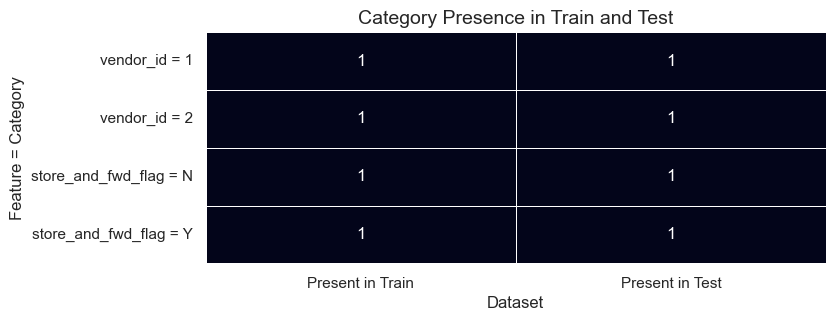

In [151]:
# 6.1.4 Category Presence Heatmap

presence_rows = []

for feature in categorical_features:
    if feature in train.columns and feature in test.columns:
        train_categories = set(train[feature].dropna().astype(str).unique())
        test_categories = set(test[feature].dropna().astype(str).unique())
        all_categories = sorted(list(train_categories | test_categories))

        for category in all_categories:
            presence_rows.append({
                "Feature_Category": f"{feature} = {category}",
                "Present in Train": int(category in train_categories),
                "Present in Test": int(category in test_categories)
            })

category_presence_df = pd.DataFrame(presence_rows)

if len(category_presence_df) > 0:
    category_presence_heatmap = category_presence_df.set_index("Feature_Category")

    plt.figure(figsize=(8, max(3, 0.5 * len(category_presence_heatmap))))

    sns.heatmap(
        category_presence_heatmap,
        annot=True,
        fmt=".0f",
        cbar=False,
        linewidths=0.5
    )

    plt.title("Category Presence in Train and Test")
    plt.xlabel("Dataset")
    plt.ylabel("Feature = Category")
    plt.show()
else:
    print("No category presence data available.")

In [152]:
# 6.1.4 Train-Test Category Consistency Decision

all_categories_match = (
    category_consistency_df["Category Match?"].eq("Yes").all()
    if len(category_consistency_df) > 0
    else False
)

if all_categories_match:
    category_consistency_decision = (
        "Train and test contain the same category labels for categorical model-input features. "
        "No unseen-category problem is expected for basic encoding."
    )
else:
    category_consistency_decision = (
        "Some categorical labels are not shared between train and test. "
        "The encoding pipeline should handle unknown categories safely, "
        "for example using handle_unknown='ignore'."
    )

category_consistency_decision_table = pd.DataFrame({
    "Decision Area": [
        "Train-test category consistency",
        "Encoding safety",
        "Future preprocessing action"
    ],
    "Decision": [
        category_consistency_decision,
        "Encoding should be fitted on train data only",
        "Use safe encoding that can handle unseen categories if mismatch exists"
    ]
})

category_consistency_decision_table

,Decision Area,Decision
0,Train-test category consistency,Train and test contain the same category label...
1,Encoding safety,Encoding should be fitted on train data only
2,Future preprocessing action,Use safe encoding that can handle unseen categ...


#### Final Decision

The categorical overview shows that both model-input categorical features are clean and low-cardinality.

`vendor_id` will be kept as a nominal categorical feature. Although it is stored as numeric values, the numbers represent category labels, not numerical magnitude. Therefore, it should not be treated as a continuous numeric variable. It can be encoded using one-hot encoding or handled as a categorical variable depending on the modeling pipeline.

`store_and_fwd_flag` will be kept as a binary categorical feature. Since the feature contains only `N` and `Y`, it can be converted into a binary flag during preprocessing, where `N = 0` and `Y = 1`.

No missing-value imputation is required for these categorical features because both train and test contain complete values.

No unseen-category issue is observed because train and test contain the same category labels for both categorical variables. However, the final preprocessing pipeline should still be built safely by fitting encoders only on the training data.

The `id` column will not be used as a model input feature. It will be kept only for row tracking and final submission.

No raw ordinal categorical variable exists in this dataset. Any ordinal-style features, such as time-of-day groups or passenger-count groups, should be created later during feature engineering, not in this raw categorical univariate EDA section.

## 6.2 Nominal Categorical Feature Analysis: `vendor_id`

In this section, we analyze `vendor_id` as a nominal categorical feature.

Although `vendor_id` is stored as a numeric value, it represents vendor identity.  
Therefore, it should be analyzed as a category, not as a continuous numerical variable.

This section focuses only on univariate analysis.

We will check:

- category frequency
- category percentage
- train-test distribution similarity
- category dominance
- imbalance ratio
- validity of category labels
- visual distribution patterns

No relationship with `trip_duration` will be analyzed here.

### 6.2.1 Basic Category Frequency

This subsection checks the basic frequency and percentage distribution of `vendor_id` in both train and test data.

The goal is to understand how many records belong to each vendor and whether one vendor dominates the dataset.

In [153]:
# 6.2.1.1 Basic vendor_id frequency table

vendor_feature = "vendor_id"

vendor_train_counts = train[vendor_feature].value_counts(dropna=False).sort_index()
vendor_test_counts = test[vendor_feature].value_counts(dropna=False).sort_index()

vendor_train_pct = train[vendor_feature].value_counts(dropna=False, normalize=True).sort_index() * 100
vendor_test_pct = test[vendor_feature].value_counts(dropna=False, normalize=True).sort_index() * 100

all_vendor_categories = sorted(
    set(vendor_train_counts.index.astype(str)) | set(vendor_test_counts.index.astype(str)),
    key=lambda x: str(x)
)

vendor_frequency_rows = []

for category in all_vendor_categories:
    train_count = vendor_train_counts.get(int(category), vendor_train_counts.get(category, 0))
    test_count = vendor_test_counts.get(int(category), vendor_test_counts.get(category, 0))

    train_percentage = vendor_train_pct.get(int(category), vendor_train_pct.get(category, 0))
    test_percentage = vendor_test_pct.get(int(category), vendor_test_pct.get(category, 0))

    vendor_frequency_rows.append({
        "vendor_id": category,
        "Train Count": train_count,
        "Train %": train_percentage,
        "Test Count": test_count,
        "Test %": test_percentage,
        "Count Difference": train_count - test_count,
        "Percentage Difference": train_percentage - test_percentage
    })

vendor_frequency_df = pd.DataFrame(vendor_frequency_rows)

vendor_frequency_df[["Train %", "Test %", "Percentage Difference"]] = vendor_frequency_df[
    ["Train %", "Test %", "Percentage Difference"]
].round(4)

vendor_frequency_df

,vendor_id,Train Count,Train %,Test Count,Test %,Count Difference,Percentage Difference
0,1,678342,46.5050,290760,46.5116,387582,-0.0067
1,2,780302,53.4950,334374,53.4884,445928,0.0067


In [154]:
# 6.2.1.2 Long-format dataframe for plotting

vendor_plot_df = vendor_frequency_df.melt(
    id_vars="vendor_id",
    value_vars=["Train Count", "Test Count"],
    var_name="Dataset",
    value_name="Count"
)

vendor_plot_df["Dataset"] = vendor_plot_df["Dataset"].str.replace(" Count", "")

vendor_pct_plot_df = vendor_frequency_df.melt(
    id_vars="vendor_id",
    value_vars=["Train %", "Test %"],
    var_name="Dataset",
    value_name="Percentage"
)

vendor_pct_plot_df["Dataset"] = vendor_pct_plot_df["Dataset"].str.replace(" %", "")

display(vendor_plot_df.head())
display(vendor_pct_plot_df.head())

,vendor_id,Dataset,Count
0,1,Train,678342
1,2,Train,780302
2,1,Test,290760
3,2,Test,334374


,vendor_id,Dataset,Percentage
0,1,Train,46.5050
1,2,Train,53.4950
2,1,Test,46.5116
3,2,Test,53.4884


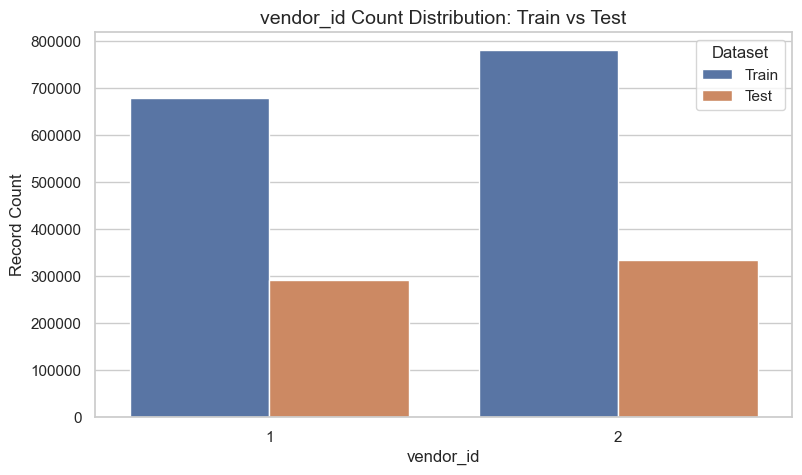

In [155]:
# 6.2.1.3 Vendor raw count comparison plot

plt.figure(figsize=(9, 5))

sns.barplot(
    data=vendor_plot_df,
    x="vendor_id",
    y="Count",
    hue="Dataset"
)

plt.title("vendor_id Count Distribution: Train vs Test")
plt.xlabel("vendor_id")
plt.ylabel("Record Count")
plt.legend(title="Dataset")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

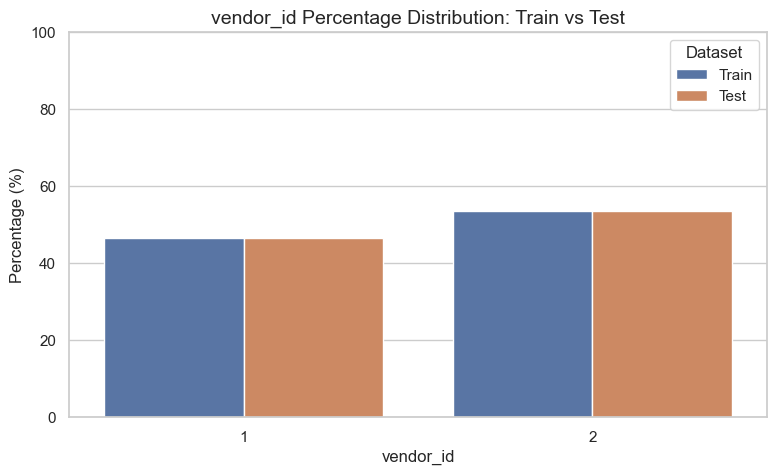

In [156]:
# 6.2.1.4 Vendor percentage comparison plot

plt.figure(figsize=(9, 5))

sns.barplot(
    data=vendor_pct_plot_df,
    x="vendor_id",
    y="Percentage",
    hue="Dataset"
)

plt.title("vendor_id Percentage Distribution: Train vs Test")
plt.xlabel("vendor_id")
plt.ylabel("Percentage (%)")
plt.ylim(0, max(100, vendor_pct_plot_df["Percentage"].max() + 5))
plt.legend(title="Dataset")
plt.show()

### 6.2.2 Vendor Distribution Shape

This subsection uses percentage-based visualizations to understand the share of each vendor.

Because `vendor_id` has low cardinality, percentage-based plots are more useful than numerical distribution plots.

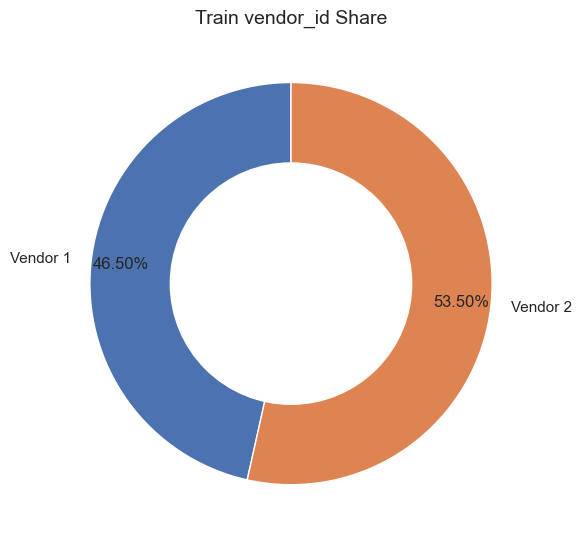

In [157]:
# 6.2.2.1 Donut chart for train vendor distribution

train_vendor_share = train[vendor_feature].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    train_vendor_share.values,
    labels=[f"Vendor {idx}" for idx in train_vendor_share.index],
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.85
)

centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Train vendor_id Share")
plt.tight_layout()
plt.show()

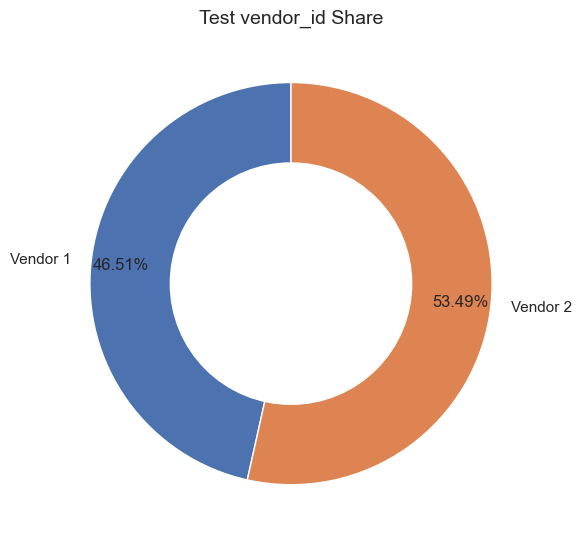

In [158]:
# 6.2.2.2 Donut chart for test vendor distribution

test_vendor_share = test[vendor_feature].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    test_vendor_share.values,
    labels=[f"Vendor {idx}" for idx in test_vendor_share.index],
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.85
)

centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Test vendor_id Share")
plt.tight_layout()
plt.show()

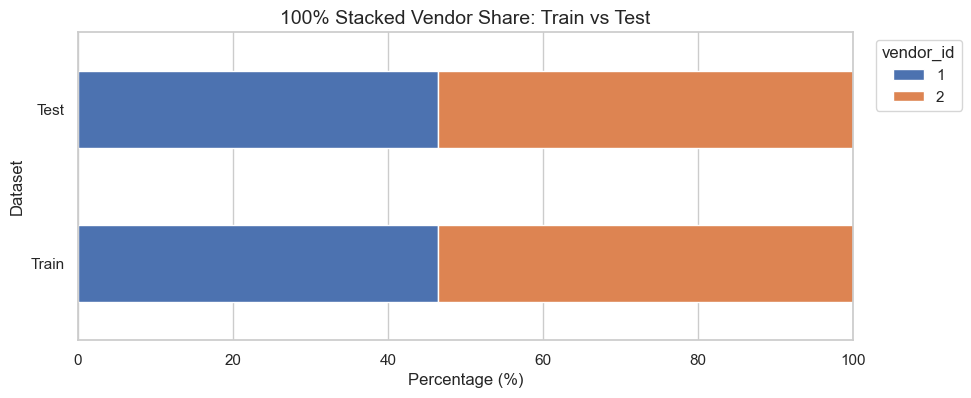

In [159]:
# 6.2.2.3 100% stacked bar chart for train-test vendor share

vendor_stacked_df = vendor_frequency_df.set_index("vendor_id")[["Train %", "Test %"]].T
vendor_stacked_df.index = ["Train", "Test"]

ax = vendor_stacked_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 4)
)

plt.title("100% Stacked Vendor Share: Train vs Test")
plt.xlabel("Percentage (%)")
plt.ylabel("Dataset")
plt.xlim(0, 100)
plt.legend(title="vendor_id", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

### 6.2.3 Train-Test Vendor Distribution Shift

This subsection checks how similar the `vendor_id` distribution is between train and test data.

This is useful because a large train-test distribution shift can reduce model generalization.

In [160]:
# 6.2.3.1 Vendor percentage difference table

vendor_shift_df = vendor_frequency_df[[
    "vendor_id",
    "Train %",
    "Test %",
    "Percentage Difference"
]].copy()

vendor_shift_df["Absolute Percentage Difference"] = vendor_shift_df["Percentage Difference"].abs()
vendor_shift_df = vendor_shift_df.sort_values(
    by="Absolute Percentage Difference",
    ascending=False
).reset_index(drop=True)

vendor_shift_df

,vendor_id,Train %,Test %,Percentage Difference,Absolute Percentage Difference
0,1,46.5050,46.5116,-0.0067,0.0067
1,2,53.4950,53.4884,0.0067,0.0067


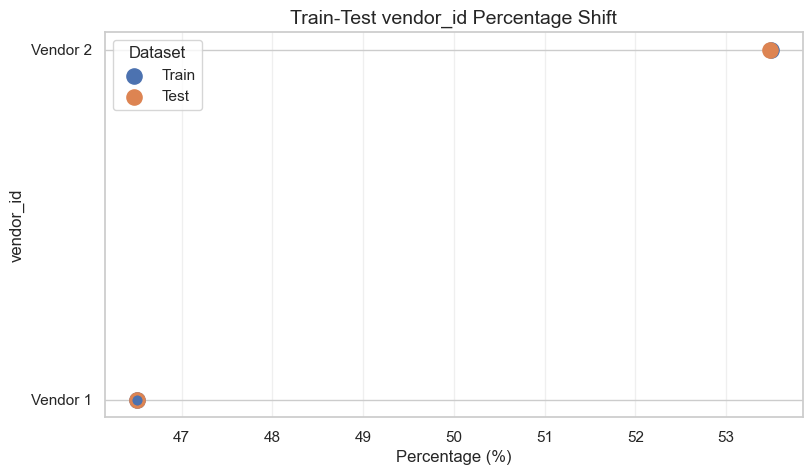

In [161]:
# 6.2.3.2 Dumbbell plot for train-test vendor percentage shift

dumbbell_df = vendor_frequency_df.copy()
dumbbell_df["vendor_id_label"] = "Vendor " + dumbbell_df["vendor_id"].astype(str)

plt.figure(figsize=(9, 5))

for _, row in dumbbell_df.iterrows():
    plt.plot(
        [row["Train %"], row["Test %"]],
        [row["vendor_id_label"], row["vendor_id_label"]],
        marker="o"
    )

plt.scatter(
    dumbbell_df["Train %"],
    dumbbell_df["vendor_id_label"],
    s=120,
    label="Train"
)

plt.scatter(
    dumbbell_df["Test %"],
    dumbbell_df["vendor_id_label"],
    s=120,
    label="Test"
)

plt.title("Train-Test vendor_id Percentage Shift")
plt.xlabel("Percentage (%)")
plt.ylabel("vendor_id")
plt.legend(title="Dataset")
plt.grid(axis="x", alpha=0.3)
plt.show()

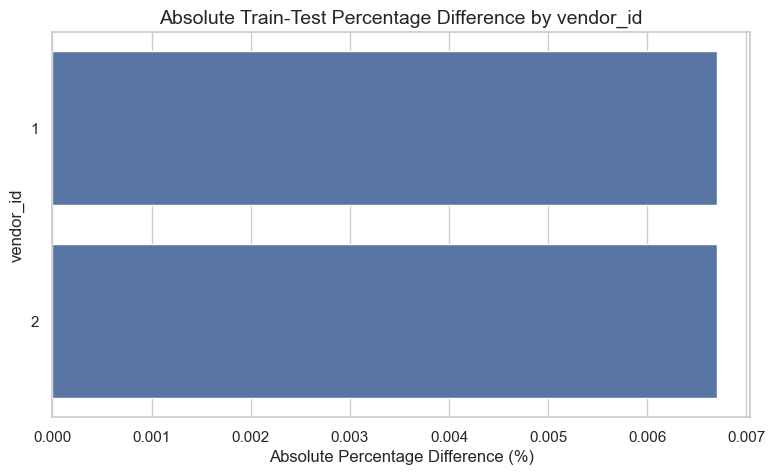

In [162]:
# 6.2.3.3 Absolute train-test percentage difference plot

plt.figure(figsize=(9, 5))

sns.barplot(
    data=vendor_shift_df,
    x="Absolute Percentage Difference",
    y="vendor_id",
    orient="h"
)

plt.title("Absolute Train-Test Percentage Difference by vendor_id")
plt.xlabel("Absolute Percentage Difference (%)")
plt.ylabel("vendor_id")
plt.show()

### 6.2.4 Vendor Validity Check

This subsection checks whether `vendor_id` contains valid and expected category labels.

For this dataset, `vendor_id` is expected to contain low-cardinality vendor codes.

This check helps identify unexpected category labels before feature encoding.

In [163]:
# 6.2.4.1 Unique vendor labels in train and test

train_vendor_categories = sorted(train[vendor_feature].dropna().unique().tolist())
test_vendor_categories = sorted(test[vendor_feature].dropna().unique().tolist())

vendor_validity_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Unique Category Count": [
        train[vendor_feature].nunique(dropna=True),
        test[vendor_feature].nunique(dropna=True)
    ],
    "Unique Categories": [
        train_vendor_categories,
        test_vendor_categories
    ],
    "Missing Count": [
        train[vendor_feature].isna().sum(),
        test[vendor_feature].isna().sum()
    ]
})

vendor_validity_summary

,Dataset,Unique Category Count,Unique Categories,Missing Count
0,Train,2,"[1, 2]",0
1,Test,2,"[1, 2]",0


In [164]:
# 6.2.4.2 Train-test vendor category set comparison

train_vendor_set = set(train[vendor_feature].dropna().astype(str).unique())
test_vendor_set = set(test[vendor_feature].dropna().astype(str).unique())

vendor_only_in_train = sorted(list(train_vendor_set - test_vendor_set))
vendor_only_in_test = sorted(list(test_vendor_set - train_vendor_set))
vendor_common_categories = sorted(list(train_vendor_set & test_vendor_set))

vendor_category_set_check = pd.DataFrame({
    "Check": [
        "Categories in train",
        "Categories in test",
        "Common categories",
        "Only in train",
        "Only in test",
        "Category sets match"
    ],
    "Result": [
        sorted(list(train_vendor_set)),
        sorted(list(test_vendor_set)),
        vendor_common_categories,
        vendor_only_in_train,
        vendor_only_in_test,
        len(vendor_only_in_train) == 0 and len(vendor_only_in_test) == 0
    ]
})

vendor_category_set_check

,Check,Result
0,Categories in train,"[1, 2]"
1,Categories in test,"[1, 2]"
2,Common categories,"[1, 2]"
3,Only in train,[]
4,Only in test,[]
5,Category sets match,True


In [165]:
# 6.2.4.3 Vendor validity status table

expected_vendor_categories = set(["1", "2"])

train_unexpected_vendor = sorted(list(train_vendor_set - expected_vendor_categories))
test_unexpected_vendor = sorted(list(test_vendor_set - expected_vendor_categories))

vendor_validity_checklist = pd.DataFrame({
    "Validation Check": [
        "No missing values in train",
        "No missing values in test",
        "Train contains expected vendor labels only",
        "Test contains expected vendor labels only",
        "Train and test vendor category sets match",
        "Low-cardinality vendor feature"
    ],
    "Status": [
        train[vendor_feature].isna().sum() == 0,
        test[vendor_feature].isna().sum() == 0,
        len(train_unexpected_vendor) == 0,
        len(test_unexpected_vendor) == 0,
        len(vendor_only_in_train) == 0 and len(vendor_only_in_test) == 0,
        train[vendor_feature].nunique(dropna=True) <= 10
    ],
    "Details": [
        f"Train missing count: {train[vendor_feature].isna().sum()}",
        f"Test missing count: {test[vendor_feature].isna().sum()}",
        f"Unexpected train labels: {train_unexpected_vendor}",
        f"Unexpected test labels: {test_unexpected_vendor}",
        f"Only in train: {vendor_only_in_train}; Only in test: {vendor_only_in_test}",
        f"Train unique count: {train[vendor_feature].nunique(dropna=True)}"
    ]
})

vendor_validity_checklist

,Validation Check,Status,Details
0,No missing values in train,True,Train missing count: 0
1,No missing values in test,True,Test missing count: 0
2,Train contains expected vendor labels only,True,Unexpected train labels: []
3,Test contains expected vendor labels only,True,Unexpected test labels: []
4,Train and test vendor category sets match,True,Only in train: []; Only in test: []
5,Low-cardinality vendor feature,True,Train unique count: 2


### 6.2.5 Vendor Dominance and Imbalance

This subsection checks whether one vendor dominates the dataset.

For input categorical features, imbalance does not require resampling.  
However, it should be documented because it affects how much signal each category may provide.

In [166]:
# 6.2.5.1 Vendor dominance summary function

def category_dominance_summary(df, feature, dataset_name):
    counts = df[feature].value_counts(dropna=False)
    percentages = df[feature].value_counts(dropna=False, normalize=True) * 100

    majority_category = counts.idxmax()
    majority_count = counts.max()
    majority_pct = percentages.loc[majority_category]

    minority_category = counts.idxmin()
    minority_count = counts.min()
    minority_pct = percentages.loc[minority_category]

    imbalance_ratio = majority_count / minority_count if minority_count != 0 else np.inf

    return {
        "Dataset": dataset_name,
        "Majority Category": majority_category,
        "Majority Count": majority_count,
        "Majority %": majority_pct,
        "Minority Category": minority_category,
        "Minority Count": minority_count,
        "Minority %": minority_pct,
        "Imbalance Ratio": imbalance_ratio
    }


vendor_dominance_df = pd.DataFrame([
    category_dominance_summary(train, vendor_feature, "Train"),
    category_dominance_summary(test, vendor_feature, "Test")
])

vendor_dominance_df[["Majority %", "Minority %", "Imbalance Ratio"]] = vendor_dominance_df[
    ["Majority %", "Minority %", "Imbalance Ratio"]
].round(4)

vendor_dominance_df

,Dataset,Majority Category,Majority Count,Majority %,Minority Category,Minority Count,Minority %,Imbalance Ratio
0,Train,2,780302,53.4950,1,678342,46.5050,1.1503
1,Test,2,334374,53.4884,1,290760,46.5116,1.1500


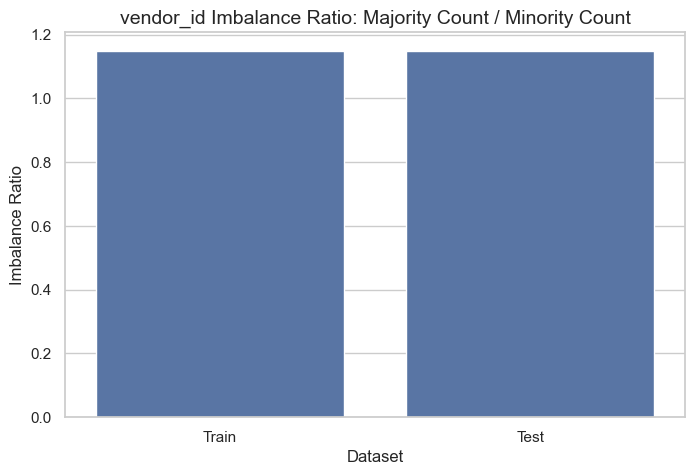

In [167]:
# 6.2.5.2 Vendor imbalance ratio plot

plt.figure(figsize=(8, 5))

sns.barplot(
    data=vendor_dominance_df,
    x="Dataset",
    y="Imbalance Ratio"
)

plt.title("vendor_id Imbalance Ratio: Majority Count / Minority Count")
plt.xlabel("Dataset")
plt.ylabel("Imbalance Ratio")
plt.show()

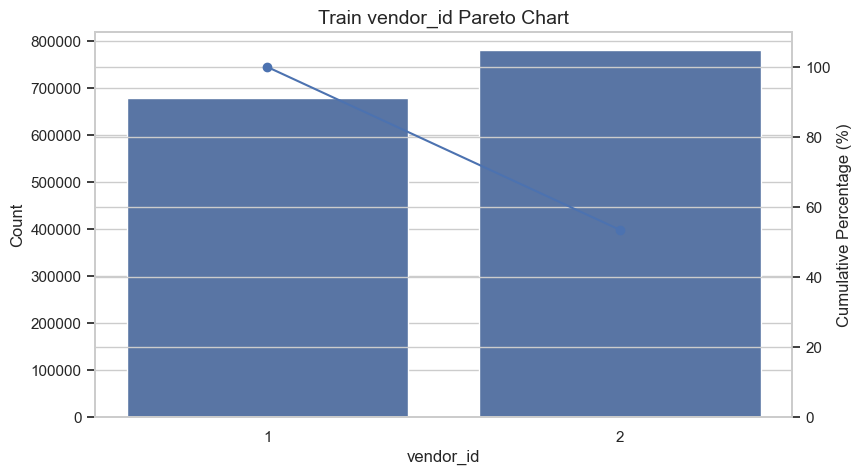

In [168]:
# 6.2.5.3 Pareto chart for train vendor dominance

vendor_pareto_train = train[vendor_feature].value_counts().reset_index()
vendor_pareto_train.columns = ["vendor_id", "Count"]
vendor_pareto_train = vendor_pareto_train.sort_values("Count", ascending=False)
vendor_pareto_train["Cumulative %"] = vendor_pareto_train["Count"].cumsum() / vendor_pareto_train["Count"].sum() * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=vendor_pareto_train,
    x="vendor_id",
    y="Count",
    ax=ax1
)

ax1.set_title("Train vendor_id Pareto Chart")
ax1.set_xlabel("vendor_id")
ax1.set_ylabel("Count")
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()
ax2.plot(
    vendor_pareto_train["vendor_id"].astype(str),
    vendor_pareto_train["Cumulative %"],
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 110)

plt.show()

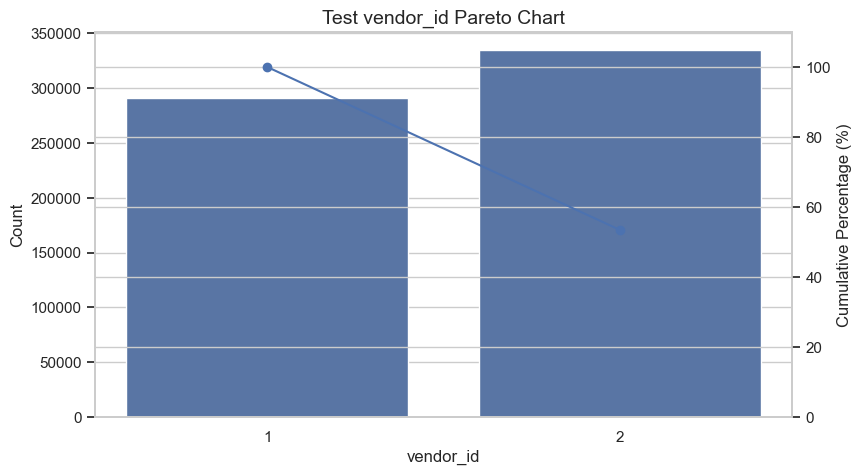

In [169]:
# 6.2.5.4 Pareto chart for test vendor dominance

vendor_pareto_test = test[vendor_feature].value_counts().reset_index()
vendor_pareto_test.columns = ["vendor_id", "Count"]
vendor_pareto_test = vendor_pareto_test.sort_values("Count", ascending=False)
vendor_pareto_test["Cumulative %"] = vendor_pareto_test["Count"].cumsum() / vendor_pareto_test["Count"].sum() * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=vendor_pareto_test,
    x="vendor_id",
    y="Count",
    ax=ax1
)

ax1.set_title("Test vendor_id Pareto Chart")
ax1.set_xlabel("vendor_id")
ax1.set_ylabel("Count")
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()
ax2.plot(
    vendor_pareto_test["vendor_id"].astype(str),
    vendor_pareto_test["Cumulative %"],
    marker="o"
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 110)

plt.show()

### 6.2.6 Compact Vendor Analysis Summary

This subsection collects the important univariate results for `vendor_id`.

No feature-engineering decision is written here yet.  
The final decision will be written after reviewing all tables and charts.

In [170]:
# 6.2.6.1 Compact vendor_id univariate summary

vendor_compact_summary = pd.DataFrame({
    "Analysis Item": [
        "Feature name",
        "Feature type",
        "Train unique categories",
        "Test unique categories",
        "Train missing count",
        "Test missing count",
        "Train majority category",
        "Test majority category",
        "Train minority category",
        "Test minority category",
        "Train imbalance ratio",
        "Test imbalance ratio",
        "Categories only in train",
        "Categories only in test"
    ],
    "Result": [
        vendor_feature,
        "Nominal categorical",
        train_vendor_categories,
        test_vendor_categories,
        train[vendor_feature].isna().sum(),
        test[vendor_feature].isna().sum(),
        vendor_dominance_df.loc[vendor_dominance_df["Dataset"] == "Train", "Majority Category"].iloc[0],
        vendor_dominance_df.loc[vendor_dominance_df["Dataset"] == "Test", "Majority Category"].iloc[0],
        vendor_dominance_df.loc[vendor_dominance_df["Dataset"] == "Train", "Minority Category"].iloc[0],
        vendor_dominance_df.loc[vendor_dominance_df["Dataset"] == "Test", "Minority Category"].iloc[0],
        vendor_dominance_df.loc[vendor_dominance_df["Dataset"] == "Train", "Imbalance Ratio"].iloc[0],
        vendor_dominance_df.loc[vendor_dominance_df["Dataset"] == "Test", "Imbalance Ratio"].iloc[0],
        vendor_only_in_train,
        vendor_only_in_test
    ]
})

vendor_compact_summary

,Analysis Item,Result
0,Feature name,vendor_id
1,Feature type,Nominal categorical
2,Train unique categories,"[1, 2]"
3,Test unique categories,"[1, 2]"
4,Train missing count,0
5,Test missing count,0
6,Train majority category,2
7,Test majority category,2
8,Train minority category,1
9,Test minority category,1


### 6.2.7 Final `vendor_id` Decision for Feature Engineering

From the univariate analysis of `vendor_id`, the following findings were observed:

1. `vendor_id` contains only two categories: `1` and `2`.
2. Both train and test datasets contain the same two vendor categories.
3. No missing value was found in `vendor_id`.
4. No unexpected vendor label was found.
5. The train and test distributions are almost identical.
6. Vendor `2` is slightly more frequent than vendor `1`.
7. The imbalance ratio is close to 1.15, which indicates only mild imbalance.
8. No rare vendor category exists.
9. The train-test percentage difference is extremely small, so no major distribution shift is observed.

Therefore, `vendor_id` is a clean, low-cardinality nominal categorical feature.

#### Final Decision

`vendor_id` will be kept as a model input feature.

Although the values are stored as `1` and `2`, they represent vendor identity, not numerical magnitude. Therefore, `vendor_id` should not be treated as a continuous numerical variable.

No missing-value imputation is required because the feature is complete in both train and test datasets.

No category cleaning is required because both train and test contain the same valid vendor labels: `1` and `2`.

The distribution is stable across train and test. Vendor `2` is slightly more common than vendor `1`, but the imbalance is mild and acceptable. Since `vendor_id` is an input feature and not the target variable, no resampling or balancing is needed.

For feature engineering, `vendor_id` should be encoded as a categorical feature. Since it has only two categories, either one-hot encoding or binary indicator encoding can be used.

Recommended preprocessing choice:

- Convert `vendor_id` to categorical/string before encoding.
- Use one-hot encoding with safe handling for unknown categories.
- Do not use the raw numeric values as continuous magnitude.

Final action:

`vendor_id` = keep, no cleaning needed, encode as categorical.

### 6.2 Analysis Completed

The univariate analysis of `vendor_id` is completed.

Final status:

- Missing check: completed
- Category validity check: completed
- Cardinality check: completed
- Train-test category consistency check: completed
- Train-test distribution shift check: completed
- Imbalance check: completed
- Feature engineering decision: completed

Next step:

Proceed to **Section 6.3 Binary Categorical Feature Analysis: `store_and_fwd_flag`**.